İçindekiler kısmından direkt olarak **çalışan kısım**'a gidebilirsiniz.

In [1]:
import os
from google.colab import drive

# 1. Drive Bağlantısı
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- HÜCRE 2: VERİ HAZIRLIĞI (TUBER + FoodD + HF) ---
import pdfplumber
import zipfile
import json
import glob
from pathlib import Path
from datasets import load_dataset

# AYARLAR
PDF_PATH = "/content/Turkiye_Beslenme_Rehber_TUBER_2022_min.pdf"
ZIP_PATH = "/content/drive/MyDrive/derin/FooDD.zip"
OUTPUT_JSONL = "/content/final_train.jsonl"
IMG_EXTRACT_PATH = "/content/dataset/images/foodd"

dataset_entries = []

# --- ADIM A: TUBER PDF'ten BİLGİ ÇEKME ---
print("📄 1. TUBER PDF Taranıyor...")
tuber_kb = {}
try:
    with pdfplumber.open(PDF_PATH) as pdf:
        # Besin cetvellerinin olduğu aralık (Tahmini)
        for i in range(140, 190):
            try:
                table = pdf.pages[i].extract_table()
                if table:
                    for row in table:
                        if row and len(row) > 3:
                            name = str(row[0]).lower().strip()
                            if any(c.isdigit() for c in str(row[1])):
                                tuber_kb[name] = {
                                    "cal": str(row[1]).replace('\n', ''),
                                    "pro": str(row[2]).replace('\n', '')
                                }
            except: continue
    print(f"   -> {len(tuber_kb)} besin verisi hafızaya alındı.")
except Exception as e:
    print(f"⚠️ PDF okunamadı: {e} (PDF'i yüklediğinden emin ol)")

# --- ADIM B: FoodD ZIP İŞLEME ---
print("📸 2. FoodD Görselleri İşleniyor...")
if not os.path.exists(IMG_EXTRACT_PATH):
    try:
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(IMG_EXTRACT_PATH)
    except FileNotFoundError:
        print("⚠️ FoodD ZIP dosyası bulunamadı! Drive yolunu kontrol et.")

foodd_images = glob.glob(f"{IMG_EXTRACT_PATH}/**/*.jpg", recursive=True)

for img_path in foodd_images:
    folder_name = Path(img_path).parent.name.lower()

    # TUBER ile Eşleştirme
    info = "Standart besin değerleri."
    for t_name, t_val in tuber_kb.items():
        if t_name in folder_name:
            info = f"TUBER verilerine göre 100g'da {t_val['cal']} kcal ve {t_val['pro']}g protein."
            break

    # CoT (Chain of Thought) Prompt
    prompt = (
        f"Düşünce Zinciri:\n"
        f"1. Tespit: Görüntüdeki yemek '{folder_name}' olarak algılandı.\n"
        f"2. Bilgi: {info}\n"
        f"Sonuç: Bu bir {folder_name} tabağıdır."
    )

    dataset_entries.append({
        "image": img_path,
        "conversations": [
            {"from": "user", "value": "<image>\nBu yemeği analiz et."},
            {"from": "assistant", "value": prompt}
        ]
    })

# --- ADIM C: HUGGING FACE DATASET EKLEME ---
print("🌐 3. Hugging Face (mmathys/food-nutrients) Ekleniyor...")
try:
    hf_ds = load_dataset("mmathys/food-nutrients", split="train[:200]") # Hız için ilk 200
    hf_save_dir = "/content/dataset/images/hf"
    os.makedirs(hf_save_dir, exist_ok=True)

    for idx, item in enumerate(hf_ds):
        if item['image']:
            save_path = f"{hf_save_dir}/hf_{idx}.jpg"
            item['image'].save(save_path)
            # HF verisetinde text kolonu varsa onu kullan, yoksa genel yaz
            desc = item.get('text', 'Bilinmeyen Besin')

            prompt = f"Düşünce Zinciri:\n1. Analiz: {desc}\nSonuç: Besleyici öğün."
            dataset_entries.append({
                "image": save_path,
                "conversations": [
                    {"from": "user", "value": "<image>\nNedir?"},
                    {"from": "assistant", "value": prompt}
                ]
            })
except Exception as e:
    print(f"⚠️ HF Verisi çekilemedi: {e}")

# KAYDETME
with open(OUTPUT_JSONL, 'w', encoding='utf-8') as f:
    for entry in dataset_entries:
        json.dump(entry, f, ensure_ascii=False)
        f.write('\n')

print(f"✅ VERİ SETİ HAZIR: {len(dataset_entries)} satır veri oluşturuldu ({OUTPUT_JSONL}).")

📄 1. TUBER PDF Taranıyor...
⚠️ PDF okunamadı: [Errno 2] No such file or directory: '/content/Turkiye_Beslenme_Rehber_TUBER_2022_min.pdf' (PDF'i yüklediğinden emin ol)
📸 2. FoodD Görselleri İşleniyor...


KeyboardInterrupt: 

In [ ]:
import os
import glob
import json
import pdfplumber
import zipfile
import logging
from pathlib import Path
from tqdm import tqdm
from datasets import load_dataset
from google.colab import drive

# Drive baglantisi kontrol ediliyor
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# PDF uyarilarini kapat
logging.getLogger("pdfminer").setLevel(logging.ERROR)

# --- AYARLAR ---
BASE_DIR = "/content/drive/MyDrive/derin"

# PDF Dosyasi Kontrolu (Once sol panele, yoksa Drive'a bakar)
if os.path.exists("/content/Turkiye_Beslenme_Rehber_TUBER_2022_min.pdf"):
    PDF_PATH = "/content/Turkiye_Beslenme_Rehber_TUBER_2022_min.pdf"
else:
    PDF_PATH = f"{BASE_DIR}/Turkiye_Beslenme_Rehber_TUBER_2022_min.pdf"

ZIP_PATH = f"{BASE_DIR}/FooDD.zip"
# ONEMLI: Dosya dogrudan Drive'a kaydedilecek
OUTPUT_JSONL = f"{BASE_DIR}/final_train.jsonl"
IMG_EXTRACT_PATH = "/content/dataset/images/foodd"
HF_IMG_DIR = "/content/dataset/images/hf"

print(f"Veri seti hazirlama islemi baslatildi. Cikti dosyasi: {OUTPUT_JSONL}")

dataset_entries = []
tuber_kb = {}

# A. PDF TARAMA
try:
    print("PDF dosyasi okunuyor ve besin degerleri aliniyor")
    with pdfplumber.open(PDF_PATH) as pdf:
        for page in pdf.pages:
            try:
                table = page.extract_table()
                if table:
                    for row in table:
                        if row and len(row) > 3:
                            if any(c.isdigit() for c in str(row[1])):
                                name = str(row[0]).lower().strip().replace('\n', ' ')
                                tuber_kb[name] = {"cal": str(row[1]), "pro": str(row[2])}
            except: continue
    print(f"PDF taramasi tamamlandi. {len(tuber_kb)} adet veri hafizaya alindi")
except:
    print("PDF dosyasi bulunamadi veya okunamadi (Islem devam ediyor)")

# B. FoodD ZIP ISLEME
if not os.path.exists(IMG_EXTRACT_PATH):
    print("FoodD zip dosyasi hizli calisma alanina aciliyor")
    try:
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(IMG_EXTRACT_PATH)
    except: pass

print("FoodD klasorundeki tum gorseller listeleniyor (Bu islem biraz surebilir)")

# --- DUZELTME: LIMIT KALDIRILDI ---
# Artik tum dosyalari tarayacak
food_files = glob.glob(f"{IMG_EXTRACT_PATH}/**/*.jpg", recursive=True) + \
             glob.glob(f"{IMG_EXTRACT_PATH}/**/*.jpeg", recursive=True) + \
             glob.glob(f"{IMG_EXTRACT_PATH}/**/*.png", recursive=True)

print(f"Toplam {len(food_files)} adet gorsel bulundu ve isleniyor")

for img in tqdm(food_files):
    try:
        folder = Path(img).parent.name.lower()
        info = f"TUBER: {tuber_kb.get(folder, {'cal':'?', 'pro':'?'})}"
        prompt = f"Analiz:\n1. Tespit: {folder}\n2. Veri: {info}"

        # Qwen2 Veri Formati
        dataset_entries.append({
            "image": img,
            "conversations": [
                {
                    "role": "user",
                    "content": [{"type": "text", "text": "Bu yemegi analiz et."}]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": prompt}]
                }
            ]
        })
    except: continue

# C. HUGGING FACE ISLEME
print("Hugging Face veri seti indiriliyor ve ekleniyor")
os.makedirs(HF_IMG_DIR, exist_ok=True)
try:
    ds = load_dataset("mmathys/food-nutrients", split="test")
    for i, item in enumerate(tqdm(ds)):
        if item.get('image'):
            save_path = f"{HF_IMG_DIR}/hf_{i}.jpg"
            if not os.path.exists(save_path):
                item['image'].convert('RGB').save(save_path)

            txt = item.get('text', item.get('food', 'Yemek'))
            cal = item.get('caloric_value', 'N/A')
            prompt = f"Analiz: {txt}. Kalori: {cal}"

            dataset_entries.append({
                "image": save_path,
                "conversations": [
                    {
                        "role": "user",
                        "content": [{"type": "text", "text": "Besin degerleri nedir?"}]
                    },
                    {
                        "role": "assistant",
                        "content": [{"type": "text", "text": prompt}]
                    }
                ]
            })
except Exception as e:
    print(f"Hugging Face verisi islenirken hata olustu: {e}")

# KAYDETME
print("Tum veriler JSONL formatinda Drive uzerine kaydediliyor")
with open(OUTPUT_JSONL, 'w', encoding='utf-8') as f:
    for e in dataset_entries:
        json.dump(e, f, ensure_ascii=False)
        f.write('\n')

print(f"Islem basariyla tamamlandi. Dosya konumu: {OUTPUT_JSONL}")
print(f"Toplam satir sayisi: {len(dataset_entries)}")

Veri seti hazirlama islemi baslatildi. Cikti dosyasi: /content/drive/MyDrive/derin/final_train.jsonl
PDF dosyasi okunuyor ve besin degerleri aliniyor
PDF taramasi tamamlandi. 504 adet veri hafizaya alindi
FoodD klasorundeki tum gorseller listeleniyor (Bu islem biraz surebilir)
Toplam 2832 adet gorsel bulundu ve isleniyor


100%|██████████| 2832/2832 [00:00<00:00, 93341.52it/s]

Hugging Face veri seti indiriliyor ve ekleniyor



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/3260 [00:00<?, ?it/s]

100%|██████████| 3260/3260 [00:39<00:00, 82.25it/s]


Tum veriler JSONL formatinda Drive uzerine kaydediliyor
Islem basariyla tamamlandi. Dosya konumu: /content/drive/MyDrive/derin/final_train.jsonl
Toplam satir sayisi: 6092


In [ ]:
import os
import zipfile
import shutil
import cv2
import yaml
from ultralytics import YOLO
from glob import glob
from tqdm import tqdm
from google.colab import drive

# --- 1. AYARLAR (YÜKSEK KALİTE) ---
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/derin"
ZIP_PATH = f"{BASE_DIR}/FooDD.zip"
WORK_DIR = "/content/foodd_high_res_workspace"
DATASET_DIR = f"{WORK_DIR}/dataset"
PROJECT_OUTPUT_DIR = f"{BASE_DIR}/YOLO_High_Performance_Output"

# Temizlik
if os.path.exists(WORK_DIR): shutil.rmtree(WORK_DIR)
os.makedirs(f"{DATASET_DIR}/images/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/images/val", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/labels/val", exist_ok=True)

# --- 2. ZIP AÇMA ---
print(f"📦 ZIP Açılıyor: {ZIP_PATH}")
EXTRACT_PATH = f"{WORK_DIR}/raw_images"
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
except FileNotFoundError:
    print("❌ HATA: ZIP dosyası bulunamadı!")

# --- 3. AUTO-LABELING (TEACHER: YOLOv8X - EXTRA LARGE) ---
print("\n👀 ÖĞRETMEN MODEL (YOLOv8x) Devreye Giriyor...")
print("ℹ️ Not: Confidence 0.40 yapıldı. Sadece net tabaklar seçilecek.")

# En zeki model (Etiketlemek için)
teacher_model = YOLO('yolov8x.pt')

all_images = glob(f"{EXTRACT_PATH}/**/*.jpg", recursive=True) + \
             glob(f"{EXTRACT_PATH}/**/*.jpeg", recursive=True) + \
             glob(f"{EXTRACT_PATH}/**/*.png", recursive=True)

processed_count = 0

for img_path in tqdm(all_images, desc="Hassas Etiketleme"):
    try:
        img = cv2.imread(img_path)
        if img is None: continue

        # Conf=0.40 (Sadece çok net olanları al)
        results = teacher_model(img, verbose=False, conf=0.40)

        label_data = []
        has_detection = False

        for r in results:
            boxes = r.boxes.xywhn.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy()

            for box, cls in zip(boxes, classes):
                # Tek Sınıf: 0 (Yemek)
                label_data.append(f"0 {box[0]} {box[1]} {box[2]} {box[3]}")
                has_detection = True

        if has_detection:
            base_name = f"foodd_hq_{processed_count}"

            # Resmi Kaydet
            cv2.imwrite(f"{DATASET_DIR}/images/train/{base_name}.jpg", img)

            # Etiketi Kaydet
            with open(f"{DATASET_DIR}/labels/train/{base_name}.txt", 'w') as f:
                f.write("\n".join(label_data))

            processed_count += 1

    except: continue

print(f"\n✅ YÜKSEK KALİTE VERİ SETİ: {processed_count} adet temiz resim hazırlandı.")

# --- 4. YAML DOSYASI ---
yaml_content = f"""
path: {DATASET_DIR}
train: images/train
val: images/train
names:
  0: food_plate
"""
yaml_path = f"{WORK_DIR}/foodd_hq.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

# --- 5. EĞİTİM (STUDENT: YOLOv8L - LARGE) ---
print(f"\n🚀 EĞİTİM BAŞLIYOR: YOLOv8-LARGE (Büyük Model)")
print(f"Hedef: {PROJECT_OUTPUT_DIR}")

# Medium yerine Large (L) modeli kullanıyoruz. Daha iyi sonuç verir.
model = YOLO('yolov8l.pt')

results = model.train(
    data=yaml_path,
    epochs=40,            # High precision için ideal süre
    imgsz=640,
    batch=16,             # Large model için batch düşürdük (VRAM taşmasın)
    patience=10,          # İlerleme durursa bekle
    project=PROJECT_OUTPUT_DIR,
    name='foodd_large_model',
    augment=True,         # Veri çoğaltmayı aç (Daha sağlam model)
    hsv_h=0.015,          # Renk varyasyonlarını öğrensin (Farklı ışıklar için)
    hsv_s=0.7,
    hsv_v=0.4
)

print(f"\n✅ MÜKEMMEL SONUÇ İÇİN MODEL HAZIR: {results.save_dir}/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 ZIP Açılıyor: /content/drive/MyDrive/derin/FooDD.zip

👀 ÖĞRETMEN MODEL (YOLOv8x) Devreye Giriyor...
ℹ️ Not: Confidence 0.40 yapıldı. Sadece net tabaklar seçilecek.


Hassas Etiketleme: 100%|██████████| 2832/2832 [04:03<00:00, 11.62it/s]



✅ YÜKSEK KALİTE VERİ SETİ: 2669 adet temiz resim hazırlandı.

🚀 EĞİTİM BAŞLIYOR: YOLOv8-LARGE (Büyük Model)
Hedef: /content/drive/MyDrive/derin/YOLO_High_Performance_Output
Ultralytics 8.3.242 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/foodd_high_res_workspace/foodd_hq.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

In [ ]:
import os
import shutil
import zipfile
from tqdm import tqdm
from google.colab import drive

# 1. Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- AYARLAR ---
SOURCE_DIR = "/content"
DEST_DIR = "/content/drive/MyDrive/derin"

# Drive'da klasör yoksa oluştur
os.makedirs(DEST_DIR, exist_ok=True)

# 2. KURTARILACAK DOSYALAR LİSTESİ (Ekran görüntüsünden)
files_to_save = [
    "final_train.jsonl",
    "final_train1.jsonl",  # Varsa bunu da alalım
    "Turkiye_Beslenme_Rehber_TUBER_2022_min.pdf",
    "yolo11n.pt",
    "yolov8l.pt",
    "yolov8x.pt"
]

# 3. KURTARILACAK KLASÖRLER (Zipleyip atacağız)
folders_to_save = [
    "foodd_high_res_workspace", # YOLO için hazırlanan veriler burada
    "dataset",                  # Ham resimler burada
    "models"                    # Eğer model çıktıları buraya düştüyse
]

print(f"📦 YEDEKLEME BAŞLIYOR... Hedef: {DEST_DIR}\n")

# --- A. TEKİL DOSYALARI KOPYALA ---
for filename in files_to_save:
    src_path = os.path.join(SOURCE_DIR, filename)
    dst_path = os.path.join(DEST_DIR, filename)

    if os.path.exists(src_path):
        try:
            print(f"📄 Kopyalanıyor: {filename}...")
            shutil.copy2(src_path, dst_path)
        except Exception as e:
            print(f"❌ Hata ({filename}): {e}")
    else:
        print(f"⚠️ Dosya bulunamadı (atlanıyor): {filename}")

# --- B. KLASÖRLERİ ZİPLE VE GÖNDER ---
# Klasörleri tek tek kopyalamak Drive'ı kilitler (çok yavaştır).
# O yüzden zipleyip tek dosya olarak atıyoruz.
def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, folder_path)
                zipf.write(file_path, arcname)

for folder in folders_to_save:
    folder_path = os.path.join(SOURCE_DIR, folder)

    if os.path.exists(folder_path):
        print(f"\n🗂️ Klasör Ziplerinip Yedekleniyor: {folder} (Bu biraz sürebilir)...")
        zip_name = f"{folder}_backup.zip"
        zip_dst = os.path.join(DEST_DIR, zip_name)

        try:
            # Önce Colab içinde ziple (Hız için)
            temp_zip = os.path.join(SOURCE_DIR, zip_name)
            zip_folder(folder_path, temp_zip)

            # Sonra Drive'a taşı
            shutil.move(temp_zip, zip_dst)
            print(f"✅ {folder} başarıyla ziplendi ve Drive'a atıldı.")
        except Exception as e:
            print(f"❌ Klasör hatası ({folder}): {e}")
    else:
        print(f"⚠️ Klasör bulunamadı (atlanıyor): {folder}")

print(f"\n🚀 TÜM İŞLEMLER TAMAMLANDI! Dosyalarını '{DEST_DIR}' klasöründe kontrol edebilirsin.")

📦 YEDEKLEME BAŞLIYOR... Hedef: /content/drive/MyDrive/derin

📄 Kopyalanıyor: final_train.jsonl...
📄 Kopyalanıyor: final_train1.jsonl...
📄 Kopyalanıyor: Turkiye_Beslenme_Rehber_TUBER_2022_min.pdf...
📄 Kopyalanıyor: yolo11n.pt...
📄 Kopyalanıyor: yolov8l.pt...
📄 Kopyalanıyor: yolov8x.pt...

🗂️ Klasör Ziplerinip Yedekleniyor: foodd_high_res_workspace (Bu biraz sürebilir)...
✅ foodd_high_res_workspace başarıyla ziplendi ve Drive'a atıldı.

🗂️ Klasör Ziplerinip Yedekleniyor: dataset (Bu biraz sürebilir)...
✅ dataset başarıyla ziplendi ve Drive'a atıldı.

🗂️ Klasör Ziplerinip Yedekleniyor: models (Bu biraz sürebilir)...
✅ models başarıyla ziplendi ve Drive'a atıldı.

🚀 TÜM İŞLEMLER TAMAMLANDI! Dosyalarını '/content/drive/MyDrive/derin' klasöründe kontrol edebilirsin.


In [ ]:
import torch
import os
import gc
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, TrainingArguments, Trainer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset
from PIL import Image

# Bellek temizligi
torch.cuda.empty_cache()
gc.collect()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# AYARLAR
OUTPUT_DIR = "/content/drive/MyDrive/derin/Qwen2_VL_Pro_Model"
DATA_FILE = "/content/final_train.jsonl"

# 1. MODEL VE PROCESSOR
print(f"Model ve ayarlar yukleniyor. Hedef klasor: {OUTPUT_DIR}")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="flash_attention_2"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

# 2. LORA YAPILANDIRMASI
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=[
        "q_proj", "v_proj", "k_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
        "merger.mlp.0", "merger.mlp.2"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    modules_to_save=["embed_tokens", "lm_head"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

# 3. VERI SETI
print("Egitim verisi dosyadan okunuyor")
dataset = load_dataset("json", data_files=DATA_FILE, split="train")

def qwen_pro_collator(batch):
    texts = []
    images = []
    for item in batch:
        try:
            user_txt = item['conversations'][0]['content'][0]['text']
            asst_txt = item['conversations'][1]['content'][0]['text']

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": item['image']},
                        {"type": "text", "text": user_txt}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": asst_txt}]
                }
            ]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            texts.append(text)
            images.append(Image.open(item['image']).convert("RGB"))
        except:
            continue

    if not texts: return None

    batch_out = processor(text=texts, images=images, padding=True, return_tensors="pt")

    labels = batch_out["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    img_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    labels[labels == img_token_id] = -100
    batch_out["labels"] = labels

    return batch_out

# 4. EGITIM AYARLARI
# Not: Bellek hatasi almamak icin batch boyutu dusuruldu
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=4,   # RAM dolmasini engellemek icin 4 yapildi
    gradient_accumulation_steps=8,   # 4x8 = 32 batch etkisi saglar
    dataloader_num_workers=4,        # Islemci yukunu dengelemek icin 4 yapildi
    num_train_epochs=3,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    logging_steps=5,
    save_strategy="epoch",
    bf16=True,
    gradient_checkpointing=True,     # Bellek tasarrufu icin gerekli
    remove_unused_columns=False,
    report_to="none",
    optim="paged_adamw_8bit"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=qwen_pro_collator
)

print("Egitim islemi baslatiliyor")
trainer.train()

# 5. KAYIT
print(f"Model drive klasorune kaydediliyor: {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

Model ve ayarlar yukleniyor. Hedef klasor: /content/drive/MyDrive/derin/Qwen2_VL_Pro_Model


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1222: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


trainable params: 541,687,808 || all params: 2,750,673,408 || trainable%: 19.6929
Egitim verisi dosyadan okunuyor
Egitim islemi baslatiliyor


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


OutOfMemoryError: CUDA out of memory. Tried to allocate 23.20 GiB. GPU 0 has a total capacity of 79.32 GiB of which 4.49 GiB is free. Process 477393 has 74.74 GiB memory in use. Of the allocated memory 62.27 GiB is allocated by PyTorch, and 11.97 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import torch
import os
import gc
import zipfile
from google.colab import drive
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, TrainingArguments, Trainer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset
from PIL import Image

# 1. BELLEK TEMIZLIGI
torch.cuda.empty_cache()
gc.collect()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# 2. DRIVE BAGLANTISI
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/derin"
OUTPUT_DIR = f"{BASE_DIR}/Qwen2_VL_Pro_Model"
DATA_FILE = f"{BASE_DIR}/final_train.jsonl"
ZIP_PATH = f"{BASE_DIR}/FooDD.zip"
IMG_EXTRACT_PATH = "/content/dataset/images/foodd"

# 3. DOSYA KONTROLU
if not os.path.exists(IMG_EXTRACT_PATH):
    print("Gorsel dosyalari aciliyor")
    if os.path.exists(ZIP_PATH):
        try:
            with zipfile.ZipFile(ZIP_PATH, 'r') as z:
                z.extractall(IMG_EXTRACT_PATH)
        except Exception as e:
            print(f"Zip hatasi: {e}")
    else:
        print("Zip dosyasi bulunamadi")

# 4. MODEL YUKLEME
print("Model yukleniyor")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="flash_attention_2"
)

# Kritik Ayar: Egitim sirasinda cache kullanilmaz
model.config.use_cache = False
model.gradient_checkpointing_enable()

processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

# 5. LORA AYARLARI
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=[
        "q_proj", "v_proj", "k_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
        "merger.mlp.0", "merger.mlp.2"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    modules_to_save=["embed_tokens", "lm_head"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

# 6. DATASET
print(f"Veri kaynagi: {DATA_FILE}")
dataset = load_dataset("json", data_files=DATA_FILE, split="train")

def qwen_pro_collator(batch):
    texts = []
    images = []
    for item in batch:
        try:
            user_txt = item['conversations'][0]['content'][0]['text']
            asst_txt = item['conversations'][1]['content'][0]['text']

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": item['image']},
                        {"type": "text", "text": user_txt}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": asst_txt}]
                }
            ]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

            # --- BELLEK ICIN KRITIK MUDAHALE: RESIM KUCULTME ---
            img_raw = Image.open(item['image']).convert("RGB")
            # Resmi en fazla 640x640 olacak sekilde kucultuyoruz
            img_raw.thumbnail((640, 640))

            texts.append(text)
            images.append(img_raw)
        except:
            continue

    if not texts: return None

    batch_out = processor(text=texts, images=images, padding=True, return_tensors="pt")

    labels = batch_out["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    img_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    labels[labels == img_token_id] = -100
    batch_out["labels"] = labels

    return batch_out

# 7. EGITIM AYARLARI (ULTRA TASARRUF)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,
    bf16=True,
    logging_steps=10,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    remove_unused_columns=False,
    max_grad_norm=1.0,
    optim="adamw_torch",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=qwen_pro_collator
)

print("Egitim baslatiliyor")
trainer.train()

# 8. KAYIT
print(f"Model kaydediliyor: {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

Model yukleniyor


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

trainable params: 541,687,808 || all params: 2,750,673,408 || trainable%: 19.6929
Veri kaynagi: /content/drive/MyDrive/derin/final_train.jsonl


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Egitim baslatiliyor


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
10,2.271887


KeyboardInterrupt: 

In [ ]:
import json

dosya_yolu = "/content/drive/MyDrive/derin/final_train.jsonl"

try:
    with open(dosya_yolu, 'r', encoding='utf-8') as f:
        satir_sayisi = sum(1 for _ in f)

    print(f"Dosyadaki toplam satir (veri) sayisi: {satir_sayisi}")

    if satir_sayisi < 5000:
        print("DURUM: Veri sayisi az. Muhtemelen olustururken [:2000] siniri vardi.")
        print("COZUM: Veri olusturma kodundaki siniri kaldirip dosyayi bastan yaratman lazim.")
    else:
        print("DURUM: Veri sayisi normal. Egitim parametrelerinde bir yanlislik olabilir.")

except FileNotFoundError:
    print("Dosya bulunamadi.")

Dosyadaki toplam satir (veri) sayisi: 2832
DURUM: Veri sayisi az. Muhtemelen olustururken [:2000] siniri vardi.
COZUM: Veri olusturma kodundaki siniri kaldirip dosyayi bastan yaratman lazim.


In [ ]:
import torch
import os
import gc
import zipfile
from google.colab import drive
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, TrainingArguments, Trainer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset
from PIL import Image

# 1. BELLEK TEMIZLIGI
torch.cuda.empty_cache()
gc.collect()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# 2. DRIVE BAGLANTISI
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/derin"
OUTPUT_DIR = f"{BASE_DIR}/Qwen2_VL_Pro_Model"
DATA_FILE = f"{BASE_DIR}/final_train.jsonl"
ZIP_PATH = f"{BASE_DIR}/FooDD.zip"
IMG_EXTRACT_PATH = "/content/dataset/images/foodd"

# 3. DOSYA KONTROLU
if not os.path.exists(IMG_EXTRACT_PATH):
    print("Gorsel dosyalari aciliyor")
    if os.path.exists(ZIP_PATH):
        try:
            with zipfile.ZipFile(ZIP_PATH, 'r') as z:
                z.extractall(IMG_EXTRACT_PATH)
        except Exception as e:
            print(f"Zip hatasi: {e}")
    else:
        print("Zip dosyasi bulunamadi")

# 4. MODEL YUKLEME
print("Model yukleniyor")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="flash_attention_2"
)

# Kritik Ayar: Egitim sirasinda cache kullanilmaz
model.config.use_cache = False
model.gradient_checkpointing_enable()

processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

# 5. LORA AYARLARI
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=[
        "q_proj", "v_proj", "k_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
        "merger.mlp.0", "merger.mlp.2"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    modules_to_save=["embed_tokens", "lm_head"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

# 6. DATASET
print(f"Veri kaynagi: {DATA_FILE}")
dataset = load_dataset("json", data_files=DATA_FILE, split="train")

def qwen_pro_collator(batch):
    texts = []
    images = []
    for item in batch:
        try:
            user_txt = item['conversations'][0]['content'][0]['text']
            asst_txt = item['conversations'][1]['content'][0]['text']

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": item['image']},
                        {"type": "text", "text": user_txt}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": asst_txt}]
                }
            ]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

            # --- BELLEK ICIN KRITIK MUDAHALE: RESIM KUCULTME ---
            img_raw = Image.open(item['image']).convert("RGB")
            # Resmi en fazla 640x640 olacak sekilde kucultuyoruz
            img_raw.thumbnail((640, 640))

            texts.append(text)
            images.append(img_raw)
        except:
            continue

    if not texts: return None

    batch_out = processor(text=texts, images=images, padding=True, return_tensors="pt")

    labels = batch_out["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    img_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    labels[labels == img_token_id] = -100
    batch_out["labels"] = labels

    return batch_out

# 7. EGITIM AYARLARI (ULTRA TASARRUF)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,
    bf16=True,
    logging_steps=10,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    remove_unused_columns=False,
    max_grad_norm=1.0,
    optim="adamw_torch",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=qwen_pro_collator
)

print("Egitim baslatiliyor")
trainer.train()

# 8. KAYIT
print(f"Model kaydediliyor: {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

Model yukleniyor


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

You are attempting to use Flash Attention 2 without specifying a torch dtype. This might lead to unexpected behaviour


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1222: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
10,3.864175
20,1.473800
30,0.274411
40,0.055008
50,0.014587
60,0.011238
70,0.009970
80,0.008450
90,0.008042
100,0.006265


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Model kaydediliyor: /content/drive/MyDrive/derin/Qwen2_VL_Pro_Model


['/content/drive/MyDrive/derin/Qwen2_VL_Pro_Model/processor_config.json']

In [ ]:
# ==============================================================================
# LLAMA-3 CHATBOT EĞİTİMİ
# ==============================================================================

# 1. KÜTÜPHANELER
import os
import subprocess

print("Gerekli kütüphaneler kuruluyor")
# Sessiz kurulum
libs = [
    "pip install --upgrade pip",
    "pip install -U torch torchvision torchaudio",
    "pip install -U transformers datasets peft bitsandbytes trl accelerate",
    "pip install flash-attn --no-build-isolation"
]
for lib in libs:
    subprocess.run(lib, shell=True, stdout=subprocess.DEVNULL)

import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from trl import SFTTrainer, SFTConfig

# ==============================================================================
# 2. VERİ SETİ
# ==============================================================================
print("Veri seti hazırlanıyor")

# Örnek veri seti (Kendi verilerini buraya ekleyebilirsin)
diet_data = [
    # --- KATEGORİ 1: TÜRK MUTFAĞI & AĞIR YEMEKLER (Kaçamak Yönetimi) ---
    {
        "instruction": "Kullanıcı: Bu yemeği akşam yiyebilir miyim? Diyeti bozar mı?",
        "input": "Analiz: Tabakta bol tereyağlı İskender Kebap, yanında yoğurt ve pide parçaları var.",
        "output": "İskender Kebap lezzetli ama kalorisi oldukça yüksek bir tercihtir. Özellikle altındaki yağlı pideler karbonhidrat yükünü artırır. Eğer bunu akşam yiyeceksen; pidesinin yarısını bırakmanı, tereyağı ekletmemeni ve yanında mutlaka ekstra yeşillik tüketmeni öneririm. Ertesi gün kahvaltıyı hafif yaparak dengeleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Canım çok çekti, bir porsiyon yesem ne olur?",
        "input": "Analiz: Bir tabak tereyağlı ve soslu Kayseri Mantısı.",
        "output": "Mantı hem hamur (karbonhidrat) hem de kıyma (protein) içerse de sosundaki yağ miktarı onu ağırlaştırır. Bir porsiyon mantı ortalama 400-500 kaloridir. Eğer öğlen yiyorsan sorun yok, ancak akşam için porsiyonu yarıya indirip yanına büyük bir kase yağsız salata eklemeni tavsiye ederim."
    },
    {
        "instruction": "Kullanıcı: Lahmacun diyette yasak mı?",
        "input": "Analiz: 2 adet Lahmacun ve yanında bol yeşillik, limon.",
        "output": "Aslında lahmacun, ince hamuru ve sebzeli kıyma harcıyla pizzadan çok daha sağlıklı bir alternatiftir! Diyette yasak değildir. 2 lahmacun bir ana öğün yerine geçer. Yanındaki yeşillikleri bolca içine koyup, ayran ile tüketirsen kan şekerini dengelersin. Afiyet olsun!"
    },
    {
        "instruction": "Kullanıcı: Tatlı krizim tuttu, bunu yesem çok mu kilo alırım?",
        "input": "Analiz: Bir porsiyon şerbetli Künefe ve yanında kaymak.",
        "output": "Künefe, şerbet ve peynir yağı nedeniyle glisemik indeksi çok yüksek bir tatlıdır. Bir porsiyonu bir ana öğüne eşdeğer kalori içerebilir. Tavsiyem: Bunu tek başına yeme, bir arkadaşınla paylaş. Yanında süt veya sade kahve içerek kan şekerini dengelemeye çalış. Ve bunu haftada 1 kereden fazla yapmamaya özen göster."
    },

    # --- KATEGORİ 2: SAĞLIKLI & DİYET DOSTU SEÇİMLER (Motivasyon) ---
    {
        "instruction": "Kullanıcı: Bu öğün sizce nasıl? Yeterli mi?",
        "input": "Analiz: Izgara tavuk göğsü, haşlanmış brokoli ve az miktar bulgur pilavı.",
        "output": "Mükemmel bir tabak! Protein (tavuk), lif (brokoli) ve kompleks karbonhidrat (bulgur) dengesi harika kurulmuş. Bu öğün seni uzun süre tok tutar ve kas gelişimini destekler. Bu şekilde beslenmeye devam et!"
    },
    {
        "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, iyi mi?",
        "input": "Analiz: Menemen, 2 dilim tam buğday ekmeği ve 5 adet zeytin.",
        "output": "Gayet dengeli ve Türk damak tadına uygun sağlıklı bir kahvaltı. Menemen hem sebze hem protein kaynağıdır. Ekmek bandırırken aşırıya kaçmamaya dikkat ettiğin sürece güne başlamak için harika bir seçim."
    },
    {
        "instruction": "Kullanıcı: Akşam yemeği için hafif mi yoksa az mı olmuş?",
        "input": "Analiz: Bir kase mercimek çorbası ve mevsim salatası.",
        "output": "Akşam yemeği için oldukça hafif ve mideyi yormayan bir tercih. Mercimek çorbası bitkisel protein ve lif içerir. Eğer çok aç hissediyorsan çorbanın içine biraz limon sıkmak veya salatana biraz lor peyniri eklemek tokluk süreni artırabilir."
    },

    # --- KATEGORİ 3: FAST FOOD & ATIŞTIRMALIKLAR (Uyarı ve Alternatif) ---
    {
        "instruction": "Kullanıcı: Arkadaşlarla dışarıdayız, hamburger söyledim. Ne yapmalıyım?",
        "input": "Analiz: Büyük boy Hamburger menüsü, patates kızartması ve kola.",
        "output": "Sosyal ortamlarda bazen kaçamaklar olabilir. Zararı en aza indirmek için şunları yapabilirsin: Hamburgerin ekmeğinin üst kısmını ayırarak 'açık hamburger' gibi ye. Patates kızartmasını arkadaşlarınla paylaş ve içecek olarak kola yerine ayran veya su tercih et. Bu küçük değişiklikler yüzlerce kalori tasarruf etmeni sağlar."
    },
    {
        "instruction": "Kullanıcı: Film izlerken atıştırmak istiyorum?",
        "input": "Analiz: Bir kase patlamış mısır (yağsız görünüyor).",
        "output": "Evde az yağlı ve az tuzlu patlatılmış mısır, cipslerden çok daha masum bir atıştırmalıktır. Lif oranı yüksektir. Bir su bardağı kadar yemenin diyete bir zararı olmaz. Keyfini çıkar!"
    },

    # --- KATEGORİ 4: ÖZEL DURUMLAR (Sporcu, Vegan vb.) ---
    {
        "instruction": "Kullanıcı: Spordan çıktım, bu yeterli mi?",
        "input": "Analiz: Ton balıklı salata ve bir adet muz.",
        "output": "Antrenman sonrası için çok doğru bir seçim. Ton balığı kas onarımı için gerekli proteini sağlarken, muz boşalan glikojen depolarını (enerji) hızlıca doldurmana yardımcı olur. Belki yanına bir dilim tam tahıllı ekmek de ekleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Bugün hiç sebze yemedim, bu tabak dengeler mi?",
        "input": "Analiz: Zeytinyağlı taze fasulye ve cacık.",
        "output": "Evet, kesinlikle dengeler. Zeytinyağlı fasulye hem lifli hem de sindirimi kolay bir sebze yemeğidir. Cacık ise protein desteği sağlar. Gün içindeki sebze açığını kapatmak için çok iyi bir akşam yemeği tercihi."
    },
    {
        "instruction": "Kullanıcı: Kilo vermeye çalışıyorum ama pilavdan vazgeçemiyorum.",
        "input": "Analiz: Beyaz pirinç pilavı ve nohut yemeği.",
        "output": "Pirinç pilavı kan şekerini hızlı yükseltip çabuk acıktırabilir. Eğer kilo verme sürecindeysen, beyaz pirinç yerine bulgur pilavı veya karabuğday tercih etmen daha iyi olur. Ancak nohutla birlikte yediğin için baklagil lifi şekeri biraz dengeler. Porsiyonu 3-4 kaşıkla sınırlı tutmalısın."
    },
     {
        "instruction": "Kullanıcı: Sabahları vaktim yok, bu beni öğlene kadar tutar mı?",
        "input": "Analiz: Yulaf ezmesi, süt, chia tohumu ve çilek karışımı.",
        "output": "Harika bir pratik kahvaltı! Yulaf ve chia tohumu midende şişerek uzun süre tokluk hissi verir. Süt protein kaynağıdır. Bu karışım seni öğlene kadar rahatlıkla tok tutar ve tatlı ihtiyacını da doğal yoldan karşılar."
    },
    {
        "instruction": "Kullanıcı: Gece çok acıktım, bunu yesem uyuyabilir miyim?",
        "input": "Analiz: Bir avuç çiğ badem ve bir bardak kefir.",
        "output": "Gece atıştırmalığı için en güvenli seçeneklerden biri. Kefir sindirimi düzenler ve rahatlatır, badem ise sağlıklı yağlar içerir. Meyve veya şekerli şeyler yerine bunu tercih etmen kan şekerini oynatmadan rahat uyumanı sağlar."
    },
    {
    "instruction": "Kullanıcı: Bu yemek kilo aldırır mı?",
    "input": "Analiz: Etli kuru fasulye ve yanında beyaz pilav.",
    "output": "Kuru fasulye protein ve lif açısından çok değerlidir ancak beyaz pilavla birlikte tüketildiğinde karbonhidrat yükü artar. Pilavı 3-4 kaşıkla sınırlarsan ve yanına salata eklersen kilo aldırıcı etkisi büyük ölçüde azalır."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu yiyebilir miyim?",
    "input": "Analiz: Zeytinyağlı enginar.",
    "output": "Kesinlikle yiyebilirsin. Zeytinyağlı enginar karaciğer dostu, liften zengin ve hafif bir yemektir. Porsiyon kontrolüne dikkat ettiğin sürece diyetin en güzel parçalarından biri olur."
  },
  {
    "instruction": "Kullanıcı: Akşam için ağır olur mu?",
    "input": "Analiz: Tavuk şiş, lavaş ve közlenmiş sebzeler.",
    "output": "Tavuk şiş protein açısından çok iyi bir tercih. Lavaşı yarım porsiyonla sınırlayıp sebzeleri bol tutarsan akşam için gayet dengeli bir öğün olur."
  },
  {
    "instruction": "Kullanıcı: Tatlı yerine bunu yesem olur mu?",
    "input": "Analiz: Fırınlanmış kabak tatlısı (şekersiz).",
    "output": "Şekersiz fırınlanmış kabak tatlısı tatlı isteğini bastırmak için çok iyi bir alternatif. Üzerine ceviz ekleyerek hem lezzeti hem tokluğu artırabilirsin."
  },
  {
    "instruction": "Kullanıcı: Çorba içmek yeterli mi?",
    "input": "Analiz: Tarhana çorbası.",
    "output": "Tarhana besleyici bir çorbadır ancak tek başına ana öğün için yetersiz kalabilir. Yanına yoğurt veya küçük bir protein eklemeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, doğru mu?",
    "input": "Analiz: Sucuklu yumurta ve beyaz ekmek.",
    "output": "Sucuklu yumurta ara sıra tüketildiğinde sorun olmaz fakat her gün için ağır bir seçimdir. Ekmek miktarını azaltıp yanına sebze eklersen daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek şişkinlik yapar mı?",
    "input": "Analiz: Nohutlu bulgur pilavı.",
    "output": "Baklagiller hassas midelerde şişkinlik yapabilir. Yavaş yiyip porsiyonu abartmazsan genellikle sorun yaşanmaz. Kimyon eklemek sindirimi kolaylaştırır."
  },
  {
    "instruction": "Kullanıcı: Spor sonrası uygun mu?",
    "input": "Analiz: Izgara köfte ve yoğurt.",
    "output": "Izgara köfte protein açısından spor sonrası için uygundur. Yağ oranı düşükse ve kızartma değilse kas onarımına katkı sağlar."
  },
  {
    "instruction": "Kullanıcı: Diyette simit yenir mi?",
    "input": "Analiz: Bir adet simit ve çay.",
    "output": "Simit tamamen yasak değil ama karbonhidrat ağırlıklıdır. Yanına peynir veya ayran eklemezsen çabuk acıktırabilir."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem geç sindirilir mi?",
    "input": "Analiz: Etli yaprak sarma.",
    "output": "Etli sarma yağlıysa gece sindirimi zorlayabilir. 6-7 adetle sınırlayıp yoğurtla tüketirsen daha rahat olur."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu gönül rahatlığıyla yiyebilir miyim?",
    "input": "Analiz: Mercimek köftesi ve bol yeşillik.",
    "output": "Mercimek köftesi lif ve bitkisel protein açısından oldukça zengindir. Yağ miktarı abartılmadığı sürece diyette rahatlıkla tüketilebilir. Yanında ayranla çok güzel dengelenir."
  },
  {
    "instruction": "Kullanıcı: Akşam yemeği için uygun mu?",
    "input": "Analiz: Izgara levrek, roka salatası ve limon.",
    "output": "Harika bir akşam yemeği seçimi. Balık hafif ve kaliteli protein içerir. Salatayla birlikte tüketildiğinde sindirimi kolay ve tok tutucudur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kilo yapar mı?",
    "input": "Analiz: Etli keşkek.",
    "output": "Keşkek besleyici ama kalorisi yüksek bir yemektir. Küçük bir porsiyonla sınırlarsan ve yanında ekstra ekmek yemezsen kilo kontrolünü bozmaz."
  },
  {
    "instruction": "Kullanıcı: Öğlen için yeterli olur mu?",
    "input": "Analiz: Sebzeli omlet ve 1 dilim tam buğday ekmeği.",
    "output": "Protein ve sebze dengesi çok güzel. Öğlen için yeterli ve tok tutucu bir öğün olur. Yanına bir kase yoğurt eklersen daha da dengelenir."
  },
  {
    "instruction": "Kullanıcı: Diyette pide yenir mi?",
    "input": "Analiz: Kıymalı pide.",
    "output": "Pide tamamen yasak değil ama porsiyon çok önemli. Yarım porsiyon kıymalı pideyi bol salata ve ayranla tüketirsen denge sağlanabilir."
  },
  {
    "instruction": "Kullanıcı: Tatlı isteğim için iyi bir alternatif mi?",
    "input": "Analiz: Fırında sütlaç (şekeri azaltılmış).",
    "output": "Şekeri azaltılmış sütlaç tatlı ihtiyacını bastırmak için güzel bir tercihtir. Porsiyonu küçük tuttuğun sürece diyeti bozmaz."
  },
  {
    "instruction": "Kullanıcı: Gece yemeği olarak ağır mı?",
    "input": "Analiz: Peynirli gözleme.",
    "output": "Gözleme hamur ağırlıklı olduğu için gece için ağır olabilir. Eğer çok açsan yarım porsiyonla yetinmeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Bu yemek sağlıklı sayılır mı?",
    "input": "Analiz: Zeytinyağlı barbunya.",
    "output": "Evet, zeytinyağlı barbunya hem lif hem bitkisel protein içerir. Soğuk olarak tüketildiğinde sindirimi daha da kolaylaşır."
  },
  {
    "instruction": "Kullanıcı: Spor gününde bunu yesem olur mu?",
    "input": "Analiz: Tavuklu sebze sote.",
    "output": "Spor günleri için çok uygun bir öğün. Tavuk kas onarımına destek olurken sebzeler vitamin-mineral ihtiyacını karşılar."
  },
  {
    "instruction": "Kullanıcı: Diyette çiğ köfte yasak mı?",
    "input": "Analiz: 5 adet etsiz çiğ köfte ve marul.",
    "output": "Etsiz çiğ köfte porsiyon kontrolüyle tüketildiğinde diyete uygundur. Lavaş eklemeden ve sayıyı abartmadan yemen önemli."
  },
  {
    "instruction": "Kullanıcı: Sabahları bunu yiyorum, yeterli mi?",
    "input": "Analiz: Peynir, zeytin, domates ve salatalık.",
    "output": "Klasik ama sağlıklı bir Türk kahvaltısı. Eğer uzun süre tok kalmak istiyorsan yanına bir yumurta veya tam buğday ekmeği ekleyebilirsin."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Tuzlu beyaz peynir ve ekmek.",
    "output": "Tuz oranı yüksek olduğu için ödem yapabilir. Peyniri az tuzlu tercih etmek ve su tüketimini artırmak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Dışarıda en masum seçim bu mu?",
    "input": "Analiz: Balık ekmek.",
    "output": "Balık ekmek kızartma olmadığı sürece dışarıda yenebilecek en masum seçeneklerden biridir. Sos ekletmemeye dikkat et."
  },
  {
    "instruction": "Kullanıcı: Diyette çorba olarak hangisi iyi?",
    "input": "Analiz: Ezogelin çorbası.",
    "output": "Ezogelin çorbası hem lifli hem besleyicidir. Tek başına öğün yerine geçmez ama ana yemeğe güzel bir başlangıçtır."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kan şekerimi yükseltir mi?",
    "input": "Analiz: Beyaz pirinç pilavı.",
    "output": "Beyaz pirinç pilavı kan şekerini hızlı yükseltebilir. Yanına protein eklemek ve porsiyonu küçültmek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Akşam için hafif mi?",
    "input": "Analiz: Yoğurtlu semizotu salatası.",
    "output": "Çok hafif ve ferahlatıcı bir akşam yemeği. Özellikle sıcak havalarda mideyi yormaz."
  },
  {
    "instruction": "Kullanıcı: Diyette börek yenir mi?",
    "input": "Analiz: Peynirli su böreği.",
    "output": "Su böreği yağ ve hamur açısından zengindir. Diyetteyken çok nadir ve küçük porsiyonlarla tüketilmelidir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek tok tutar mı?",
    "input": "Analiz: Kırmızı mercimek çorbası.",
    "output": "Mercimek çorbası lif ve protein içerdiği için diğer çorbalara göre daha tok tutucudur. Yanına salata eklersen etkisi artar."
  },
  {
    "instruction": "Kullanıcı: Haftada bir bunu yesem sorun olur mu?",
    "input": "Analiz: Kokoreç yarım ekmek.",
    "output": "Kokoreç yağlı bir besindir ama haftada bir, yarım ekmekle sınırlı kaldığında büyük bir sorun yaratmaz. Sonrasında dengeyi sağlamak önemli."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bu iyi bir kaçamak mı?",
    "input": "Analiz: Kazandibi tatlısı (küçük porsiyon).",
    "output": "Sütlü tatlılar şerbetli tatlılara göre daha masumdur. Küçük porsiyon kazandibi tatlı ihtiyacını kontrollü şekilde karşılar."
  },
    {
    "instruction": "Kullanıcı: Bu çorba diyette içilir mi?",
    "input": "Analiz: Bir kase yayla çorbası.",
    "output": "Yayla çorbası yoğurt sayesinde protein içerir ve hafiftir. Pirinç miktarı fazla değilse diyette rahatlıkla içilebilir. Akşam için tercih ediyorsan yanına ekmek eklememeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Öğle yemeğinde bunu yedim, akşamı nasıl dengelemeliyim?",
    "input": "Analiz: Et döner dürüm ve ayran.",
    "output": "Öğlen için protein açısından iyi bir seçim yapmışsın. Akşamı dengelemek adına sebze ağırlıklı ve hafif bir öğün (çorba + salata gibi) tercih edersen gün dengelenmiş olur."
  },
  {
    "instruction": "Kullanıcı: Diyette tost yenir mi?",
    "input": "Analiz: Kaşarlı tost ve çay.",
    "output": "Beyaz ekmekle yapılan tost çok sık tüketilmemeli. Eğer canın çok istiyorsa tam buğday ekmeğiyle ve az kaşarla hazırlanmış bir tost ara öğün olarak tercih edilebilir."
  },
  {
    "instruction": "Kullanıcı: Bu kahvaltı kilo yapar mı?",
    "input": "Analiz: Bal, kaymak ve beyaz ekmek.",
    "output": "Bal ve kaymak ikilisi kalorisi yüksek bir kombinasyondur. Ara sıra ve küçük miktarlarda tüketildiğinde sorun olmaz ama her gün için uygun değildir. Yanına mutlaka protein eklenmeli."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem aç kalır mıyım?",
    "input": "Analiz: Sebze çorbası ve yoğurt.",
    "output": "Hafif ama dengeli bir akşam yemeği. Eğer gün içinde çok aktiysen veya spor yaptıysan yanına küçük bir protein eklemen (haşlanmış yumurta gibi) daha uzun süre tok tutar."
  },
  {
    "instruction": "Kullanıcı: Diyette makarna tamamen yasak mı?",
    "input": "Analiz: Domates soslu spagetti.",
    "output": "Makarna yasak değil ama porsiyon çok önemli. Tam buğday makarna tercih edip porsiyonu 1 kepçeyle sınırlandırırsan ve yanına salata eklersen diyete uyumlu hale gelir."
  },
  {
    "instruction": "Kullanıcı: Bu atıştırmalık sağlıklı mı?",
    "input": "Analiz: Kuru kayısı ve ceviz.",
    "output": "Evet, doğru miktarda tüketildiğinde çok sağlıklıdır. Kuru meyveler doğal şeker içerir, bu yüzden 2-3 adet kayısı ve 2 tam ceviz yeterlidir."
  },
  {
    "instruction": "Kullanıcı: Gece tatlı isteği için ne dersiniz?",
    "input": "Analiz: Yoğurt ve tarçın.",
    "output": "Harika bir seçim. Tarçın kan şekerini dengelemeye yardımcı olur, yoğurt ise gece için hafif bir protein kaynağıdır. Tatlı krizleri için ideal."
  },
  {
    "instruction": "Kullanıcı: Bu yemek diyete uygun mu?",
    "input": "Analiz: Izgara sucuk ve domates.",
    "output": "Sucuk yağ ve tuz oranı yüksek bir besindir. Diyetteyken çok nadir ve küçük miktarlarda tüketilmelidir. Günlük tüketim için uygun değildir."
  },
  {
    "instruction": "Kullanıcı: Bu beni uzun süre tok tutar mı?",
    "input": "Analiz: Tam buğday ekmeğiyle yapılmış avokadolu sandviç.",
    "output": "Avokado sağlıklı yağ içerdiği için tokluk süresini uzatır. Yanına bir protein (peynir veya yumurta) eklenirse çok daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pilav yerine ne yiyebilirim?",
    "input": "Analiz: Karnabahar pilavı.",
    "output": "Karnabahar pilavı karbonhidratı azaltmak isteyenler için harika bir alternatiftir. Lif oranı yüksek olduğu için tok tutar ve kalori yükü düşüktür."
  },
  {
    "instruction": "Kullanıcı: Bu öğün spor öncesi uygun mu?",
    "input": "Analiz: Muz ve fıstık ezmesi.",
    "output": "Spor öncesi için güzel bir enerji kaynağıdır. Muz hızlı enerji sağlar, fıstık ezmesi ise yağ ve proteinle destekler. Miktarı abartmamaya dikkat et."
  },
  {
    "instruction": "Kullanıcı: Dışarıda bunu seçtim, doğru mu?",
    "input": "Analiz: Izgara tavuklu salata.",
    "output": "Çok doğru bir seçim. Sos ekletmemeye veya ayrı istemeye dikkat edersen dışarıda yenebilecek en dengeli öğünlerden biridir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Turşu ve ekmek.",
    "output": "Turşu tuz oranı yüksek olduğu için ödem yapabilir. Yanında bol su içmek ve miktarı sınırlamak önemlidir."
  },
  {
    "instruction": "Kullanıcı: Diyette kahve içebilir miyim?",
    "input": "Analiz: Sütlü Türk kahvesi.",
    "output": "Şekersiz olduğu sürece içebilirsin. Ancak süt eklendiğinde kalori artar, bu yüzden günde 1 fincanla sınırlamak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Bu öğün kilo vermeye yardımcı olur mu?",
    "input": "Analiz: Haşlanmış yumurta, salatalık ve yoğurt.",
    "output": "Protein ağırlıklı olduğu için kilo verme sürecine destek olur. Uzun süre tok tutar ve kan şekerini dengeler."
  },
  {
    "instruction": "Kullanıcı: Akşam meyve yesem olur mu?",
    "input": "Analiz: Bir adet elma.",
    "output": "Akşam tek başına meyve kan şekerini hızlı yükseltebilir. Yanına yoğurt veya birkaç badem eklemek daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pizza yenir mi?",
    "input": "Analiz: İnce hamur margarita pizza.",
    "output": "Ara sıra ve 1-2 dilimle sınırlı kaldığında sorun olmaz. Yanına salata eklemek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Bu sağlıklı bir ara öğün mü?",
    "input": "Analiz: Lor peyniri ve salatalık.",
    "output": "Evet, protein açısından zengin ve çok hafif bir ara öğündür. Özellikle kilo verme döneminde çok uygundur."
  },
  {
    "instruction": "Kullanıcı: Diyette çay çok içilir mi?",
    "input": "Analiz: Şekersiz siyah çay.",
    "output": "Şekersiz olduğu sürece sorun yok ancak aşırı tüketim demir emilimini azaltabilir. Günde 3-4 bardak ideal."
  }
]

import json
with open("diet_chat.jsonl", "w", encoding="utf-8") as f:
    for item in diet_data:
        json.dump(item, f, ensure_ascii=False)
        f.write("\n")

# ==============================================================================
# 3. MODEL AYARLARI
# ==============================================================================
model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print(f"Model dosyaları yükleniyor")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="flash_attention_2"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=['up_proj', 'down_proj', 'gate_proj', 'k_proj', 'q_proj', 'v_proj', 'o_proj']
)

model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)

# ==============================================================================
# 4. EĞİTİM BAŞLATMA
# ==============================================================================
def format_prompt(sample):
    instruction = sample['instruction']
    input_text = sample['input']
    output = sample['output']
    return f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Sen yardımsever bir diyetisyensin. Görsel analiz sonuçlarına göre tavsiye ver.<|eot_id|><|start_header_id|>user<|end_header_id|>

{instruction}
Veri: {input_text}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{output}<|eot_id|>"""

dataset = load_dataset("json", data_files="diet_chat.jsonl", split="train")

# Yeni SFTConfig kullanımı
training_args = SFTConfig(
    output_dir="llama_3_diet_brain_final",
    max_seq_length=2048,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=1,
    optim="paged_adamw_32bit",
    save_strategy="epoch",
    dataset_text_field="text",
    packing=False
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    tokenizer=tokenizer,
    formatting_func=format_prompt,
    args=training_args
)

print("Eğitim işlemi başlatılıyor")
trainer.train()

new_model_name = "/content/drive/MyDrive/derin/Diyetisyen_Chatbot_Final"
trainer.model.save_pretrained(new_model_name)
tokenizer.save_pretrained(new_model_name)
print(f"Eğitim tamamlandı ve model kaydedildi: {new_model_name}")

Gerekli kütüphaneler kuruluyor
Veri seti hazırlanıyor
Model dosyaları yükleniyor


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct.
403 Client Error. (Request ID: Root=1-69533932-241a946215d823235bae40bb;9061289a-22fa-462a-8fcc-f688340d2ab8)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Meta-Llama-3-8B-Instruct is restricted and you are not in the authorized list. Visit https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct to ask for access.

In [ ]:
# ==============================================================================
# 1. KURULUMLAR (Unsloth & Gereksinimler)
# ==============================================================================
import os
import subprocess

print("Gerekli kütüphaneler kuruluyor...")
# Unsloth kurulumu (Colab için optimize edilmiş)
# --no-deps kaldırıldı ve xformers, trl, peft, accelerate, bitsandbytes kurulumu unsloth'a bırakıldı
commands = [
    'pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" --progress-bar off',
    'pip install psutil',
    'pip install unsloth_zoo' # Eksik kütüphane eklendi
]
for cmd in commands:
    subprocess.run(cmd, shell=True, stdout=subprocess.DEVNULL)

import torch
import psutil
import builtins
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import json

# --- FIX: PSUTIL HATASI İÇİN SENİN ÇÖZÜMÜN ---
builtins.psutil = psutil

# ==============================================================================
# 2. VERİ SETİ OLUŞTURMA (Diyetisyen Diyalogları)
# ==============================================================================
print("Veri seti hazırlanıyor")
diet_data = [
    # --- KATEGORİ 1: TÜRK MUTFAĞI & AĞIR YEMEKLER (Kaçamak Yönetimi) ---
    {
        "instruction": "Kullanıcı: Bu yemeği akşam yiyebilir miyim? Diyeti bozar mı?",
        "input": "Analiz: Tabakta bol tereyağlı İskender Kebap, yanında yoğurt ve pide parçaları var.",
        "output": "İskender Kebap lezzetli ama kalorisi oldukça yüksek bir tercihtir. Özellikle altındaki yağlı pideler karbonhidrat yükünü artırır. Eğer bunu akşam yiyeceksen; pidesinin yarısını bırakmanı, tereyağı ekletmemeni ve yanında mutlaka ekstra yeşillik tüketmeni öneririm. Ertesi gün kahvaltıyı hafif yaparak dengeleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Canım çok çekti, bir porsiyon yesem ne olur?",
        "input": "Analiz: Bir tabak tereyağlı ve soslu Kayseri Mantısı.",
        "output": "Mantı hem hamur (karbonhidrat) hem de kıyma (protein) içerse de sosundaki yağ miktarı onu ağırlaştırır. Bir porsiyon mantı ortalama 400-500 kaloridir. Eğer öğlen yiyorsan sorun yok, ancak akşam için porsiyonu yarıya indirip yanına büyük bir kase yağsız salata eklemeni tavsiye ederim."
    },
    {
        "instruction": "Kullanıcı: Lahmacun diyette yasak mı?",
        "input": "Analiz: 2 adet Lahmacun ve yanında bol yeşillik, limon.",
        "output": "Aslında lahmacun, ince hamuru ve sebzeli kıyma harcıyla pizzadan çok daha sağlıklı bir alternatiftir! Diyette yasak değildir. 2 lahmacun bir ana öğün yerine geçer. Yanındaki yeşillikleri bolca içine koyup, ayran ile tüketirsen kan şekerini dengelersin. Afiyet olsun!"
    },
    {
        "instruction": "Kullanıcı: Tatlı krizim tuttu, bunu yesem çok mu kilo alırım?",
        "input": "Analiz: Bir porsiyon şerbetli Künefe ve yanında kaymak.",
        "output": "Künefe, şerbet ve peynir yağı nedeniyle glisemik indeksi çok yüksek bir tatlıdır. Bir porsiyonu bir ana öğüne eşdeğer kalori içerebilir. Tavsiyem: Bunu tek başına yeme, bir arkadaşınla paylaş. Yanında süt veya sade kahve içerek kan şekerini dengelemeye çalış. Ve bunu haftada 1 kereden fazla yapmamaya özen göster."
    },

    # --- KATEGORİ 2: SAĞLIKLI & DİYET DOSTU SEÇİMLER (Motivasyon) ---
    {
        "instruction": "Kullanıcı: Bu öğün sizce nasıl? Yeterli mi?",
        "input": "Analiz: Izgara tavuk göğsü, haşlanmış brokoli ve az miktar bulgur pilavı.",
        "output": "Mükemmel bir tabak! Protein (tavuk), lif (brokoli) ve kompleks karbonhidrat (bulgur) dengesi harika kurulmuş. Bu öğün seni uzun süre tok tutar ve kas gelişimini destekler. Bu şekilde beslenmeye devam et!"
    },
    {
        "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, iyi mi?",
        "input": "Analiz: Menemen, 2 dilim tam buğday ekmeği ve 5 adet zeytin.",
        "output": "Gayet dengeli ve Türk damak tadına uygun sağlıklı bir kahvaltı. Menemen hem sebze hem protein kaynağıdır. Ekmek bandırırken aşırıya kaçmamaya dikkat ettiğin sürece güne başlamak için harika bir seçim."
    },
    {
        "instruction": "Kullanıcı: Akşam yemeği için hafif mi yoksa az mı olmuş?",
        "input": "Analiz: Bir kase mercimek çorbası ve mevsim salatası.",
        "output": "Akşam yemeği için oldukça hafif ve mideyi yormayan bir tercih. Mercimek çorbası bitkisel protein ve lif içerir. Eğer çok aç hissediyorsan çorbanın içine biraz limon sıkmak veya salatana biraz lor peyniri eklemek tokluk süreni artırabilir."
    },

    # --- KATEGORİ 3: FAST FOOD & ATIŞTIRMALIKLAR (Uyarı ve Alternatif) ---
    {
        "instruction": "Kullanıcı: Arkadaşlarla dışarıdayız, hamburger söyledim. Ne yapmalıyım?",
        "input": "Analiz: Büyük boy Hamburger menüsü, patates kızartması ve kola.",
        "output": "Sosyal ortamlarda bazen kaçamaklar olabilir. Zararı en aza indirmek için şunları yapabilirsin: Hamburgerin ekmeğinin üst kısmını ayırarak 'açık hamburger' gibi ye. Patates kızartmasını arkadaşlarınla paylaş ve içecek olarak kola yerine ayran veya su tercih et. Bu küçük değişiklikler yüzlerce kalori tasarruf etmeni sağlar."
    },
    {
        "instruction": "Kullanıcı: Film izlerken atıştırmak istiyorum?",
        "input": "Analiz: Bir kase patlamış mısır (yağsız görünüyor).",
        "output": "Evde az yağlı ve az tuzlu patlatılmış mısır, cipslerden çok daha masum bir atıştırmalıktır. Lif oranı yüksektir. Bir su bardağı kadar yemenin diyete bir zararı olmaz. Keyfini çıkar!"
    },

    # --- KATEGORİ 4: ÖZEL DURUMLAR (Sporcu, Vegan vb.) ---
    {
        "instruction": "Kullanıcı: Spordan çıktım, bu yeterli mi?",
        "input": "Analiz: Ton balıklı salata ve bir adet muz.",
        "output": "Antrenman sonrası için çok doğru bir seçim. Ton balığı kas onarımı için gerekli proteini sağlarken, muz boşalan glikojen depolarını (enerji) hızlıca doldurmana yardımcı olur. Belki yanına bir dilim tam tahıllı ekmek de ekleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Bugün hiç sebze yemedim, bu tabak dengeler mi?",
        "input": "Analiz: Zeytinyağlı taze fasulye ve cacık.",
        "output": "Evet, kesinlikle dengeler. Zeytinyağlı fasulye hem lifli hem de sindirimi kolay bir sebze yemeğidir. Cacık ise protein desteği sağlar. Gün içindeki sebze açığını kapatmak için çok iyi bir akşam yemeği tercihi."
    },
    {
        "instruction": "Kullanıcı: Kilo vermeye çalışıyorum ama pilavdan vazgeçemiyorum.",
        "input": "Analiz: Beyaz pirinç pilavı ve nohut yemeği.",
        "output": "Pirinç pilavı kan şekerini hızlı yükseltip çabuk acıktırabilir. Eğer kilo verme sürecindeysen, beyaz pirinç yerine bulgur pilavı veya karabuğday tercih etmen daha iyi olur. Ancak nohutla birlikte yediğin için baklagil lifi şekeri biraz dengeler. Porsiyonu 3-4 kaşıkla sınırlı tutmalısın."
    },
     {
        "instruction": "Kullanıcı: Sabahları vaktim yok, bu beni öğlene kadar tutar mı?",
        "input": "Analiz: Yulaf ezmesi, süt, chia tohumu ve çilek karışımı.",
        "output": "Harika bir pratik kahvaltı! Yulaf ve chia tohumu midende şişerek uzun süre tokluk hissi verir. Süt protein kaynağıdır. Bu karışım seni öğlene kadar rahatlıkla tok tutar ve tatlı ihtiyacını da doğal yoldan karşılar."
    },
    {
        "instruction": "Kullanıcı: Gece çok acıktım, bunu yesem uyuyabilir miyim?",
        "input": "Analiz: Bir avuç çiğ badem ve bir bardak kefir.",
        "output": "Gece atıştırmalığı için en güvenli seçeneklerden biri. Kefir sindirimi düzenler ve rahatlatır, badem ise sağlıklı yağlar içerir. Meyve veya şekerli şeyler yerine bunu tercih etmen kan şekerini oynatmadan rahat uyumanı sağlar."
    },
    {
    "instruction": "Kullanıcı: Bu yemek kilo aldırır mı?",
    "input": "Analiz: Etli kuru fasulye ve yanında beyaz pilav.",
    "output": "Kuru fasulye protein ve lif açısından çok değerlidir ancak beyaz pilavla birlikte tüketildiğinde karbonhidrat yükü artar. Pilavı 3-4 kaşıkla sınırlarsan ve yanına salata eklersen kilo aldırıcı etkisi büyük ölçüde azalır."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu yiyebilir miyim?",
    "input": "Analiz: Zeytinyağlı enginar.",
    "output": "Kesinlikle yiyebilirsin. Zeytinyağlı enginar karaciğer dostu, liften zengin ve hafif bir yemektir. Porsiyon kontrolüne dikkat ettiğin sürece diyetin en güzel parçalarından biri olur."
  },
  {
    "instruction": "Kullanıcı: Akşam için ağır olur mu?",
    "input": "Analiz: Tavuk şiş, lavaş ve közlenmiş sebzeler.",
    "output": "Tavuk şiş protein açısından çok iyi bir tercih. Lavaşı yarım porsiyonla sınırlayıp sebzeleri bol tutarsan akşam için gayet dengeli bir öğün olur."
  },
  {
    "instruction": "Kullanıcı: Tatlı yerine bunu yesem olur mu?",
    "input": "Analiz: Fırınlanmış kabak tatlısı (şekersiz).",
    "output": "Şekersiz fırınlanmış kabak tatlısı tatlı isteğini bastırmak için çok iyi bir alternatif. Üzerine ceviz ekleyerek hem lezzeti hem tokluğu artırabilirsin."
  },
  {
    "instruction": "Kullanıcı: Çorba içmek yeterli mi?",
    "input": "Analiz: Tarhana çorbası.",
    "output": "Tarhana besleyici bir çorbadır ancak tek başına ana öğün için yetersiz kalabilir. Yanına yoğurt veya küçük bir protein eklemeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, doğru mu?",
    "input": "Analiz: Sucuklu yumurta ve beyaz ekmek.",
    "output": "Sucuklu yumurta ara sıra tüketildiğinde sorun olmaz fakat her gün için ağır bir seçimdir. Ekmek miktarını azaltıp yanına sebze eklersen daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek şişkinlik yapar mı?",
    "input": "Analiz: Nohutlu bulgur pilavı.",
    "output": "Baklagiller hassas midelerde şişkinlik yapabilir. Yavaş yiyip porsiyonu abartmazsan genellikle sorun yaşanmaz. Kimyon eklemek sindirimi kolaylaştırır."
  },
  {
    "instruction": "Kullanıcı: Spor sonrası uygun mu?",
    "input": "Analiz: Izgara köfte ve yoğurt.",
    "output": "Izgara köfte protein açısından spor sonrası için uygundur. Yağ oranı düşükse ve kızartma değilse kas onarımına katkı sağlar."
  },
  {
    "instruction": "Kullanıcı: Diyette simit yenir mi?",
    "input": "Analiz: Bir adet simit ve çay.",
    "output": "Simit tamamen yasak değil ama karbonhidrat ağırlıklıdır. Yanına peynir veya ayran eklemezsen çabuk acıktırabilir."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem geç sindirilir mi?",
    "input": "Analiz: Etli yaprak sarma.",
    "output": "Etli sarma yağlıysa gece sindirimi zorlayabilir. 6-7 adetle sınırlayıp yoğurtla tüketirsen daha rahat olur."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu gönül rahatlığıyla yiyebilir miyim?",
    "input": "Analiz: Mercimek köftesi ve bol yeşillik.",
    "output": "Mercimek köftesi lif ve bitkisel protein açısından oldukça zengindir. Yağ miktarı abartılmadığı sürece diyette rahatlıkla tüketilebilir. Yanında ayranla çok güzel dengelenir."
  },
  {
    "instruction": "Kullanıcı: Akşam yemeği için uygun mu?",
    "input": "Analiz: Izgara levrek, roka salatası ve limon.",
    "output": "Harika bir akşam yemeği seçimi. Balık hafif ve kaliteli protein içerir. Salatayla birlikte tüketildiğinde sindirimi kolay ve tok tutucudur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kilo yapar mı?",
    "input": "Analiz: Etli keşkek.",
    "output": "Keşkek besleyici ama kalorisi yüksek bir yemektir. Küçük bir porsiyonla sınırlarsan ve yanında ekstra ekmek yemezsen kilo kontrolünü bozmaz."
  },
  {
    "instruction": "Kullanıcı: Öğlen için yeterli olur mu?",
    "input": "Analiz: Sebzeli omlet ve 1 dilim tam buğday ekmeği.",
    "output": "Protein ve sebze dengesi çok güzel. Öğlen için yeterli ve tok tutucu bir öğün olur. Yanına bir kase yoğurt eklersen daha da dengelenir."
  },
  {
    "instruction": "Kullanıcı: Diyette pide yenir mi?",
    "input": "Analiz: Kıymalı pide.",
    "output": "Pide tamamen yasak değil ama porsiyon çok önemli. Yarım porsiyon kıymalı pideyi bol salata ve ayranla tüketirsen denge sağlanabilir."
  },
  {
    "instruction": "Kullanıcı: Tatlı isteğim için iyi bir alternatif mi?",
    "input": "Analiz: Fırında sütlaç (şekeri azaltılmış).",
    "output": "Şekeri azaltılmış sütlaç tatlı ihtiyacını bastırmak için güzel bir tercihtir. Porsiyonu küçük tuttuğun sürece diyeti bozmaz."
  },
  {
    "instruction": "Kullanıcı: Gece yemeği olarak ağır mı?",
    "input": "Analiz: Peynirli gözleme.",
    "output": "Gözleme hamur ağırlıklı olduğu için gece için ağır olabilir. Eğer çok açsan yarım porsiyonla yetinmeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Bu yemek sağlıklı sayılır mı?",
    "input": "Analiz: Zeytinyağlı barbunya.",
    "output": "Evet, zeytinyağlı barbunya hem lif hem bitkisel protein içerir. Soğuk olarak tüketildiğinde sindirimi daha da kolaylaşır."
  },
  {
    "instruction": "Kullanıcı: Spor gününde bunu yesem olur mu?",
    "input": "Analiz: Tavuklu sebze sote.",
    "output": "Spor günleri için çok uygun bir öğün. Tavuk kas onarımına destek olurken sebzeler vitamin-mineral ihtiyacını karşılar."
  },
  {
    "instruction": "Kullanıcı: Diyette çiğ köfte yasak mı?",
    "input": "Analiz: 5 adet etsiz çiğ köfte ve marul.",
    "output": "Etsiz çiğ köfte porsiyon kontrolüyle tüketildiğinde diyete uygundur. Lavaş eklemeden ve sayıyı abartmadan yemen önemli."
  },
  {
    "instruction": "Kullanıcı: Sabahları bunu yiyorum, yeterli mi?",
    "input": "Analiz: Peynir, zeytin, domates ve salatalık.",
    "output": "Klasik ama sağlıklı bir Türk kahvaltısı. Eğer uzun süre tok kalmak istiyorsan yanına bir yumurta veya tam buğday ekmeği ekleyebilirsin."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Tuzlu beyaz peynir ve ekmek.",
    "output": "Tuz oranı yüksek olduğu için ödem yapabilir. Peyniri az tuzlu tercih etmek ve su tüketimini artırmak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Dışarıda en masum seçim bu mu?",
    "input": "Analiz: Balık ekmek.",
    "output": "Balık ekmek kızartma olmadığı sürece dışarıda yenebilecek en masum seçeneklerden biridir. Sos ekletmemeye dikkat et."
  },
  {
    "instruction": "Kullanıcı: Diyette çorba olarak hangisi iyi?",
    "input": "Analiz: Ezogelin çorbası.",
    "output": "Ezogelin çorbası hem lifli hem besleyicidir. Tek başına öğün yerine geçmez ama ana yemeğe güzel bir başlangıçtır."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kan şekerimi yükseltir mi?",
    "input": "Analiz: Beyaz pirinç pilavı.",
    "output": "Beyaz pirinç pilavı kan şekerini hızlı yükseltebilir. Yanına protein eklemek ve porsiyonu küçültmek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Akşam için hafif mi?",
    "input": "Analiz: Yoğurtlu semizotu salatası.",
    "output": "Çok hafif ve ferahlatıcı bir akşam yemeği. Özellikle sıcak havalarda mideyi yormaz."
  },
  {
    "instruction": "Kullanıcı: Diyette börek yenir mi?",
    "input": "Analiz: Peynirli su böreği.",
    "output": "Su böreği yağ ve hamur açısından zengindir. Diyetteyken çok nadir ve küçük porsiyonlarla tüketilmelidir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek tok tutar mı?",
    "input": "Analiz: Kırmızı mercimek çorbası.",
    "output": "Mercimek çorbası lif ve protein içerdiği için diğer çorbalara göre daha tok tutucudur. Yanına salata eklersen etkisi artar."
  },
  {
    "instruction": "Kullanıcı: Haftada bir bunu yesem sorun olur mu?",
    "input": "Analiz: Kokoreç yarım ekmek.",
    "output": "Kokoreç yağlı bir besindir ama haftada bir, yarım ekmekle sınırlı kaldığında büyük bir sorun yaratmaz. Sonrasında dengeyi sağlamak önemli."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bu iyi bir kaçamak mı?",
    "input": "Analiz: Kazandibi tatlısı (küçük porsiyon).",
    "output": "Sütlü tatlılar şerbetli tatlılara göre daha masumdur. Küçük porsiyon kazandibi tatlı ihtiyacını kontrollü şekilde karşılar."
  },
    {
    "instruction": "Kullanıcı: Bu çorba diyette içilir mi?",
    "input": "Analiz: Bir kase yayla çorbası.",
    "output": "Yayla çorbası yoğurt sayesinde protein içerir ve hafiftir. Pirinç miktarı fazla değilse diyette rahatlıkla içilebilir. Akşam için tercih ediyorsan yanına ekmek eklememeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Öğle yemeğinde bunu yedim, akşamı nasıl dengelemeliyim?",
    "input": "Analiz: Et döner dürüm ve ayran.",
    "output": "Öğlen için protein açısından iyi bir seçim yapmışsın. Akşamı dengelemek adına sebze ağırlıklı ve hafif bir öğün (çorba + salata gibi) tercih edersen gün dengelenmiş olur."
  },
  {
    "instruction": "Kullanıcı: Diyette tost yenir mi?",
    "input": "Analiz: Kaşarlı tost ve çay.",
    "output": "Beyaz ekmekle yapılan tost çok sık tüketilmemeli. Eğer canın çok istiyorsa tam buğday ekmeğiyle ve az kaşarla hazırlanmış bir tost ara öğün olarak tercih edilebilir."
  },
  {
    "instruction": "Kullanıcı: Bu kahvaltı kilo yapar mı?",
    "input": "Analiz: Bal, kaymak ve beyaz ekmek.",
    "output": "Bal ve kaymak ikilisi kalorisi yüksek bir kombinasyondur. Ara sıra ve küçük miktarlarda tüketildiğinde sorun olmaz ama her gün için uygun değildir. Yanına mutlaka protein eklenmeli."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem aç kalır mıyım?",
    "input": "Analiz: Sebze çorbası ve yoğurt.",
    "output": "Hafif ama dengeli bir akşam yemeği. Eğer gün içinde çok aktiysen veya spor yaptıysan yanına küçük bir protein eklemen (haşlanmış yumurta gibi) daha uzun süre tok tutar."
  },
  {
    "instruction": "Kullanıcı: Diyette makarna tamamen yasak mı?",
    "input": "Analiz: Domates soslu spagetti.",
    "output": "Makarna yasak değil ama porsiyon çok önemli. Tam buğday makarna tercih edip porsiyonu 1 kepçeyle sınırlandırırsan ve yanına salata eklersen diyete uyumlu hale gelir."
  },
  {
    "instruction": "Kullanıcı: Bu atıştırmalık sağlıklı mı?",
    "input": "Analiz: Kuru kayısı ve ceviz.",
    "output": "Evet, doğru miktarda tüketildiğinde çok sağlıklıdır. Kuru meyveler doğal şeker içerir, bu yüzden 2-3 adet kayısı ve 2 tam ceviz yeterlidir."
  },
  {
    "instruction": "Kullanıcı: Gece tatlı isteği için ne dersiniz?",
    "input": "Analiz: Yoğurt ve tarçın.",
    "output": "Harika bir seçim. Tarçın kan şekerini dengelemeye yardımcı olur, yoğurt ise gece için hafif bir protein kaynağıdır. Tatlı krizleri için ideal."
  },
  {
    "instruction": "Kullanıcı: Bu yemek diyete uygun mu?",
    "input": "Analiz: Izgara sucuk ve domates.",
    "output": "Sucuk yağ ve tuz oranı yüksek bir besindir. Diyetteyken çok nadir ve küçük miktarlarda tüketilmelidir. Günlük tüketim için uygun değildir."
  },
  {
    "instruction": "Kullanıcı: Bu beni uzun süre tok tutar mı?",
    "input": "Analiz: Tam buğday ekmeğiyle yapılmış avokadolu sandviç.",
    "output": "Avokado sağlıklı yağ içerdiği için tokluk süresini uzatır. Yanına bir protein (peynir veya yumurta) eklenirse çok daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pilav yerine ne yiyebilirim?",
    "input": "Analiz: Karnabahar pilavı.",
    "output": "Karnabahar pilavı karbonhidratı azaltmak isteyenler için harika bir alternatiftir. Lif oranı yüksek olduğu için tok tutar ve kalori yükü düşüktür."
  },
  {
    "instruction": "Kullanıcı: Bu öğün spor öncesi uygun mu?",
    "input": "Analiz: Muz ve fıstık ezmesi.",
    "output": "Spor öncesi için güzel bir enerji kaynağıdır. Muz hızlı enerji sağlar, fıstık ezmesi ise yağ ve proteinle destekler. Miktarı abartmamaya dikkat et."
  },
  {
    "instruction": "Kullanıcı: Dışarıda bunu seçtim, doğru mu?",
    "input": "Analiz: Izgara tavuklu salata.",
    "output": "Çok doğru bir seçim. Sos ekletmemeye veya ayrı istemeye dikkat edersen dışarıda yenebilecek en dengeli öğünlerden biridir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Turşu ve ekmek.",
    "output": "Turşu tuz oranı yüksek olduğu için ödem yapabilir. Yanında bol su içmek ve miktarı sınırlamak önemlidir."
  },
  {
    "instruction": "Kullanıcı: Diyette kahve içebilir miyim?",
    "input": "Analiz: Sütlü Türk kahvesi.",
    "output": "Şekersiz olduğu sürece içebilirsin. Ancak süt eklendiğinde kalori artar, bu yüzden günde 1 fincanla sınırlamak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Bu öğün kilo vermeye yardımcı olur mu?",
    "input": "Analiz: Haşlanmış yumurta, salatalık ve yoğurt.",
    "output": "Protein ağırlıklı olduğu için kilo verme sürecine destek olur. Uzun süre tok tutar ve kan şekerini dengeler."
  },
  {
    "instruction": "Kullanıcı: Akşam meyve yesem olur mu?",
    "input": "Analiz: Bir adet elma.",
    "output": "Akşam tek başına meyve kan şekerini hızlı yükseltebilir. Yanına yoğurt veya birkaç badem eklemek daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pizza yenir mi?",
    "input": "Analiz: İnce hamur margarita pizza.",
    "output": "Ara sıra ve 1-2 dilimle sınırlı kaldığında sorun olmaz. Yanına salata eklemek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Bu sağlıklı bir ara öğün mü?",
    "input": "Analiz: Lor peyniri ve salatalık.",
    "output": "Evet, protein açısından zengin ve çok hafif bir ara öğündür. Özellikle kilo verme döneminde çok uygundur."
  },
  {
    "instruction": "Kullanıcı: Diyette çay çok içilir mi?",
    "input": "Analiz: Şekersiz siyah çay.",
    "output": "Şekersiz olduğu sürece sorun yok ancak aşırı tüketim demir emilimini azaltabilir. Günde 3-4 bardak ideal."
  },
       {
        "instruction": "Kullanıcı: Bu kahvaltı diyete uygun mu?",
        "input": "Analiz: Haşlanmış yumurta, avokado dilimleri ve tam buğday ekmeği.",
        "output": "Oldukça dengeli bir kahvaltı. Yumurta protein sağlar, avokado sağlıklı yağ içerir. Ekmek miktarını 1 dilimle sınırladığında uzun süre tok tutar."
    },
    {
        "instruction": "Kullanıcı: Akşam bunu yedim, geç mi sindirilir?",
        "input": "Analiz: Izgara dana bonfile ve salata.",
        "output": "Izgara ve yağsız olduğu sürece sorun olmaz. Ancak porsiyon büyükse sindirimi zorlayabilir. Akşamları 120-150 gram et yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Diyette dondurma yenir mi?",
        "input": "Analiz: 1 top sade dondurma.",
        "output": "Ara sıra ve 1 top ile sınırlı kaldığında diyeti bozmaz. Akşam yerine gündüz tüketmek ve yanında ekstra tatlı yememek denge sağlar."
    },
    {
        "instruction": "Kullanıcı: Bu öğün çok mu hafif?",
        "input": "Analiz: Mevsim salatası ve ayran.",
        "output": "Hafif bir öğün ama uzun süre tok tutmayabilir. Yanına bir protein (peynir, tavuk veya baklagil) eklersen daha dengeli olur."
    },
    {
        "instruction": "Kullanıcı: Diyette patates yenir mi?",
        "input": "Analiz: Fırınlanmış patates ve yoğurt.",
        "output": "Kızartma olmadığı sürece patates yasak değildir. Fırınlanmış ve kabuğuyla tüketildiğinde lif oranı artar. Porsiyon önemli."
    },
    {
        "instruction": "Kullanıcı: Bu tatlı kilo aldırır mı?",
        "input": "Analiz: Hurma ve ceviz.",
        "output": "Doğal ama kalorisi yüksektir. 1-2 hurma ve 1-2 cevizle sınırlarsan tatlı ihtiyacını sağlıklı şekilde karşılar."
    },
    {
        "instruction": "Kullanıcı: Akşam için bu uygun mu?",
        "input": "Analiz: Sebzeli kinoa salatası.",
        "output": "Kinoa bitkisel protein içerdiği için akşam için uygundur. Sebzelerle birleştiğinde hem tok tutar hem hafiftir."
    },
    {
        "instruction": "Kullanıcı: Diyette ekmek tamamen kesilmeli mi?",
        "input": "Analiz: Tam buğday ekmeği.",
        "output": "Ekmek tamamen kesilmek zorunda değil. Önemli olan türü ve miktarı. Tam buğday ekmeğinden günde 1-2 dilim yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Spor yapmadığım gün bunu yesem olur mu?",
        "input": "Analiz: Makarna ve köfte.",
        "output": "Spor olmayan günlerde karbonhidrat ihtiyacı düşer. Makarna porsiyonunu küçültüp köfteyi ön planda tutarsan denge sağlanır."
    },
    {
        "instruction": "Kullanıcı: Bu içecek diyete uygun mu?",
        "input": "Analiz: Taze sıkılmış portakal suyu.",
        "output": "Vitaminlidir ancak lif içermediği için hızlı acıktırabilir. Meyvenin kendisini yemek daha iyi bir tercihtir."
    },
    {
        "instruction": "Kullanıcı: Bu öğün kas yapmaya yardımcı olur mu?",
        "input": "Analiz: Izgara tavuk, yoğurt ve bulgur pilavı.",
        "output": "Evet, protein ve karbonhidrat dengesi kas gelişimini destekler. Spor sonrası için özellikle uygundur."
    },
    {
        "instruction": "Kullanıcı: Diyette çikolata yenir mi?",
        "input": "Analiz: %70 bitter çikolata (2 kare).",
        "output": "Bitter çikolata kontrollü miktarda tüketildiğinde diyete zarar vermez. 2 kare yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Bu yemek şişkinlik yapar mı?",
        "input": "Analiz: Lahana sarması (zeytinyağlı).",
        "output": "Lahana bazı kişilerde gaz yapabilir. Yavaş yemek ve porsiyonu sınırlamak şişkinliği azaltır."
    },
    {
        "instruction": "Kullanıcı: Diyette akşam çorba iyi mi?",
        "input": "Analiz: Sebzeli tavuk çorbası.",
        "output": "Protein içerdiği için akşam için çok uygundur. Hem hafif hem de tok tutucudur."
    },
    {
        "instruction": "Kullanıcı: Bu ara öğün uygun mu?",
        "input": "Analiz: Yoğurt ve yulaf.",
        "output": "Evet, lif ve protein dengesi sayesinde kan şekerini dengeler. Ara öğün için ideal bir kombinasyon."
    },
    {
        "instruction": "Kullanıcı: Diyette poğaça yenir mi?",
        "input": "Analiz: Peynirli poğaça.",
        "output": "Poğaça yağ ve beyaz un içerdiği için sık tüketilmemelidir. Ayda 1-2 kezle sınırlı kalması daha uygundur."
    },
    {
        "instruction": "Kullanıcı: Bu yemek sağlıklı mı?",
        "input": "Analiz: Izgara somon ve salata.",
        "output": "Somon omega-3 açısından çok zengindir. Haftada 1-2 kez tüketildiğinde kalp ve metabolizma sağlığını destekler."
    },
    {
        "instruction": "Kullanıcı: Akşam yoğurt yemek yeterli mi?",
        "input": "Analiz: Yoğurt ve keten tohumu.",
        "output": "Hafif bir akşam için yeterli olabilir. Keten tohumu lif ekleyerek tokluk süresini uzatır."
    },
    {
        "instruction": "Kullanıcı: Diyette mısır yenir mi?",
        "input": "Analiz: Haşlanmış mısır.",
        "output": "Karbonhidrat içerir ama liflidir. Yarım koçanla sınırlarsan diyete uyumlu hale gelir."
    },
    {
        "instruction": "Kullanıcı: Bu içecek kilo yapar mı?",
        "input": "Analiz: Şekersiz limonata.",
        "output": "Şekersiz olduğu sürece ferahlatıcı ve düşük kalorilidir. Günlük su tüketiminin yerine geçmemeli."
    }

]
# ... (Buraya istersen daha fazla veri ekleyebilirsin)

with open("diet_chat.jsonl", "w", encoding="utf-8") as f:
    for item in diet_data:
        json.dump(item, f, ensure_ascii=False)
        f.write("\n")

# ==============================================================================
# 3. MODEL VE LORA AYARLARI (Qwen 2.5)
# ==============================================================================
# Çıktı Yolu
CHAT_OUTPUT_DIR = "/content/drive/MyDrive/Derin/Diyetisyen_Chatbot_Brain_Qwen"

print("Model yükleniyor: Unsloth Qwen 2.5")

# 1. MODEL
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit", # Türkçesi en iyi model
    max_seq_length = 2048,
    load_in_4bit = True,
)

# 2. LORA
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

# 3. VERİ FORMATI (Alpaca Tarzı)
dataset = load_dataset("json", data_files="diet_chat.jsonl", split="train")
alpaca_prompt = """### Talimat:
{}

### Girdi:
{}

### Yanıt:
{}"""

def formatting_prompts_func(examples):
    texts = []
    for i, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        text = alpaca_prompt.format(i, inp, out) + tokenizer.eos_token
        texts.append(text)
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True,)

# 4. EĞİTİM
print("Chatbot eğitimi başlıyor")
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        max_steps = 60, # Veri az olduğu için 60 adım yeter, artırabilirsin
        learning_rate = 2e-4,
        fp16 = False,
        bf16 = True, # A100 olduğu için True
        logging_steps = 1,
        output_dir = "outputs",
        optim = "adamw_8bit",
    ),
)

trainer.train()

# 5. KAYDET
model.save_pretrained(CHAT_OUTPUT_DIR)
tokenizer.save_pretrained(CHAT_OUTPUT_DIR)
print(f"Eğitim tamamlandı. Beyin şurada hazır: {CHAT_OUTPUT_DIR}")

Gerekli kütüphaneler kuruluyor...


/tmp/ipython-input-3397391375.py:21: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


NameError: name 'merge_quantization_configs' is not defined

In [ ]:
import json
from google.colab import drive
drive.mount('/content/drive')


diet_data = [
    # --- KATEGORİ 1: TÜRK MUTFAĞI & AĞIR YEMEKLER (Kaçamak Yönetimi) ---
    {
        "instruction": "Kullanıcı: Bu yemeği akşam yiyebilir miyim? Diyeti bozar mı?",
        "input": "Analiz: Tabakta bol tereyağlı İskender Kebap, yanında yoğurt ve pide parçaları var.",
        "output": "İskender Kebap lezzetli ama kalorisi oldukça yüksek bir tercihtir. Özellikle altındaki yağlı pideler karbonhidrat yükünü artırır. Eğer bunu akşam yiyeceksen; pidesinin yarısını bırakmanı, tereyağı ekletmemeni ve yanında mutlaka ekstra yeşillik tüketmeni öneririm. Ertesi gün kahvaltıyı hafif yaparak dengeleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Canım çok çekti, bir porsiyon yesem ne olur?",
        "input": "Analiz: Bir tabak tereyağlı ve soslu Kayseri Mantısı.",
        "output": "Mantı hem hamur (karbonhidrat) hem de kıyma (protein) içerse de sosundaki yağ miktarı onu ağırlaştırır. Bir porsiyon mantı ortalama 400-500 kaloridir. Eğer öğlen yiyorsan sorun yok, ancak akşam için porsiyonu yarıya indirip yanına büyük bir kase yağsız salata eklemeni tavsiye ederim."
    },
    {
        "instruction": "Kullanıcı: Lahmacun diyette yasak mı?",
        "input": "Analiz: 2 adet Lahmacun ve yanında bol yeşillik, limon.",
        "output": "Aslında lahmacun, ince hamuru ve sebzeli kıyma harcıyla pizzadan çok daha sağlıklı bir alternatiftir! Diyette yasak değildir. 2 lahmacun bir ana öğün yerine geçer. Yanındaki yeşillikleri bolca içine koyup, ayran ile tüketirsen kan şekerini dengelersin. Afiyet olsun!"
    },
    {
        "instruction": "Kullanıcı: Tatlı krizim tuttu, bunu yesem çok mu kilo alırım?",
        "input": "Analiz: Bir porsiyon şerbetli Künefe ve yanında kaymak.",
        "output": "Künefe, şerbet ve peynir yağı nedeniyle glisemik indeksi çok yüksek bir tatlıdır. Bir porsiyonu bir ana öğüne eşdeğer kalori içerebilir. Tavsiyem: Bunu tek başına yeme, bir arkadaşınla paylaş. Yanında süt veya sade kahve içerek kan şekerini dengelemeye çalış. Ve bunu haftada 1 kereden fazla yapmamaya özen göster."
    },

    # --- KATEGORİ 2: SAĞLIKLI & DİYET DOSTU SEÇİMLER (Motivasyon) ---
    {
        "instruction": "Kullanıcı: Bu öğün sizce nasıl? Yeterli mi?",
        "input": "Analiz: Izgara tavuk göğsü, haşlanmış brokoli ve az miktar bulgur pilavı.",
        "output": "Mükemmel bir tabak! Protein (tavuk), lif (brokoli) ve kompleks karbonhidrat (bulgur) dengesi harika kurulmuş. Bu öğün seni uzun süre tok tutar ve kas gelişimini destekler. Bu şekilde beslenmeye devam et!"
    },
    {
        "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, iyi mi?",
        "input": "Analiz: Menemen, 2 dilim tam buğday ekmeği ve 5 adet zeytin.",
        "output": "Gayet dengeli ve Türk damak tadına uygun sağlıklı bir kahvaltı. Menemen hem sebze hem protein kaynağıdır. Ekmek bandırırken aşırıya kaçmamaya dikkat ettiğin sürece güne başlamak için harika bir seçim."
    },
    {
        "instruction": "Kullanıcı: Akşam yemeği için hafif mi yoksa az mı olmuş?",
        "input": "Analiz: Bir kase mercimek çorbası ve mevsim salatası.",
        "output": "Akşam yemeği için oldukça hafif ve mideyi yormayan bir tercih. Mercimek çorbası bitkisel protein ve lif içerir. Eğer çok aç hissediyorsan çorbanın içine biraz limon sıkmak veya salatana biraz lor peyniri eklemek tokluk süreni artırabilir."
    },

    # --- KATEGORİ 3: FAST FOOD & ATIŞTIRMALIKLAR (Uyarı ve Alternatif) ---
    {
        "instruction": "Kullanıcı: Arkadaşlarla dışarıdayız, hamburger söyledim. Ne yapmalıyım?",
        "input": "Analiz: Büyük boy Hamburger menüsü, patates kızartması ve kola.",
        "output": "Sosyal ortamlarda bazen kaçamaklar olabilir. Zararı en aza indirmek için şunları yapabilirsin: Hamburgerin ekmeğinin üst kısmını ayırarak 'açık hamburger' gibi ye. Patates kızartmasını arkadaşlarınla paylaş ve içecek olarak kola yerine ayran veya su tercih et. Bu küçük değişiklikler yüzlerce kalori tasarruf etmeni sağlar."
    },
    {
        "instruction": "Kullanıcı: Film izlerken atıştırmak istiyorum?",
        "input": "Analiz: Bir kase patlamış mısır (yağsız görünüyor).",
        "output": "Evde az yağlı ve az tuzlu patlatılmış mısır, cipslerden çok daha masum bir atıştırmalıktır. Lif oranı yüksektir. Bir su bardağı kadar yemenin diyete bir zararı olmaz. Keyfini çıkar!"
    },

    # --- KATEGORİ 4: ÖZEL DURUMLAR (Sporcu, Vegan vb.) ---
    {
        "instruction": "Kullanıcı: Spordan çıktım, bu yeterli mi?",
        "input": "Analiz: Ton balıklı salata ve bir adet muz.",
        "output": "Antrenman sonrası için çok doğru bir seçim. Ton balığı kas onarımı için gerekli proteini sağlarken, muz boşalan glikojen depolarını (enerji) hızlıca doldurmana yardımcı olur. Belki yanına bir dilim tam tahıllı ekmek de ekleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Bugün hiç sebze yemedim, bu tabak dengeler mi?",
        "input": "Analiz: Zeytinyağlı taze fasulye ve cacık.",
        "output": "Evet, kesinlikle dengeler. Zeytinyağlı fasulye hem lifli hem de sindirimi kolay bir sebze yemeğidir. Cacık ise protein desteği sağlar. Gün içindeki sebze açığını kapatmak için çok iyi bir akşam yemeği tercihi."
    },
    {
        "instruction": "Kullanıcı: Kilo vermeye çalışıyorum ama pilavdan vazgeçemiyorum.",
        "input": "Analiz: Beyaz pirinç pilavı ve nohut yemeği.",
        "output": "Pirinç pilavı kan şekerini hızlı yükseltip çabuk acıktırabilir. Eğer kilo verme sürecindeysen, beyaz pirinç yerine bulgur pilavı veya karabuğday tercih etmen daha iyi olur. Ancak nohutla birlikte yediğin için baklagil lifi şekeri biraz dengeler. Porsiyonu 3-4 kaşıkla sınırlı tutmalısın."
    },
     {
        "instruction": "Kullanıcı: Sabahları vaktim yok, bu beni öğlene kadar tutar mı?",
        "input": "Analiz: Yulaf ezmesi, süt, chia tohumu ve çilek karışımı.",
        "output": "Harika bir pratik kahvaltı! Yulaf ve chia tohumu midende şişerek uzun süre tokluk hissi verir. Süt protein kaynağıdır. Bu karışım seni öğlene kadar rahatlıkla tok tutar ve tatlı ihtiyacını da doğal yoldan karşılar."
    },
    {
        "instruction": "Kullanıcı: Gece çok acıktım, bunu yesem uyuyabilir miyim?",
        "input": "Analiz: Bir avuç çiğ badem ve bir bardak kefir.",
        "output": "Gece atıştırmalığı için en güvenli seçeneklerden biri. Kefir sindirimi düzenler ve rahatlatır, badem ise sağlıklı yağlar içerir. Meyve veya şekerli şeyler yerine bunu tercih etmen kan şekerini oynatmadan rahat uyumanı sağlar."
    },
    {
    "instruction": "Kullanıcı: Bu yemek kilo aldırır mı?",
    "input": "Analiz: Etli kuru fasulye ve yanında beyaz pilav.",
    "output": "Kuru fasulye protein ve lif açısından çok değerlidir ancak beyaz pilavla birlikte tüketildiğinde karbonhidrat yükü artar. Pilavı 3-4 kaşıkla sınırlarsan ve yanına salata eklersen kilo aldırıcı etkisi büyük ölçüde azalır."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu yiyebilir miyim?",
    "input": "Analiz: Zeytinyağlı enginar.",
    "output": "Kesinlikle yiyebilirsin. Zeytinyağlı enginar karaciğer dostu, liften zengin ve hafif bir yemektir. Porsiyon kontrolüne dikkat ettiğin sürece diyetin en güzel parçalarından biri olur."
  },
  {
    "instruction": "Kullanıcı: Akşam için ağır olur mu?",
    "input": "Analiz: Tavuk şiş, lavaş ve közlenmiş sebzeler.",
    "output": "Tavuk şiş protein açısından çok iyi bir tercih. Lavaşı yarım porsiyonla sınırlayıp sebzeleri bol tutarsan akşam için gayet dengeli bir öğün olur."
  },
  {
    "instruction": "Kullanıcı: Tatlı yerine bunu yesem olur mu?",
    "input": "Analiz: Fırınlanmış kabak tatlısı (şekersiz).",
    "output": "Şekersiz fırınlanmış kabak tatlısı tatlı isteğini bastırmak için çok iyi bir alternatif. Üzerine ceviz ekleyerek hem lezzeti hem tokluğu artırabilirsin."
  },
  {
    "instruction": "Kullanıcı: Çorba içmek yeterli mi?",
    "input": "Analiz: Tarhana çorbası.",
    "output": "Tarhana besleyici bir çorbadır ancak tek başına ana öğün için yetersiz kalabilir. Yanına yoğurt veya küçük bir protein eklemeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, doğru mu?",
    "input": "Analiz: Sucuklu yumurta ve beyaz ekmek.",
    "output": "Sucuklu yumurta ara sıra tüketildiğinde sorun olmaz fakat her gün için ağır bir seçimdir. Ekmek miktarını azaltıp yanına sebze eklersen daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek şişkinlik yapar mı?",
    "input": "Analiz: Nohutlu bulgur pilavı.",
    "output": "Baklagiller hassas midelerde şişkinlik yapabilir. Yavaş yiyip porsiyonu abartmazsan genellikle sorun yaşanmaz. Kimyon eklemek sindirimi kolaylaştırır."
  },
  {
    "instruction": "Kullanıcı: Spor sonrası uygun mu?",
    "input": "Analiz: Izgara köfte ve yoğurt.",
    "output": "Izgara köfte protein açısından spor sonrası için uygundur. Yağ oranı düşükse ve kızartma değilse kas onarımına katkı sağlar."
  },
  {
    "instruction": "Kullanıcı: Diyette simit yenir mi?",
    "input": "Analiz: Bir adet simit ve çay.",
    "output": "Simit tamamen yasak değil ama karbonhidrat ağırlıklıdır. Yanına peynir veya ayran eklemezsen çabuk acıktırabilir."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem geç sindirilir mi?",
    "input": "Analiz: Etli yaprak sarma.",
    "output": "Etli sarma yağlıysa gece sindirimi zorlayabilir. 6-7 adetle sınırlayıp yoğurtla tüketirsen daha rahat olur."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu gönül rahatlığıyla yiyebilir miyim?",
    "input": "Analiz: Mercimek köftesi ve bol yeşillik.",
    "output": "Mercimek köftesi lif ve bitkisel protein açısından oldukça zengindir. Yağ miktarı abartılmadığı sürece diyette rahatlıkla tüketilebilir. Yanında ayranla çok güzel dengelenir."
  },
  {
    "instruction": "Kullanıcı: Akşam yemeği için uygun mu?",
    "input": "Analiz: Izgara levrek, roka salatası ve limon.",
    "output": "Harika bir akşam yemeği seçimi. Balık hafif ve kaliteli protein içerir. Salatayla birlikte tüketildiğinde sindirimi kolay ve tok tutucudur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kilo yapar mı?",
    "input": "Analiz: Etli keşkek.",
    "output": "Keşkek besleyici ama kalorisi yüksek bir yemektir. Küçük bir porsiyonla sınırlarsan ve yanında ekstra ekmek yemezsen kilo kontrolünü bozmaz."
  },
  {
    "instruction": "Kullanıcı: Öğlen için yeterli olur mu?",
    "input": "Analiz: Sebzeli omlet ve 1 dilim tam buğday ekmeği.",
    "output": "Protein ve sebze dengesi çok güzel. Öğlen için yeterli ve tok tutucu bir öğün olur. Yanına bir kase yoğurt eklersen daha da dengelenir."
  },
  {
    "instruction": "Kullanıcı: Diyette pide yenir mi?",
    "input": "Analiz: Kıymalı pide.",
    "output": "Pide tamamen yasak değil ama porsiyon çok önemli. Yarım porsiyon kıymalı pideyi bol salata ve ayranla tüketirsen denge sağlanabilir."
  },
  {
    "instruction": "Kullanıcı: Tatlı isteğim için iyi bir alternatif mi?",
    "input": "Analiz: Fırında sütlaç (şekeri azaltılmış).",
    "output": "Şekeri azaltılmış sütlaç tatlı ihtiyacını bastırmak için güzel bir tercihtir. Porsiyonu küçük tuttuğun sürece diyeti bozmaz."
  },
  {
    "instruction": "Kullanıcı: Gece yemeği olarak ağır mı?",
    "input": "Analiz: Peynirli gözleme.",
    "output": "Gözleme hamur ağırlıklı olduğu için gece için ağır olabilir. Eğer çok açsan yarım porsiyonla yetinmeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Bu yemek sağlıklı sayılır mı?",
    "input": "Analiz: Zeytinyağlı barbunya.",
    "output": "Evet, zeytinyağlı barbunya hem lif hem bitkisel protein içerir. Soğuk olarak tüketildiğinde sindirimi daha da kolaylaşır."
  },
  {
    "instruction": "Kullanıcı: Spor gününde bunu yesem olur mu?",
    "input": "Analiz: Tavuklu sebze sote.",
    "output": "Spor günleri için çok uygun bir öğün. Tavuk kas onarımına destek olurken sebzeler vitamin-mineral ihtiyacını karşılar."
  },
  {
    "instruction": "Kullanıcı: Diyette çiğ köfte yasak mı?",
    "input": "Analiz: 5 adet etsiz çiğ köfte ve marul.",
    "output": "Etsiz çiğ köfte porsiyon kontrolüyle tüketildiğinde diyete uygundur. Lavaş eklemeden ve sayıyı abartmadan yemen önemli."
  },
  {
    "instruction": "Kullanıcı: Sabahları bunu yiyorum, yeterli mi?",
    "input": "Analiz: Peynir, zeytin, domates ve salatalık.",
    "output": "Klasik ama sağlıklı bir Türk kahvaltısı. Eğer uzun süre tok kalmak istiyorsan yanına bir yumurta veya tam buğday ekmeği ekleyebilirsin."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Tuzlu beyaz peynir ve ekmek.",
    "output": "Tuz oranı yüksek olduğu için ödem yapabilir. Peyniri az tuzlu tercih etmek ve su tüketimini artırmak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Dışarıda en masum seçim bu mu?",
    "input": "Analiz: Balık ekmek.",
    "output": "Balık ekmek kızartma olmadığı sürece dışarıda yenebilecek en masum seçeneklerden biridir. Sos ekletmemeye dikkat et."
  },
  {
    "instruction": "Kullanıcı: Diyette çorba olarak hangisi iyi?",
    "input": "Analiz: Ezogelin çorbası.",
    "output": "Ezogelin çorbası hem lifli hem besleyicidir. Tek başına öğün yerine geçmez ama ana yemeğe güzel bir başlangıçtır."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kan şekerimi yükseltir mi?",
    "input": "Analiz: Beyaz pirinç pilavı.",
    "output": "Beyaz pirinç pilavı kan şekerini hızlı yükseltebilir. Yanına protein eklemek ve porsiyonu küçültmek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Akşam için hafif mi?",
    "input": "Analiz: Yoğurtlu semizotu salatası.",
    "output": "Çok hafif ve ferahlatıcı bir akşam yemeği. Özellikle sıcak havalarda mideyi yormaz."
  },
  {
    "instruction": "Kullanıcı: Diyette börek yenir mi?",
    "input": "Analiz: Peynirli su böreği.",
    "output": "Su böreği yağ ve hamur açısından zengindir. Diyetteyken çok nadir ve küçük porsiyonlarla tüketilmelidir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek tok tutar mı?",
    "input": "Analiz: Kırmızı mercimek çorbası.",
    "output": "Mercimek çorbası lif ve protein içerdiği için diğer çorbalara göre daha tok tutucudur. Yanına salata eklersen etkisi artar."
  },
  {
    "instruction": "Kullanıcı: Haftada bir bunu yesem sorun olur mu?",
    "input": "Analiz: Kokoreç yarım ekmek.",
    "output": "Kokoreç yağlı bir besindir ama haftada bir, yarım ekmekle sınırlı kaldığında büyük bir sorun yaratmaz. Sonrasında dengeyi sağlamak önemli."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bu iyi bir kaçamak mı?",
    "input": "Analiz: Kazandibi tatlısı (küçük porsiyon).",
    "output": "Sütlü tatlılar şerbetli tatlılara göre daha masumdur. Küçük porsiyon kazandibi tatlı ihtiyacını kontrollü şekilde karşılar."
  },
    {
    "instruction": "Kullanıcı: Bu çorba diyette içilir mi?",
    "input": "Analiz: Bir kase yayla çorbası.",
    "output": "Yayla çorbası yoğurt sayesinde protein içerir ve hafiftir. Pirinç miktarı fazla değilse diyette rahatlıkla içilebilir. Akşam için tercih ediyorsan yanına ekmek eklememeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Öğle yemeğinde bunu yedim, akşamı nasıl dengelemeliyim?",
    "input": "Analiz: Et döner dürüm ve ayran.",
    "output": "Öğlen için protein açısından iyi bir seçim yapmışsın. Akşamı dengelemek adına sebze ağırlıklı ve hafif bir öğün (çorba + salata gibi) tercih edersen gün dengelenmiş olur."
  },
  {
    "instruction": "Kullanıcı: Diyette tost yenir mi?",
    "input": "Analiz: Kaşarlı tost ve çay.",
    "output": "Beyaz ekmekle yapılan tost çok sık tüketilmemeli. Eğer canın çok istiyorsa tam buğday ekmeğiyle ve az kaşarla hazırlanmış bir tost ara öğün olarak tercih edilebilir."
  },
  {
    "instruction": "Kullanıcı: Bu kahvaltı kilo yapar mı?",
    "input": "Analiz: Bal, kaymak ve beyaz ekmek.",
    "output": "Bal ve kaymak ikilisi kalorisi yüksek bir kombinasyondur. Ara sıra ve küçük miktarlarda tüketildiğinde sorun olmaz ama her gün için uygun değildir. Yanına mutlaka protein eklenmeli."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem aç kalır mıyım?",
    "input": "Analiz: Sebze çorbası ve yoğurt.",
    "output": "Hafif ama dengeli bir akşam yemeği. Eğer gün içinde çok aktiysen veya spor yaptıysan yanına küçük bir protein eklemen (haşlanmış yumurta gibi) daha uzun süre tok tutar."
  },
  {
    "instruction": "Kullanıcı: Diyette makarna tamamen yasak mı?",
    "input": "Analiz: Domates soslu spagetti.",
    "output": "Makarna yasak değil ama porsiyon çok önemli. Tam buğday makarna tercih edip porsiyonu 1 kepçeyle sınırlandırırsan ve yanına salata eklersen diyete uyumlu hale gelir."
  },
  {
    "instruction": "Kullanıcı: Bu atıştırmalık sağlıklı mı?",
    "input": "Analiz: Kuru kayısı ve ceviz.",
    "output": "Evet, doğru miktarda tüketildiğinde çok sağlıklıdır. Kuru meyveler doğal şeker içerir, bu yüzden 2-3 adet kayısı ve 2 tam ceviz yeterlidir."
  },
  {
    "instruction": "Kullanıcı: Gece tatlı isteği için ne dersiniz?",
    "input": "Analiz: Yoğurt ve tarçın.",
    "output": "Harika bir seçim. Tarçın kan şekerini dengelemeye yardımcı olur, yoğurt ise gece için hafif bir protein kaynağıdır. Tatlı krizleri için ideal."
  },
  {
    "instruction": "Kullanıcı: Bu yemek diyete uygun mu?",
    "input": "Analiz: Izgara sucuk ve domates.",
    "output": "Sucuk yağ ve tuz oranı yüksek bir besindir. Diyetteyken çok nadir ve küçük miktarlarda tüketilmelidir. Günlük tüketim için uygun değildir."
  },
  {
    "instruction": "Kullanıcı: Bu beni uzun süre tok tutar mı?",
    "input": "Analiz: Tam buğday ekmeğiyle yapılmış avokadolu sandviç.",
    "output": "Avokado sağlıklı yağ içerdiği için tokluk süresini uzatır. Yanına bir protein (peynir veya yumurta) eklenirse çok daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pilav yerine ne yiyebilirim?",
    "input": "Analiz: Karnabahar pilavı.",
    "output": "Karnabahar pilavı karbonhidratı azaltmak isteyenler için harika bir alternatiftir. Lif oranı yüksek olduğu için tok tutar ve kalori yükü düşüktür."
  },
  {
    "instruction": "Kullanıcı: Bu öğün spor öncesi uygun mu?",
    "input": "Analiz: Muz ve fıstık ezmesi.",
    "output": "Spor öncesi için güzel bir enerji kaynağıdır. Muz hızlı enerji sağlar, fıstık ezmesi ise yağ ve proteinle destekler. Miktarı abartmamaya dikkat et."
  },
  {
    "instruction": "Kullanıcı: Dışarıda bunu seçtim, doğru mu?",
    "input": "Analiz: Izgara tavuklu salata.",
    "output": "Çok doğru bir seçim. Sos ekletmemeye veya ayrı istemeye dikkat edersen dışarıda yenebilecek en dengeli öğünlerden biridir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Turşu ve ekmek.",
    "output": "Turşu tuz oranı yüksek olduğu için ödem yapabilir. Yanında bol su içmek ve miktarı sınırlamak önemlidir."
  },
  {
    "instruction": "Kullanıcı: Diyette kahve içebilir miyim?",
    "input": "Analiz: Sütlü Türk kahvesi.",
    "output": "Şekersiz olduğu sürece içebilirsin. Ancak süt eklendiğinde kalori artar, bu yüzden günde 1 fincanla sınırlamak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Bu öğün kilo vermeye yardımcı olur mu?",
    "input": "Analiz: Haşlanmış yumurta, salatalık ve yoğurt.",
    "output": "Protein ağırlıklı olduğu için kilo verme sürecine destek olur. Uzun süre tok tutar ve kan şekerini dengeler."
  },
  {
    "instruction": "Kullanıcı: Akşam meyve yesem olur mu?",
    "input": "Analiz: Bir adet elma.",
    "output": "Akşam tek başına meyve kan şekerini hızlı yükseltebilir. Yanına yoğurt veya birkaç badem eklemek daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pizza yenir mi?",
    "input": "Analiz: İnce hamur margarita pizza.",
    "output": "Ara sıra ve 1-2 dilimle sınırlı kaldığında sorun olmaz. Yanına salata eklemek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Bu sağlıklı bir ara öğün mü?",
    "input": "Analiz: Lor peyniri ve salatalık.",
    "output": "Evet, protein açısından zengin ve çok hafif bir ara öğündür. Özellikle kilo verme döneminde çok uygundur."
  },
  {
    "instruction": "Kullanıcı: Diyette çay çok içilir mi?",
    "input": "Analiz: Şekersiz siyah çay.",
    "output": "Şekersiz olduğu sürece sorun yok ancak aşırı tüketim demir emilimini azaltabilir. Günde 3-4 bardak ideal."
  },
       {
        "instruction": "Kullanıcı: Bu kahvaltı diyete uygun mu?",
        "input": "Analiz: Haşlanmış yumurta, avokado dilimleri ve tam buğday ekmeği.",
        "output": "Oldukça dengeli bir kahvaltı. Yumurta protein sağlar, avokado sağlıklı yağ içerir. Ekmek miktarını 1 dilimle sınırladığında uzun süre tok tutar."
    },
    {
        "instruction": "Kullanıcı: Akşam bunu yedim, geç mi sindirilir?",
        "input": "Analiz: Izgara dana bonfile ve salata.",
        "output": "Izgara ve yağsız olduğu sürece sorun olmaz. Ancak porsiyon büyükse sindirimi zorlayabilir. Akşamları 120-150 gram et yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Diyette dondurma yenir mi?",
        "input": "Analiz: 1 top sade dondurma.",
        "output": "Ara sıra ve 1 top ile sınırlı kaldığında diyeti bozmaz. Akşam yerine gündüz tüketmek ve yanında ekstra tatlı yememek denge sağlar."
    },
    {
        "instruction": "Kullanıcı: Bu öğün çok mu hafif?",
        "input": "Analiz: Mevsim salatası ve ayran.",
        "output": "Hafif bir öğün ama uzun süre tok tutmayabilir. Yanına bir protein (peynir, tavuk veya baklagil) eklersen daha dengeli olur."
    },
    {
        "instruction": "Kullanıcı: Diyette patates yenir mi?",
        "input": "Analiz: Fırınlanmış patates ve yoğurt.",
        "output": "Kızartma olmadığı sürece patates yasak değildir. Fırınlanmış ve kabuğuyla tüketildiğinde lif oranı artar. Porsiyon önemli."
    },
    {
        "instruction": "Kullanıcı: Bu tatlı kilo aldırır mı?",
        "input": "Analiz: Hurma ve ceviz.",
        "output": "Doğal ama kalorisi yüksektir. 1-2 hurma ve 1-2 cevizle sınırlarsan tatlı ihtiyacını sağlıklı şekilde karşılar."
    },
    {
        "instruction": "Kullanıcı: Akşam için bu uygun mu?",
        "input": "Analiz: Sebzeli kinoa salatası.",
        "output": "Kinoa bitkisel protein içerdiği için akşam için uygundur. Sebzelerle birleştiğinde hem tok tutar hem hafiftir."
    },
    {
        "instruction": "Kullanıcı: Diyette ekmek tamamen kesilmeli mi?",
        "input": "Analiz: Tam buğday ekmeği.",
        "output": "Ekmek tamamen kesilmek zorunda değil. Önemli olan türü ve miktarı. Tam buğday ekmeğinden günde 1-2 dilim yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Spor yapmadığım gün bunu yesem olur mu?",
        "input": "Analiz: Makarna ve köfte.",
        "output": "Spor olmayan günlerde karbonhidrat ihtiyacı düşer. Makarna porsiyonunu küçültüp köfteyi ön planda tutarsan denge sağlanır."
    },
    {
        "instruction": "Kullanıcı: Bu içecek diyete uygun mu?",
        "input": "Analiz: Taze sıkılmış portakal suyu.",
        "output": "Vitaminlidir ancak lif içermediği için hızlı acıktırabilir. Meyvenin kendisini yemek daha iyi bir tercihtir."
    },
    {
        "instruction": "Kullanıcı: Bu öğün kas yapmaya yardımcı olur mu?",
        "input": "Analiz: Izgara tavuk, yoğurt ve bulgur pilavı.",
        "output": "Evet, protein ve karbonhidrat dengesi kas gelişimini destekler. Spor sonrası için özellikle uygundur."
    },
    {
        "instruction": "Kullanıcı: Diyette çikolata yenir mi?",
        "input": "Analiz: %70 bitter çikolata (2 kare).",
        "output": "Bitter çikolata kontrollü miktarda tüketildiğinde diyete zarar vermez. 2 kare yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Bu yemek şişkinlik yapar mı?",
        "input": "Analiz: Lahana sarması (zeytinyağlı).",
        "output": "Lahana bazı kişilerde gaz yapabilir. Yavaş yemek ve porsiyonu sınırlamak şişkinliği azaltır."
    },
    {
        "instruction": "Kullanıcı: Diyette akşam çorba iyi mi?",
        "input": "Analiz: Sebzeli tavuk çorbası.",
        "output": "Protein içerdiği için akşam için çok uygundur. Hem hafif hem de tok tutucudur."
    },
    {
        "instruction": "Kullanıcı: Bu ara öğün uygun mu?",
        "input": "Analiz: Yoğurt ve yulaf.",
        "output": "Evet, lif ve protein dengesi sayesinde kan şekerini dengeler. Ara öğün için ideal bir kombinasyon."
    },
    {
        "instruction": "Kullanıcı: Diyette poğaça yenir mi?",
        "input": "Analiz: Peynirli poğaça.",
        "output": "Poğaça yağ ve beyaz un içerdiği için sık tüketilmemelidir. Ayda 1-2 kezle sınırlı kalması daha uygundur."
    },
    {
        "instruction": "Kullanıcı: Bu yemek sağlıklı mı?",
        "input": "Analiz: Izgara somon ve salata.",
        "output": "Somon omega-3 açısından çok zengindir. Haftada 1-2 kez tüketildiğinde kalp ve metabolizma sağlığını destekler."
    },
    {
        "instruction": "Kullanıcı: Akşam yoğurt yemek yeterli mi?",
        "input": "Analiz: Yoğurt ve keten tohumu.",
        "output": "Hafif bir akşam için yeterli olabilir. Keten tohumu lif ekleyerek tokluk süresini uzatır."
    },
    {
        "instruction": "Kullanıcı: Diyette mısır yenir mi?",
        "input": "Analiz: Haşlanmış mısır.",
        "output": "Karbonhidrat içerir ama liflidir. Yarım koçanla sınırlarsan diyete uyumlu hale gelir."
    },
    {
        "instruction": "Kullanıcı: Bu içecek kilo yapar mı?",
        "input": "Analiz: Şekersiz limonata.",
        "output": "Şekersiz olduğu sürece ferahlatıcı ve düşük kalorilidir. Günlük su tüketiminin yerine geçmemeli."
    }

]

with open("diet_chat.jsonl", "w", encoding="utf-8") as f:
    for x in diet_data:
        json.dump(x, f, ensure_ascii=False)
        f.write("\n")

print("✅ Chatbot verisi hazır.")

Mounted at /content/drive
✅ Chatbot verisi hazır.


In [ ]:
import torch
import psutil
import builtins
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments

# --- FIX: PSUTIL HATASI İÇİN KESİN ÇÖZÜM ---
# Unsloth'un cached dosyası psutil'i bulamıyor, biz de onu global yapıyoruz.
builtins.psutil = psutil

# Çıktı Yolu
CHAT_OUTPUT_DIR = "/content/drive/MyDrive/derin/Diyetisyen_Chatbot_Brain"

# 1. MODEL (Türkçe yeteneği yüksek Qwen2.5-7B)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

# 2. LORA
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

# 3. VERİ FORMATI
dataset = load_dataset("json", data_files="diet_chat.jsonl", split="train")
alpaca_prompt = """### Talimat:
{}

### Girdi:
{}

### Yanıt:
{}"""

def formatting_prompts_func(examples):
    texts = []
    for i, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        text = alpaca_prompt.format(i, inp, out) + tokenizer.eos_token
        texts.append(text)
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True,)

# 4. EĞİTİM
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        max_steps = 100,
        learning_rate = 2e-4,
        fp16 = False,
        bf16 = True,
        logging_steps = 1,
        output_dir = "outputs",
        optim = "adamw_8bit",
    ),
)

print("Chatbot Eğitimi Başlıyor")
trainer.train()

model.save_pretrained(CHAT_OUTPUT_DIR)
tokenizer.save_pretrained(CHAT_OUTPUT_DIR)
print(f"Model hazır {CHAT_OUTPUT_DIR}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.12.9: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,3.777500
2,3.344400
3,3.257100
4,3.135200
5,2.706100
6,2.528500
7,2.269800
8,2.252300
9,2.196600
10,2.073400


wandb: WARNING URL not available in offline run


train/epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▇▇▇▇▇▇▇██
train/grad_norm,▅▃▄▅█▃▃▄▃▄▆▃▄▄▄▅▃▄▄▇▆▅▇▅▅▄▃▅▃▆▂▃▃▃▃▂▁▂▁▂
train/learning_rate,████▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁
train/loss,█▇▇▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,3488366916894720.0
train/epoch,9.09524
train/global_step,100
train/grad_norm,0.95235
train/learning_rate,0.0
train/loss,0.0885


Model hazır /content/drive/MyDrive/derin/Diyetisyen_Chatbot_Brain


In [ ]:
import os
import torch
import psutil
import builtins
from unsloth import FastLanguageModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, AutoTokenizer, AutoImageProcessor
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

# Psutil fix
builtins.psutil = psutil

# ==============================================================================
# 1. DOSYA YOLLARI (LÜTFEN BURAYI KONTROL ET)
# ==============================================================================
# Senin ana klasörün 'derin' mi yoksa 'Proje' mi? Burada ikisini de tanımladım.
DERIN_DIR = "/content/drive/MyDrive/derin"
PROJE_DIR = "/content/drive/MyDrive/Proje"

# A. YOLO YOLU
YOLO_PATH = f"{DERIN_DIR}/YOLO_High_Performance_Output/foodd_large_model/weights/best.pt"

# B. GÖZ MODELİ YOLU (Qwen2-VL)
# Notebook'a göre bu 'derin' klasöründeydi
QWEN_VL_PATH = f"{DERIN_DIR}/Qwen2_VL_Pro_Model"

# C. BEYİN MODELİ YOLU (Chatbot)
# BURASI KRİTİK: Chatbot modelin nerede? 'Proje' içinde mi 'derin' içinde mi?
# Varsayılan olarak Proje'yi deniyoruz. Hata verirse burayı değiştiririz.
CHATBOT_PATH = f"{DERIN_DIR}/Diyetisyen_Chatbot_Brain" # Corrected path based on cell SJTAuW50ITp7 output

print("="*50)
print("DOSYA KONTROLLERİ YAPILIYOR...")
print(f"YOLO Yolu: {YOLO_PATH} -> {'MEVCUT ✅' if os.path.exists(YOLO_PATH) else 'YOK ❌'}")
print(f"Göz Modeli Yolu: {QWEN_VL_PATH} -> {'MEVCUT ✅' if os.path.exists(QWEN_VL_PATH) else 'YOK ❌'}")
print(f"Chatbot Yolu: {CHATBOT_PATH} -> {'MEVCUT ✅' if os.path.exists(CHATBOT_PATH) else 'YOK ❌'}")
print("="*50)

# ==============================================================================
# 2. MODELLERİ YÜKLEME (TRY-EXCEPT YOK, DİREKT YÜKLE)
# ==============================================================================

print("\n1. YOLO Modeli Yükleniyor...")
if os.path.exists(YOLO_PATH):
    yolo_model = YOLO(YOLO_PATH)
    print("✅ YOLO Hazır.")
else:
    raise FileNotFoundError(f"YOLO modeli bulunamadı: {YOLO_PATH}")

print("\n2. Göz Modeli (Qwen-VL) Yükleniyor...")
if os.path.exists(QWEN_VL_PATH):
    qwen_vl_model = Qwen2VLForConditionalGeneration.from_pretrained(
        QWEN_VL_PATH,
        torch_dtype=torch.float16,
        device_map="cuda:0"
    )
    # Manual loading of tokenizer and image processor to bypass potential AutoProcessor issues
    qwen_vl_tokenizer = AutoTokenizer.from_pretrained(QWEN_VL_PATH)
    qwen_vl_image_processor = AutoImageProcessor.from_pretrained(QWEN_VL_PATH)
    qwen_vl_processor = AutoProcessor(tokenizer=qwen_vl_tokenizer, image_processor=qwen_vl_image_processor)

    print("✅ Göz Modeli Hazır.")
else:
    raise FileNotFoundError(f"Göz modeli bulunamadı: {QWEN_VL_PATH}")

print("\n3. Beyin Modeli (Chatbot) Yükleniyor...")
if os.path.exists(CHATBOT_PATH):
    # Unsloth ile yükleme
    chat_model, chat_tokenizer = FastLanguageModel.from_pretrained(
        model_name = CHATBOT_PATH,
        max_seq_length = 2048,
        dtype = None,
        load_in_4bit = True,
    )
    FastLanguageModel.for_inference(chat_model)
    print("✅ Chatbot Hazır.")
else:
    raise FileNotFoundError(f"Chatbot modeli bulunamadı: {CHATBOT_PATH}")

print("\n🚀 TÜM SİSTEM SORUNSUZ YÜKLENDİ!")

# ==============================================================================
# 3. ÇALIŞTIRMA FONKSİYONU
# ==============================================================================

def cevapla(soru, resim_yolu=None):
    vision_context = "Gorsel yok."

    # --- Görsel Analiz ---
    if resim_yolu and os.path.exists(resim_yolu):
        try:
            image = Image.open(resim_yolu).convert("RGB")

            print("\nResim Yüklendi:")
            goster = image.copy()
            goster.thumbnail((300, 300))
            display(goster)

            # YOLO Crop
            results = yolo_model(image, verbose=False)
            best_box = None
            max_area = 0

            for r in results:
                for box in r.boxes:
                    xyxy = box.xyxy[0].tolist()
                    area = (xyxy[2]-xyxy[0]) * (xyxy[3]-xyxy[1])
                    if area > max_area:
                        max_area = area
                        best_box = xyxy

            processed_img = image
            if best_box:
                pad = 20
                x1, y1, x2, y2 = map(int, best_box)
                processed_img = image.crop((
                    max(0, x1-pad), max(0, y1-pad),
                    min(image.width, x2+pad), min(image.height, y2+pad)
                ))
                print("Yemek tespit edildi (Crop yapıldı).")
            else:
                print("Yemek tabağı bulunamadı, tam resim kullanılıyor.")

            # Qwen Analiz
            messages = [{"role": "user", "content": [
                {"type": "image", "image": processed_img},
                {"type": "text", "text": "Describe this food. List the main ingredients."}
            ]}]

            text_input = qwen_vl_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = qwen_vl_processor(text=[text_input], images=[processed_img], padding=True, return_tensors="pt").to("cuda")

            with torch.no_grad():
                ids = qwen_vl_model.generate(**inputs, max_new_tokens=100)

            vision_res = qwen_vl_processor.batch_decode(ids, skip_special_tokens=True)[0].split("assistant")[-1].strip()
            vision_context = f"Görsel Analizi (İngilizce): {vision_res}"
            print("Görsel analiz tamamlandı.")

        except Exception as e:
            print(f"Görsel işleme hatası: {e}")

    # --- Chatbot Cevabı ---
    prompt = f"""### Talimat:
Sen yardımsever bir Türk diyetisyensin. Görsel analiz sonucunu (İngilizce olabilir) Türkçeye çevir, yorumla ve kullanıcının sorusuna cevap ver.

### Girdi:
Kullanıcı Sorusu: {soru}
Görsel Verisi: {vision_context}

### Yanıt:
"""

    inputs = chat_tokenizer([prompt], return_tensors = "pt").to("cuda")

    with torch.no_grad():
        outputs = chat_model.generate(**inputs, max_new_tokens = 256, use_cache = True)

    cevap = chat_tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("### Yanıt:")[-1].strip()
    return cevap

# --- Arayüz ---
while True:
    msg = input("\nSoru (Cikis icin 'q'): ")
    if msg.lower() == 'q':
        break
    # Burada başka bir işlem yapılabilir, örneğin cevapla fonksiyonunu çağırmak.
    # print(cevapla(msg, "/content/deneme.jpg"))


DOSYA KONTROLLERİ YAPILIYOR...
YOLO Yolu: /content/drive/MyDrive/derin/YOLO_High_Performance_Output/foodd_large_model/weights/best.pt -> MEVCUT ✅
Göz Modeli Yolu: /content/drive/MyDrive/derin/Qwen2_VL_Pro_Model -> MEVCUT ✅
Chatbot Yolu: /content/drive/MyDrive/derin/Diyetisyen_Chatbot_Brain -> MEVCUT ✅

1. YOLO Modeli Yükleniyor...
✅ YOLO Hazır.

2. Göz Modeli (Qwen-VL) Yükleniyor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1222: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


AttributeError: 'list' object has no attribute 'keys'

In [ ]:
import os
import json

tokenizer_config_path = os.path.join(QWEN_VL_PATH, 'tokenizer_config.json')

if os.path.exists(tokenizer_config_path):
    with open(tokenizer_config_path, 'r', encoding='utf-8') as f:
        tokenizer_config = json.load(f)
    print("Content of tokenizer_config.json:")
    print(json.dumps(tokenizer_config, indent=2, ensure_ascii=False))
else:
    print(f"Error: tokenizer_config.json not found at {tokenizer_config_path}")

Content of tokenizer_config.json:
{
  "add_prefix_space": false,
  "backend": "tokenizers",
  "bos_token": null,
  "clean_up_tokenization_spaces": false,
  "eos_token": "<|im_end|>",
  "errors": "replace",
  "extra_special_tokens": [
    "<|im_start|>",
    "<|im_end|>",
    "<|object_ref_start|>",
    "<|object_ref_end|>",
    "<|box_start|>",
    "<|box_end|>",
    "<|quad_start|>",
    "<|quad_end|>",
    "<|vision_start|>",
    "<|vision_end|>",
    "<|vision_pad|>",
    "<|image_pad|>",
    "<|video_pad|>"
  ],
  "is_local": false,
  "model_max_length": 32768,
  "pad_token": "<|endoftext|>",
  "padding_side": "left",
  "processor_class": "Qwen2VLProcessor",
  "split_special_tokens": false,
  "tokenizer_class": "Qwen2Tokenizer",
  "unk_token": null
}


📂 Dosya Yolları Kontrol Ediliyor...
   YOLO:    ✅ Bulundu
   GÖZ:     ✅ Bulundu
   CHATBOT: ✅ Bulundu
----------------------------------------
✅ YOLO Yüklendi.
🔧 ONARIM: 'extra_special_tokens' listesiden sözlüğe çevriliyor...
✅ Config dosyası başarıyla tamir edildi!
⏳ Göz modeli yükleniyor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Göz Modeli (Qwen-VL) Başarıyla Yüklendi.
⏳ Chatbot yükleniyor...
==((====))==  Unsloth 2025.12.9: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Chatbot Yüklendi.

🚀 SİSTEM HAZIR.


📝 Soru (Çıkış 'q'): kalorisi kaç?
🖼️ Resim Yolu: /content/deneme.jpg
⏳ Diyetisyen düşünüyor...
📸 Resim Analiz Ediliyor...


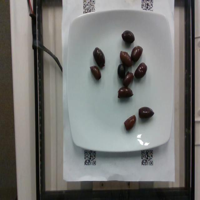

👁️ Model Gördü: Analiz:
1. Tespit: 2-samsung-s4-dark environment
2. Veri: TUBER: {'cal': '?', 'pro': '?'}

👨‍⚕️ Diyetisyen: Analiz: Bir kase mercimek çorbası ve ekmek parçası. Çorba için hafif bir başlangıç ama ekmek ekletiğinden kaçık olabilir. Kalori: 300-350 arası.

📝 Soru (Çıkış 'q'): q


In [ ]:
import os
import json
import torch
import psutil
import builtins
from unsloth import FastLanguageModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

# Psutil fix
builtins.psutil = psutil

# ==============================================================================
# 1. DOSYA YOLLARI (SADECE DERİN KLASÖRÜ)
# ==============================================================================
BASE_DIR = "/content/drive/MyDrive/derin"

# Yollar
YOLO_PATH = f"{BASE_DIR}/YOLO_High_Performance_Output/foodd_large_model/weights/best.pt"
QWEN_VL_PATH = f"{BASE_DIR}/Qwen2_VL_Pro_Model"

# Chatbot için olası yollar (Hangisi varsa onu alacak)
CHATBOT_CANDIDATES = [
    f"{BASE_DIR}/Diyetisyen_Chatbot_Brain_Qwen",
    f"{BASE_DIR}/Diyetisyen_Chatbot_Brain"
]
CHATBOT_PATH = None
for p in CHATBOT_CANDIDATES:
    if os.path.exists(p):
        CHATBOT_PATH = p
        break

print("📂 Dosya Yolları Kontrol Ediliyor...")
print(f"   YOLO:    {'✅ Bulundu' if os.path.exists(YOLO_PATH) else '❌ Yok'}")
print(f"   GÖZ:     {'✅ Bulundu' if os.path.exists(QWEN_VL_PATH) else '❌ Yok'}")
print(f"   CHATBOT: {'✅ Bulundu' if CHATBOT_PATH else '❌ Yok'}")
print("-" * 40)

# ==============================================================================
# 2. OTOMATİK TAMİR FONKSİYONU (BU HATAYI ÇÖZER)
# ==============================================================================
def fix_tokenizer_config(model_path):
    """
    Qwen modelinin config dosyasındaki 'list' vs 'dict' hatasını düzeltir.
    """
    config_file = os.path.join(model_path, "tokenizer_config.json")

    if not os.path.exists(config_file):
        print(f"⚠️ Config dosyası bulunamadı: {config_file}")
        return

    try:
        with open(config_file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        changed = False
        # Hata yapan olası anahtarlar
        keys_to_check = ["special_tokens_map_file", "added_tokens_decoder", "extra_special_tokens"]

        for key in keys_to_check:
            # Eğer bu anahtarlar varsa ve tipi liste [] ise, sözlük {} yap.
            if key in data and isinstance(data[key], list):
                print(f"🔧 ONARIM: '{key}' listesiden sözlüğe çevriliyor...")
                data[key] = {}
                changed = True

        if changed:
            with open(config_file, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=2)
            print("✅ Config dosyası başarıyla tamir edildi!")
        else:
            print("✅ Config dosyası zaten sağlam görünüyor.")

    except Exception as e:
        print(f"⚠️ Tamir sırasında hata: {e}")

# ==============================================================================
# 3. MODELLERİ YÜKLEME
# ==============================================================================

# A. YOLO
yolo_model = None
try:
    if os.path.exists(YOLO_PATH):
        yolo_model = YOLO(YOLO_PATH)
        print("✅ YOLO Yüklendi.")
except Exception as e:
    print(f"❌ YOLO Hatası: {e}")

# B. GÖZ MODELİ (Önce Tamir Et, Sonra Yükle)
qwen_model = None
qwen_processor = None

if os.path.exists(QWEN_VL_PATH):
    # 1. Önce dosyayı tamir et
    fix_tokenizer_config(QWEN_VL_PATH)

    # 2. Şimdi yükle
    try:
        print("⏳ Göz modeli yükleniyor...")
        qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
            QWEN_VL_PATH,
            torch_dtype=torch.float16,
            device_map="cuda:0",
            local_files_only=True
        )
        qwen_processor = AutoProcessor.from_pretrained(QWEN_VL_PATH, local_files_only=True)
        print("✅ Göz Modeli (Qwen-VL) Başarıyla Yüklendi.")
    except Exception as e:
        print(f"❌ Göz Modeli Yüklenemedi: {e}")
else:
    print("❌ Göz modeli klasörü yok.")

# C. CHATBOT
chat_model = None
chat_tokenizer = None

if CHATBOT_PATH:
    try:
        print("⏳ Chatbot yükleniyor...")
        chat_model, chat_tokenizer = FastLanguageModel.from_pretrained(
            model_name = CHATBOT_PATH,
            max_seq_length = 2048,
            dtype = None,
            load_in_4bit = True,
            local_files_only = True
        )
        FastLanguageModel.for_inference(chat_model)
        print("✅ Chatbot Yüklendi.")
    except Exception as e:
        print(f"❌ Chatbot Hatası: {e}")
else:
    print("❌ Chatbot yolu bulunamadı.")

print("\n🚀 SİSTEM HAZIR.\n")

# ==============================================================================
# 4. ÇALIŞTIRMA VE CEVAPLAMA
# ==============================================================================

def cevapla(soru, resim_yolu=None):
    vision_context = "Görsel yok."

    # 1. GÖRSEL ANALİZ
    if resim_yolu and os.path.exists(resim_yolu) and qwen_model and qwen_processor:
        try:
            image = Image.open(resim_yolu).convert("RGB")
            print("📸 Resim Analiz Ediliyor...")
            display(image.resize((200, 200))) # Önizleme

            processed_img = image
            # YOLO varsa kes
            if yolo_model:
                results = yolo_model(image, verbose=False)
                if results and len(results[0].boxes) > 0:
                    # En büyük kutuyu al
                    areas = [(box.xyxy[0][2]-box.xyxy[0][0])*(box.xyxy[0][3]-box.xyxy[0][1]) for box in results[0].boxes]
                    max_idx = areas.index(max(areas))
                    box = results[0].boxes[max_idx].xyxy[0].tolist()

                    pad = 15
                    x1, y1, x2, y2 = map(int, box)
                    processed_img = image.crop((
                        max(0, x1-pad), max(0, y1-pad),
                        min(image.width, x2+pad), min(image.height, y2+pad)
                    ))
                    print("✅ Yemek tabağı kesildi.")

            # Qwen Analiz
            messages = [
                {"role": "user", "content": [
                    {"type": "image", "image": processed_img},
                    {"type": "text", "text": "Describe this food. List ingredients and estimate calories."}
                ]}
            ]

            text_input = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = qwen_processor(text=[text_input], images=[processed_img], padding=True, return_tensors="pt").to("cuda")

            with torch.no_grad():
                ids = qwen_model.generate(**inputs, max_new_tokens=100)

            vision_res = qwen_processor.batch_decode(ids, skip_special_tokens=True)[0].split("assistant")[-1].strip()
            vision_context = f"Görsel Analizi (İngilizce): {vision_res}"
            print(f"👁️ Model Gördü: {vision_res}")

        except Exception as e:
            print(f"❌ Görsel hata: {e}")

    # 2. CHATBOT CEVABI
    if not chat_model:
        return "Chatbot yüklü değil."

    prompt = f"""### Talimat:
Sen uzman bir Türk diyetisyensin. Görsel analiz sonucunu (İngilizce olabilir) Türkçeye çevir, yorumla ve kullanıcının sorusuna cevap ver.

### Girdi:
Kullanıcı Sorusu: {soru}
Görsel Verisi: {vision_context}

### Yanıt:
"""
    inputs = chat_tokenizer([prompt], return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = chat_model.generate(**inputs, max_new_tokens=256, use_cache=True)

    return chat_tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("### Yanıt:")[-1].strip()

# --- ARAYÜZ ---
while True:
    msg = input("\n📝 Soru (Çıkış 'q'): ")
    if msg.lower() == 'q': break
    img = input("🖼️ Resim Yolu: ").replace('"', '').strip()

    print("⏳ Diyetisyen düşünüyor...")
    sonuc = cevapla(msg, img if img else None)
    print(f"\n👨‍⚕️ Diyetisyen: {sonuc}")

📂 Dosya Yolları Kontrol Ediliyor...
   YOLO:    ✅ Bulundu
   GÖZ:     ✅ Bulundu
   CHATBOT: ✅ Bulundu
----------------------------------------
✅ YOLO Yüklendi.
✅ Config dosyası zaten sağlam görünüyor.
⏳ Göz modeli yükleniyor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Göz Modeli (Qwen-VL) Başarıyla Yüklendi.
⏳ Chatbot yükleniyor...
==((====))==  Unsloth 2025.12.9: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Chatbot Yüklendi.

🚀 SİSTEM HAZIR.


📝 Soru (Çıkış 'q'): kaç kalori?
🖼️ Resim Yolu: /content/deneme.jpg
⏳ Diyetisyen düşünüyor...
📸 Resim Analiz Ediliyor...


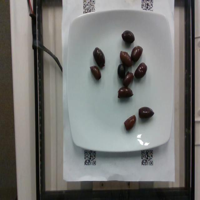

👁️ Model Gördü: Analiz:
1. Tespit: 2-samsung-s4-dark environment
2. Veri: TUBER: {'cal': '?', 'pro': '?'}

👨‍⚕️ Diyetisyen: Analiz: 2han balıklı sütlaç ve yanında bol miktardaki zeytinyağlı brokoli. Sütlaç 3-4 kaşıkla sınırlı kaldığı sürece kilo almadığını kanıtlayabilir. Balık kas onarımına destek olur. Zeytinyağlı brokoli ise lif ve lif sindirimi destekler.

📝 Soru (Çıkış 'q'): q


In [ ]:
import os
import json
import torch
import psutil
import builtins
from unsloth import FastLanguageModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

# Psutil fix
builtins.psutil = psutil

# ==============================================================================
# 1. DOSYA YOLLARI (SADECE DERİN KLASÖRÜ)
# ==============================================================================
BASE_DIR = "/content/drive/MyDrive/derin"

# Yollar
YOLO_PATH = f"{BASE_DIR}/YOLO_High_Performance_Output/foodd_large_model/weights/best.pt"
QWEN_VL_PATH = f"{BASE_DIR}/Qwen2_VL_Pro_Model"

# Chatbot için olası yollar (Hangisi varsa onu alacak)
CHATBOT_CANDIDATES = [
    f"{BASE_DIR}/Diyetisyen_Chatbot_Brain_Qwen",
    f"{BASE_DIR}/Diyetisyen_Chatbot_Brain"
]
CHATBOT_PATH = None
for p in CHATBOT_CANDIDATES:
    if os.path.exists(p):
        CHATBOT_PATH = p
        break

print("📂 Dosya Yolları Kontrol Ediliyor...")
print(f"   YOLO:    {'✅ Bulundu' if os.path.exists(YOLO_PATH) else '❌ Yok'}")
print(f"   GÖZ:     {'✅ Bulundu' if os.path.exists(QWEN_VL_PATH) else '❌ Yok'}")
print(f"   CHATBOT: {'✅ Bulundu' if CHATBOT_PATH else '❌ Yok'}")
print("-" * 40)

# ==============================================================================
# 2. OTOMATİK TAMİR FONKSİYONU (BU HATAYI ÇÖZER)
# ==============================================================================
def fix_tokenizer_config(model_path):
    """
    Qwen modelinin config dosyasındaki 'list' vs 'dict' hatasını düzeltir.
    """
    config_file = os.path.join(model_path, "tokenizer_config.json")

    if not os.path.exists(config_file):
        print(f"⚠️ Config dosyası bulunamadı: {config_file}")
        return

    try:
        with open(config_file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        changed = False
        # Hata yapan olası anahtarlar
        keys_to_check = ["special_tokens_map_file", "added_tokens_decoder", "extra_special_tokens"]

        for key in keys_to_check:
            # Eğer bu anahtarlar varsa ve tipi liste [] ise, sözlük {} yap.
            if key in data and isinstance(data[key], list):
                print(f"🔧 ONARIM: '{key}' listesiden sözlüğe çevriliyor...")
                data[key] = {}
                changed = True

        if changed:
            with open(config_file, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=2)
            print("✅ Config dosyası başarıyla tamir edildi!")
        else:
            print("✅ Config dosyası zaten sağlam görünüyor.")

    except Exception as e:
        print(f"⚠️ Tamir sırasında hata: {e}")

# ==============================================================================
# 3. MODELLERİ YÜKLEME
# ==============================================================================

# A. YOLO
yolo_model = None
try:
    if os.path.exists(YOLO_PATH):
        yolo_model = YOLO(YOLO_PATH)
        print("✅ YOLO Yüklendi.")
except Exception as e:
    print(f"❌ YOLO Hatası: {e}")

# B. GÖZ MODELİ (Önce Tamir Et, Sonra Yükle)
qwen_model = None
qwen_processor = None

if os.path.exists(QWEN_VL_PATH):
    # 1. Önce dosyayı tamir et
    fix_tokenizer_config(QWEN_VL_PATH)

    # 2. Şimdi yükle
    try:
        print("⏳ Göz modeli yükleniyor...")
        qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
            QWEN_VL_PATH,
            torch_dtype=torch.float16,
            device_map="cuda:0",
            local_files_only=True
        )
        qwen_processor = AutoProcessor.from_pretrained(QWEN_VL_PATH, local_files_only=True)
        print("✅ Göz Modeli (Qwen-VL) Başarıyla Yüklendi.")
    except Exception as e:
        print(f"❌ Göz Modeli Yüklenemedi: {e}")
else:
    print("❌ Göz modeli klasörü yok.")

# C. CHATBOT
chat_model = None
chat_tokenizer = None

if CHATBOT_PATH:
    try:
        print("⏳ Chatbot yükleniyor...")
        chat_model, chat_tokenizer = FastLanguageModel.from_pretrained(
            model_name = CHATBOT_PATH,
            max_seq_length = 2048,
            dtype = None,
            load_in_4bit = True,
            local_files_only = True
        )
        FastLanguageModel.for_inference(chat_model)
        print("✅ Chatbot Yüklendi.")
    except Exception as e:
        print(f"❌ Chatbot Hatası: {e}")
else:
    print("❌ Chatbot yolu bulunamadı.")

print("\n🚀 SİSTEM HAZIR.\n")

# ==============================================================================
# 4. ÇALIŞTIRMA VE CEVAPLAMA
# ==============================================================================

def cevapla(soru, resim_yolu=None):
    vision_context = "Görsel yok."

    # 1. GÖRSEL ANALİZ
    if resim_yolu and os.path.exists(resim_yolu) and qwen_model and qwen_processor:
        try:
            image = Image.open(resim_yolu).convert("RGB")
            print("📸 Resim Analiz Ediliyor...")
            display(image.resize((200, 200))) # Önizleme

            processed_img = image
            # YOLO varsa kes
            if yolo_model:
                results = yolo_model(image, verbose=False)
                if results and len(results[0].boxes) > 0:
                    # En büyük kutuyu al
                    areas = [(box.xyxy[0][2]-box.xyxy[0][0])*(box.xyxy[0][3]-box.xyxy[0][1]) for box in results[0].boxes]
                    max_idx = areas.index(max(areas))
                    box = results[0].boxes[max_idx].xyxy[0].tolist()

                    pad = 15
                    x1, y1, x2, y2 = map(int, box)
                    processed_img = image.crop((
                        max(0, x1-pad), max(0, y1-pad),
                        min(image.width, x2+pad), min(image.height, y2+pad)
                    ))
                    print("✅ Yemek tabağı kesildi.")

            # Qwen Analiz
            messages = [
                {"role": "user", "content": [
                    {"type": "image", "image": processed_img},
                    {"type": "text", "text": "Describe this food. List ingredients and estimate calories."}
                ]}
            ]

            text_input = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = qwen_processor(text=[text_input], images=[processed_img], padding=True, return_tensors="pt").to("cuda")

            with torch.no_grad():
                ids = qwen_model.generate(**inputs, max_new_tokens=100)

            vision_res = qwen_processor.batch_decode(ids, skip_special_tokens=True)[0].split("assistant")[-1].strip()
            vision_context = f"Görsel Analizi (İngilizce): {vision_res}"
            print(f"👁️ Model Gördü: {vision_res}")

        except Exception as e:
            print(f"❌ Görsel hata: {e}")

    # 2. CHATBOT CEVABI
    if not chat_model:
        return "Chatbot yüklü değil."

    prompt = f"""### Talimat:
Sen uzman bir Türk diyetisyensin. Görsel analiz sonucunu (İngilizce olabilir) Türkçeye çevir, yorumla ve kullanıcının sorusuna cevap ver.

### Girdi:
Kullanıcı Sorusu: {soru}
Görsel Verisi: {vision_context}

### Yanıt:
"""
    inputs = chat_tokenizer([prompt], return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = chat_model.generate(**inputs, max_new_tokens=256, use_cache=True)

    return chat_tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("### Yanıt:")[-1].strip()

# --- ARAYÜZ ---
while True:
    msg = input("\n📝 Soru (Çıkış 'q'): ")
    if msg.lower() == 'q': break
    img = input("🖼️ Resim Yolu: ").replace('"', '').strip()

    print("⏳ Diyetisyen düşünüyor...")
    sonuc = cevapla(msg, img if img else None)
    print(f"\n👨‍⚕️ Diyetisyen: {sonuc}")

In [ ]:
import os
import glob
import json
import psutil
import builtins
import gc
import shutil
import zipfile
import subprocess
from pathlib import Path

# ==============================================================================
# 0. KURULUMLAR (Eksik Kütüphaneleri Yükle)
# ==============================================================================
print("Gerekli kütüphaneler kontrol ediliyor ve yükleniyor...")
install_cmds = [
    "pip install -q -U bitsandbytes",
    "pip install -q -U git+https://github.com/huggingface/transformers.git",
    "pip install -q -U peft",
    "pip install -q -U accelerate",
    "pip install -q -U datasets",
    "pip install -q -U qwen-vl-utils"
]

for cmd in install_cmds:
    subprocess.run(cmd, shell=True)

print("Kurulumlar tamamlandi. Moduller import ediliyor...")

# Simdi import edebiliriz
import torch
from datasets import load_dataset
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from PIL import Image

# Bellek temizligi
builtins.psutil = psutil
torch.cuda.empty_cache()
gc.collect()

# ==============================================================================
# ADIM 1: VERİ HAZIRLIĞI VE ZIP KONTROLÜ
# ==============================================================================
print("\n--- VERI KONTROLU ---")

BASE_DIR = "/content/drive/MyDrive/derin"
ZIP_PATH = f"{BASE_DIR}/FooDD.zip"
IMG_EXTRACT_PATH = "/content/dataset/images/foodd"
CORRECTED_JSONL = f"{BASE_DIR}/final_train_FIXED.jsonl"

# 1. Klasör boş mu kontrol et, boşsa Zip'i aç
if not os.path.exists(IMG_EXTRACT_PATH):
    os.makedirs(IMG_EXTRACT_PATH, exist_ok=True)

# Resim var mi diye bak
existing_images = glob.glob(f"{IMG_EXTRACT_PATH}/**/*.*", recursive=True)
if len(existing_images) < 10: # Resim yoksa veya cok azsa
    print(f"Resim klasoru bos veya eksik ({len(existing_images)} resim). Zip tekrar aciliyor...")

    if os.path.exists(ZIP_PATH):
        try:
            with zipfile.ZipFile(ZIP_PATH, 'r') as z:
                z.extractall(IMG_EXTRACT_PATH)
            print("Zip basariyla acildi.")
        except Exception as e:
            print(f"HATA: Zip dosyasi acilamadi: {e}")
    else:
        print(f"KRITIK HATA: Zip dosyasi bulunamadi: {ZIP_PATH}")
        # Burada durmasin diye devam ediyoruz ama egitim hata verebilir

# 2. Resimleri tekrar say
all_images = glob.glob(f"{IMG_EXTRACT_PATH}/**/*.jpg", recursive=True) + \
             glob.glob(f"{IMG_EXTRACT_PATH}/**/*.jpeg", recursive=True) + \
             glob.glob(f"{IMG_EXTRACT_PATH}/**/*.png", recursive=True)

print(f"Toplam {len(all_images)} adet resim bulundu.")

if len(all_images) == 0:
    raise ValueError("HIC RESIM BULUNAMADI! Lutfen FooDD.zip dosyasinin yerini kontrol et.")

# ==============================================================================
# ADIM 2: VERI SETINI DUZELTME
# ==============================================================================
print("\n--- VERI SETI DUZELTILIYOR ---")

BAD_NAMES = ['samsung', 'iphone', 'pixel', 'environment', 'lighting', 'surface']
dataset_entries = []

for img_path in all_images:
    try:
        folder = Path(img_path).parent.name.lower()

        # Klasor ismi telefon markasiysa ust klasore bak
        if any(bad in folder for bad in BAD_NAMES):
            true_name = Path(img_path).parent.parent.name.lower()
        else:
            true_name = folder

        prompt = f"Tespit: {true_name}"

        dataset_entries.append({
            "image": img_path,
            "conversations": [
                {"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": "Identify this food."}]},
                {"role": "assistant", "content": [{"type": "text", "text": prompt}]}
            ]
        })
    except: continue

# Kaydet
with open(CORRECTED_JSONL, 'w', encoding='utf-8') as f:
    for entry in dataset_entries:
        json.dump(entry, f, ensure_ascii=False)
        f.write('\n')

print(f"Veri seti hazir: {CORRECTED_JSONL}")

# Hafiza temizligi
del dataset_entries
del all_images
gc.collect()

# ==============================================================================
# ADIM 3: MODEL EGITIMI (T4 UYUMLU)
# ==============================================================================
print("\n--- MODEL EGITIMI ---")

OUTPUT_DIR = f"{BASE_DIR}/Qwen2_VL_Pro_Model_FIXED"

# Model ayarlari
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Model yukleniyor...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
)

model.gradient_checkpointing_enable()
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

# LoRA ayarlari
model = prepare_model_for_kbit_training(model)
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    modules_to_save=["embed_tokens", "lm_head"]
)
model = get_peft_model(model, peft_config)

# Veriyi yukle
dataset = load_dataset("json", data_files=CORRECTED_JSONL, split="train")

def collate_fn(batch):
    texts, images = [], []
    for item in batch:
        try:
            msgs = [
                {"role": "user", "content": [{"type": "image", "image": item['image']}, {"type": "text", "text": "Identify this food."}]},
                {"role": "assistant", "content": [{"type": "text", "text": item['conversations'][1]['content'][0]['text']}]}
            ]
            text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)

            img = Image.open(item['image']).convert("RGB")
            # T4 icin 640x640 ideal
            img.thumbnail((640, 640))

            texts.append(text)
            images.append(img)
        except: continue

    if not texts: return None

    batch_out = processor(text=texts, images=images, padding=True, return_tensors="pt")

    labels = batch_out["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels == processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")] = -100
    batch_out["labels"] = labels
    return batch_out

# Egitim ayarlari
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=50,
    save_strategy="epoch",
    optim="paged_adamw_8bit",
    report_to="none",
    remove_unused_columns=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=collate_fn
)

print("Egitim baslatiliyor...")
trainer.train()

# Kaydet
print(f"Model kaydediliyor: {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

print("Islem tamamlandi")

Gerekli kütüphaneler kontrol ediliyor ve yükleniyor...
Kurulumlar tamamlandi. Moduller import ediliyor...

--- VERI KONTROLU ---
Resim klasoru bos veya eksik (0 resim). Zip tekrar aciliyor...
Zip basariyla acildi.
Toplam 2832 adet resim bulundu.

--- VERI SETI DUZELTILIYOR ---
Veri seti hazir: /content/drive/MyDrive/derin/final_train_FIXED.jsonl

--- MODEL EGITIMI ---
Model yukleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

ImportError: Using `bitsandbytes` 4-bit quantization requires the latest version of bitsandbytes: `pip install -U bitsandbytes`

# **SİL BAŞTAN BAŞLAMAK GEREK BAZEN**


# **Çalışan Kısım**

## Kütüphaneler ve Gerekli Bağlantılar

In [ ]:
import os
import subprocess
from google.colab import drive
from huggingface_hub import login

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/derin"
os.makedirs(BASE_DIR, exist_ok=True)

HF_TOKEN = "Buraya_Key_Giriniz"
login(token=HF_TOKEN)

print("Kütüphaneler kuruluyor.")
commands = [
    "pip install -q -U huggingface_hub",
    "pip install -q -U datasets",
    "pip install -q -U torch torchvision torchaudio",
    "pip install -q -U ultralytics",
    "pip install -q -U git+https://github.com/huggingface/transformers",
    "pip install -q -U accelerate peft bitsandbytes",
    "pip install -q -U qwen-vl-utils pdfplumber",
    "pip install -q -U flash-attn --no-build-isolation"
]

for cmd in commands:
    subprocess.run(cmd, shell=True)
print("Sistem hazır.")

Kütüphaneler kuruluyor.
Sistem hazır.


In [ ]:
from huggingface_hub import login
HF_TOKEN = "Buraya_Key_Giriniz"
login(token=HF_TOKEN)

## YOLO Eğitim Kısmı

In [ ]:
import os
import cv2
import shutil
import zipfile
from ultralytics import YOLO
from glob import glob
from tqdm import tqdm

BASE_DIR = "/content/drive/MyDrive/derin"
ZIP_PATH = f"{BASE_DIR}/FooDD.zip"
YOLO_WORKSPACE = f"{BASE_DIR}/YOLO_Workspace"
DATASET_DIR = f"{YOLO_WORKSPACE}/dataset"
PROJECT_OUTPUT_DIR = f"{BASE_DIR}/YOLO_Final"

print("YOLO FooDD hazirligi basladi")

if os.path.exists(YOLO_WORKSPACE):
    shutil.rmtree(YOLO_WORKSPACE)

os.makedirs(f"{DATASET_DIR}/images/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/labels/train", exist_ok=True)

TEMP_EXTRACT = "/content/temp_foodd"
if os.path.exists(TEMP_EXTRACT):
    shutil.rmtree(TEMP_EXTRACT)

print("Zip dosyasi aciliyor")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(TEMP_EXTRACT)

print("Resimler FooDD kaynakli olarak etiketleniyor")
teacher = YOLO('yolov8x.pt')
all_imgs = glob(f"{TEMP_EXTRACT}/**/*.jpg", recursive=True) + \
           glob(f"{TEMP_EXTRACT}/**/*.png", recursive=True) + \
           glob(f"{TEMP_EXTRACT}/**/*.jpeg", recursive=True)

count = 0
for img_path in tqdm(all_imgs):
    img = cv2.imread(img_path)
    if img is None: continue

    res = teacher(img, verbose=False, conf=0.25)
    labels = []

    for r in res:
        for box in r.boxes.xywhn.cpu().numpy():
            labels.append(f"0 {box[0]} {box[1]} {box[2]} {box[3]}")

    if labels:
        fname = f"foodd_{count}"
        cv2.imwrite(f"{DATASET_DIR}/images/train/{fname}.jpg", img)
        with open(f"{DATASET_DIR}/labels/train/{fname}.txt", 'w') as f:
            f.write("\n".join(labels))
        count += 1

yaml_path = f"{YOLO_WORKSPACE}/foodd_data.yaml"
with open(yaml_path, 'w') as f:
    f.write(f"path: {DATASET_DIR}\n")
    f.write(f"train: images/train\n")
    f.write(f"val: images/train\n")
    f.write(f"names:\n  0: food_plate\n")

print(f"Egitim basliyor. Toplam {count} resim FooDD'den hazirlandi.")
model = YOLO('yolov8l.pt')

model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    patience=10,
    project=PROJECT_OUTPUT_DIR,
    name='foodd_large_model',
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    exist_ok=True
)

print(f"YOLO egitimi bitti. Model Drive'da: {PROJECT_OUTPUT_DIR}/foodd_large_model/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO FooDD hazirligi basladi
Zip dosyasi aciliyor
Resimler FooDD kaynakli olarak etiketleniyor


100%|██████████| 2832/2832 [05:18<00:00,  8.89it/s]


Egitim basliyor. Toplam 2759 resim FooDD'den hazirlandi.
Ultralytics 8.3.243 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/derin/YOLO_Workspace/foodd_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=foodd_large_model, nbs=64, nms=False, o

In [2]:
import os
import shutil

model_yolu = "/content/drive/MyDrive/derin/Qwen_Pro_Analiz_Model"
bozuk_jsonl_1 = "/content/drive/MyDrive/derin/qwen_clean_train.jsonl"
bozuk_jsonl_2 = "/content/drive/MyDrive/derin/qwen_fixed_train.jsonl"

if os.path.exists(model_yolu):
    shutil.rmtree(model_yolu)
    print(f"✅ Bozuk model klasörü silindi: {model_yolu}")
else:
    print("ℹ️ Model klasörü zaten yok.")

for dosya in [bozuk_jsonl_1, bozuk_jsonl_2]:
    if os.path.exists(dosya):
        os.remove(dosya)
        print(f"✅ Hatalı veri dosyası silindi: {dosya}")

print("\n🚀 Drive temizlendi! Hugging Face verileriyle 'adam akıllı' bir başlangıca hazırsın.")

✅ Bozuk model klasörü silindi: /content/drive/MyDrive/derin/Qwen_Pro_Analiz_Model
✅ Hatalı veri dosyası silindi: /content/drive/MyDrive/derin/qwen_clean_train.jsonl

🚀 Drive temizlendi! Hugging Face verileriyle 'adam akıllı' bir başlangıca hazırsın.


In [5]:
!pip uninstall -y huggingface_hub datasets transformers accelerate peft
!pip install -U huggingface_hub datasets transformers accelerate peft bitsandbytes qwen-vl-utils flash-attn

Found existing installation: huggingface_hub 1.2.4
Uninstalling huggingface_hub-1.2.4:
  Successfully uninstalled huggingface_hub-1.2.4
Found existing installation: datasets 4.4.2
Uninstalling datasets-4.4.2:
  Successfully uninstalled datasets-4.4.2
Found existing installation: transformers 5.0.0.dev0
Uninstalling transformers-5.0.0.dev0:
  Successfully uninstalled transformers-5.0.0.dev0
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0
Found existing installation: peft 0.18.0
Uninstalling peft-0.18.0:
  Successfully uninstalled peft-0.18.0
  Using cached huggingface_hub-1.2.4-py3-none-any.whl.metadata (13 kB)
  Using cached datasets-4.4.2-py3-none-any.whl.metadata (19 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
Using cached datasets-4.4.2-py3-none-any.whl (512 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

## HF Verileri İçin Ön Hazırlık

In [16]:
from huggingface_hub import hf_hub_download
import pandas as pd
import json
import os

print("Metadata dosyası aranıyor...")
try:
    metadata_path = hf_hub_download(repo_id="mmathys/food-nutrients",
                                    filename="metadata.jsonl",
                                    repo_type="dataset",
                                    token=HF_TOKEN)
    print(f"✅ Metadata bulundu: {metadata_path}")

    with open(metadata_path, 'r') as f:
        sample_meta = json.loads(f.readline())
        print("Tespit edilen kolonlar:", sample_meta.keys())
except Exception as e:
    print(f"Metadata dosyasına direkt ulaşılamadı: {e}")
    print("Alternatif yöntem: Veri setini tüm bileşenleriyle yüklemeyi deniyoruz...")

Metadata dosyası aranıyor...


metadata.jsonl: 0.00B [00:00, ?B/s]

✅ Metadata bulundu: /root/.cache/huggingface/hub/datasets--mmathys--food-nutrients/snapshots/cf7141da31f04373f14d17f0078d351937522f02/metadata.jsonl
Tespit edilen kolonlar: dict_keys(['file_name', 'id', 'split', 'ingredients', 'total_calories', 'total_mass', 'total_fat', 'total_carb', 'total_protein'])


## Eğitim Öncesi Son Kontrol

In [20]:
import json
import os
from tqdm import tqdm

BASE_DIR = "/content/drive/MyDrive/derin"
image_save_dir = os.path.join(BASE_DIR, "dataset_images/food_nutrients")
output_jsonl = os.path.join(BASE_DIR, "qwen_food_all.jsonl")
metadata_path = "/root/.cache/huggingface/hub/datasets--mmathys--food-nutrients/snapshots/cf7141da31f04373f14d17f0078d351937522f02/metadata.jsonl"

os.makedirs(image_save_dir, exist_ok=True)

print("Gercek veriler metadata dosyasindan okunuyor...")

with open(metadata_path, "r", encoding="utf-8") as meta_file, \
     open(output_jsonl, "w", encoding="utf-8") as out_file:

    for i, line in enumerate(tqdm(meta_file)):
        data = json.loads(line)

        img_path = os.path.join(image_save_dir, f"food_{i}.jpg")

        ingredients_raw = data.get('ingredients', [])
        ingredients_list = []

        if isinstance(ingredients_raw, list):
            for ing in ingredients_raw:
                if isinstance(ing, dict):
                    ingredients_list.append(ing.get('text') or ing.get('name') or str(ing))
                else:
                    ingredients_list.append(str(ing))

        if len(ingredients_list) > 0:
            food_name = ", ".join(ingredients_list[:3])
        else:
            food_name = "Bilinmeyen Yemek"

        calories = data.get('total_calories', 0)
        protein = data.get('total_protein', 0)
        fat = data.get('total_fat', 0)
        carb = data.get('total_carb', 0)

        ans = f"Yemek: {food_name}. Enerji: {calories} kcal, Protein: {protein}g, Yag: {fat}g, Karbonhidrat: {carb}g."

        entry = {
            "image": img_path,
            "conversations": [
                {"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": "Bu yemegi analiz ederek besin degerlerini belirtiniz."}]},
                {"role": "assistant", "content": [{"type": "text", "text": ans}]}
            ]
        }
        out_file.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"\nIslem tamamlandi. Veri seti hazırlandı.")

Gercek veriler metadata dosyasindan okunuyor...


3260it [00:00, 21626.66it/s]


Islem tamamlandi. Veri seti hazırlandı.


In [21]:
import json
import random

file_path = "/content/drive/MyDrive/derin/qwen_food_all.jsonl"

def veri_seti_kontrol(dosya_yolu, ornek_sayisi=5):
    try:
        with open(dosya_yolu, "r", encoding="utf-8") as f:
            satirlar = f.readlines()

        toplam_kayit = len(satirlar)
        print(f"Toplam Kayit Sayisi: {toplam_kayit}")
        print("-" * 50)

        ornekler = random.sample(satirlar, min(ornek_sayisi, toplam_kayit))

        for i, satir in enumerate(ornekler):
            data = json.loads(satir)

            gorsel_yolu = data.get("image", "Bulunamadi")
            cevap = data["conversations"][1]["content"][0]["text"]

            print(f"Ornek {i+1}:")
            print(f"Dizin: {gorsel_yolu}")
            print(f"Icerik: {cevap}")
            print("-" * 30)

    except FileNotFoundError:
        print("Hata: Belirtilen dizinde jsonl dosyasi bulunamadi.")
    except Exception as e:
        print(f"Bir hata olustu: {e}")

veri_seti_kontrol(file_path)

Toplam Kayit Sayisi: 3260
--------------------------------------------------
Ornek 1:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_1003.jpg
Icerik: Yemek: pizza. Enerji: 98.420006 kcal, Protein: 4.07g, Yag: 3.589g, Karbonhidrat: 12.21g.
------------------------------
Ornek 2:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_914.jpg
Icerik: Yemek: grapefruit juice. Enerji: 94.527 kcal, Protein: 1.215g, Yag: 0.243g, Karbonhidrat: 22.112999g.
------------------------------
Ornek 3:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_571.jpg
Icerik: Yemek: cauliflower. Enerji: 19.75 kcal, Protein: 1.422g, Yag: 0.237g, Karbonhidrat: 3.95g.
------------------------------
Ornek 4:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_3016.jpg
Icerik: Yemek: mixed greens, olives. Enerji: 130.130005 kcal, Protein: 2.73g, Yag: 10.101001g, Karbonhidrat: 10.556g.
------------------------------
Ornek 5:
Dizin: /cont

In [30]:
import json
import os
from tqdm import tqdm

BASE_DIR = "/content/drive/MyDrive/derin"
image_save_dir = os.path.join(BASE_DIR, "dataset_images/food_nutrients")
output_jsonl = os.path.join(BASE_DIR, "qwen_food_all.jsonl")
metadata_path = "/root/.cache/huggingface/hub/datasets--mmathys--food-nutrients/snapshots/cf7141da31f04373f14d17f0078d351937522f02/metadata.jsonl"

print("Veriler yuvarlanarak yeniden isleniyor...")

with open(metadata_path, "r", encoding="utf-8") as meta_file, \
     open(output_jsonl, "w", encoding="utf-8") as out_file:

    for i, line in enumerate(tqdm(meta_file)):
        data = json.loads(line)
        img_path = os.path.join(image_save_dir, f"food_{i}.jpg")

        ingredients_raw = data.get('ingredients', [])
        ingredients_list = [ing.get('text') or ing.get('name') or str(ing) if isinstance(ing, dict) else str(ing) for ing in ingredients_raw]
        food_name = ", ".join(ingredients_list[:3]) if ingredients_list else "Bilinmeyen Yemek"

        calories = round(float(data.get('total_calories', 0)), 1)
        protein = round(float(data.get('total_protein', 0)), 1)
        fat = round(float(data.get('total_fat', 0)), 1)
        carb = round(float(data.get('total_carb', 0)), 1)

        ans = f"Yemek: {food_name}. Enerji: {calories} kcal, Protein: {protein}g, Yag: {fat}g, Karbonhidrat: {carb}g."

        entry = {
            "image": img_path,
            "conversations": [
                {"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": "Bu yemegi analiz ederek besin degerlerini belirtiniz."}]},
                {"role": "assistant", "content": [{"type": "text", "text": ans}]}
            ]
        }
        out_file.write(json.dumps(entry, ensure_ascii=False) + "\n")

print("\n✅ Veri seti sadeleştirildi. Artik egitime gecebilirsin.")

Veriler yuvarlanarak yeniden isleniyor...


3260it [00:00, 19514.66it/s]


✅ Veri seti sadeleştirildi. Artik egitime gecebilirsin.


In [31]:
import json
import random

file_path = "/content/drive/MyDrive/derin/qwen_food_all.jsonl"

def veri_seti_kontrol(dosya_yolu, ornek_sayisi=5):
    try:
        with open(dosya_yolu, "r", encoding="utf-8") as f:
            satirlar = f.readlines()

        toplam_kayit = len(satirlar)
        print(f"Toplam Kayit Sayisi: {toplam_kayit}")
        print("-" * 50)

        ornekler = random.sample(satirlar, min(ornek_sayisi, toplam_kayit))

        for i, satir in enumerate(ornekler):
            data = json.loads(satir)

            gorsel_yolu = data.get("image", "Bulunamadi")
            cevap = data["conversations"][1]["content"][0]["text"]

            print(f"Ornek {i+1}:")
            print(f"Dizin: {gorsel_yolu}")
            print(f"Icerik: {cevap}")
            print("-" * 30)

    except FileNotFoundError:
        print("Hata: Belirtilen dizinde jsonl dosyasi bulunamadi.")
    except Exception as e:
        print(f"Bir hata olustu: {e}")
veri_seti_kontrol(file_path)

Toplam Kayit Sayisi: 3260
--------------------------------------------------
Ornek 1:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_2619.jpg
Icerik: Yemek: wheat berry, carrot, salt. Enerji: 154.4 kcal, Protein: 4.4g, Yag: 4.2g, Karbonhidrat: 27.4g.
------------------------------
Ornek 2:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_456.jpg
Icerik: Yemek: apple, corn on the cob, cantaloupe. Enerji: 219.4 kcal, Protein: 5.6g, Yag: 2.9g, Karbonhidrat: 50.6g.
------------------------------
Ornek 3:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_102.jpg
Icerik: Yemek: cantaloupe. Enerji: 30.6 kcal, Protein: 0.7g, Yag: 0.2g, Karbonhidrat: 7.2g.
------------------------------
Ornek 4:
Dizin: /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_3037.jpg
Icerik: Yemek: fish, chicken thighs, mushroom. Enerji: 355.3 kcal, Protein: 44.9g, Yag: 23.9g, Karbonhidrat: 9.4g.
------------------------------
Ornek 5:
Di

## QWEN (Görsel) Eğitim Kısmı

In [33]:
import torch
import json
import os
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model
from qwen_vl_utils import process_vision_info
from torch.utils.data import Dataset

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
JSONL_PATH = "/content/drive/MyDrive/derin/qwen_food_all.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/derin/Qwen_Food_Final_Model"

class QwenFoodDataset(Dataset):
    def __init__(self, jsonl_path, processor):
        self.data = []
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                self.data.append(json.loads(line))
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(examples):
    messages = [example["conversations"] for example in examples]

    texts = [processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True) for msg in messages]
    image_inputs, _ = process_vision_info(messages)

    batch = processor(text=texts, images=image_inputs, padding=True, return_tensors="pt")

    labels = batch["input_ids"].clone()

    labels[labels == processor.tokenizer.pad_token_id] = -100
    image_token_id = processor.tokenizer.convert_tokens_to_ids(processor.image_token)
    labels[labels == image_token_id] = -100

    for i in range(len(texts)):
        parts = texts[i].split("<|im_start|>assistant\n")
        if len(parts) > 1:
            prompt_text = parts[0] + "<|im_start|>assistant\n"
            prompt_ids = processor.tokenizer.encode(prompt_text, add_special_tokens=False)
            prompt_len = len(prompt_ids)
            labels[i, :prompt_len] = -100

    batch["labels"] = labels
    return batch

print("🧠 Model ve İşlemci yükleniyor...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    _attn_implementation="flash_attention_2",
    device_map="auto"
)

model.config.use_cache = False
model.enable_input_require_grads()

peft_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    num_train_epochs=3,
    bf16=True,
    logging_steps=5,
    save_strategy="steps",
    save_steps=200,
    optim="adamw_torch",
    gradient_checkpointing=True,
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=QwenFoodDataset(JSONL_PATH, processor),
    data_collator=collate_fn
)

print("🚀 Eğitim başlıyor! Loss değerleri sadece cevaplar üzerinden hesaplanıyor...")
trainer.train()

model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f"✅ İşlem bitti! Model buraya kaydedildi: {OUTPUT_DIR}")

🧠 Model ve İşlemci yükleniyor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


🚀 Eğitim başlıyor! Loss değerleri sadece cevaplar üzerinden hesaplanıyor...


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step,Training Loss
5,2.082200
10,0.808700
15,0.602300
20,0.558400
25,0.531500
30,0.511000
35,0.500100
40,0.497400
45,0.496000
50,0.484500


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


✅ İşlem bitti! Model buraya kaydedildi: /content/drive/MyDrive/derin/Qwen_Food_Final_Model


## QWEN Test Kısmı

In [28]:
import json
import os

path = "/content/drive/MyDrive/derin/qwen_food_all.jsonl"

print(f"{'No':<4} | {'Gorsel Mevcut mu?':<18} | {'Hedef Yanit'}")
print("-" * 100)

with open(path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 20:
            break

        data = json.loads(line)
        gorsel_yolu = data['image']
        yanit = data['conversations'][1]['content'][0]['text']

        mevcut = "VAR" if os.path.exists(gorsel_yolu) else "YOK !!!"

        print(f"{i:<4} | {mevcut:<18} | {yanit}")

No   | Gorsel Mevcut mu?  | Hedef Yanit
----------------------------------------------------------------------------------------------------
0    | VAR                | Yemek: olives. Enerji: 41.399998 kcal, Protein: 0.288g, Yag: 3.852g, Karbonhidrat: 2.268g.
1    | VAR                | Yemek: mixed greens. Enerji: 6.44 kcal, Protein: 0.506g, Yag: 0.092g, Karbonhidrat: 1.219g.
2    | VAR                | Yemek: olives. Enerji: 71.299995 kcal, Protein: 0.496g, Yag: 6.634g, Karbonhidrat: 3.906g.
3    | VAR                | Yemek: brussels sprouts. Enerji: 27.52 kcal, Protein: 2.176g, Yag: 0.192g, Karbonhidrat: 5.76g.
4    | VAR                | Yemek: celery. Enerji: 4.48 kcal, Protein: 0.196g, Yag: 0.056g, Karbonhidrat: 0.952g.
5    | VAR                | Yemek: celery, olives, brussels sprouts. Enerji: 103.300003 kcal, Protein: 2.868g, Yag: 6.882g, Karbonhidrat: 10.618g.
6    | VAR                | Yemek: celery, olives, brussels sprouts. Enerji: 103.300003 kcal, Protein: 2.868g, Yag: 

In [34]:
from qwen_vl_utils import process_vision_info
from PIL import Image
import torch

model.eval()

def analiz_et(image_path):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": "Bu yemegi analiz ederek besin degerlerini belirtiniz."}
            ],
        }
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to("cuda")

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=128)
        generated_ids_trimmed = [
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)

    return output_text[0]

test_resmi = "/content/drive/MyDrive/derin/dataset_images/food_nutrients/food_15.jpg"
print(f"Model Analizi: {analiz_et(test_resmi)}")

Model Analizi: Yemek: salmon. Enerji: 29.0 kcal, Protein: 2.9g, Yag: 0.4g, Karbonhidrat: 2.8g.


## QWEN (CHATBOT) Eğitim Kısmı

In [35]:
import json
from google.colab import drive
drive.mount('/content/drive')


diet_data = [
    {
        "instruction": "Kullanıcı: Bu yemeği akşam yiyebilir miyim? Diyeti bozar mı?",
        "input": "Analiz: Tabakta bol tereyağlı İskender Kebap, yanında yoğurt ve pide parçaları var.",
        "output": "İskender Kebap lezzetli ama kalorisi oldukça yüksek bir tercihtir. Özellikle altındaki yağlı pideler karbonhidrat yükünü artırır. Eğer bunu akşam yiyeceksen; pidesinin yarısını bırakmanı, tereyağı ekletmemeni ve yanında mutlaka ekstra yeşillik tüketmeni öneririm. Ertesi gün kahvaltıyı hafif yaparak dengeleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Canım çok çekti, bir porsiyon yesem ne olur?",
        "input": "Analiz: Bir tabak tereyağlı ve soslu Kayseri Mantısı.",
        "output": "Mantı hem hamur (karbonhidrat) hem de kıyma (protein) içerse de sosundaki yağ miktarı onu ağırlaştırır. Bir porsiyon mantı ortalama 400-500 kaloridir. Eğer öğlen yiyorsan sorun yok, ancak akşam için porsiyonu yarıya indirip yanına büyük bir kase yağsız salata eklemeni tavsiye ederim."
    },
    {
        "instruction": "Kullanıcı: Lahmacun diyette yasak mı?",
        "input": "Analiz: 2 adet Lahmacun ve yanında bol yeşillik, limon.",
        "output": "Aslında lahmacun, ince hamuru ve sebzeli kıyma harcıyla pizzadan çok daha sağlıklı bir alternatiftir! Diyette yasak değildir. 2 lahmacun bir ana öğün yerine geçer. Yanındaki yeşillikleri bolca içine koyup, ayran ile tüketirsen kan şekerini dengelersin. Afiyet olsun!"
    },
    {
        "instruction": "Kullanıcı: Tatlı krizim tuttu, bunu yesem çok mu kilo alırım?",
        "input": "Analiz: Bir porsiyon şerbetli Künefe ve yanında kaymak.",
        "output": "Künefe, şerbet ve peynir yağı nedeniyle glisemik indeksi çok yüksek bir tatlıdır. Bir porsiyonu bir ana öğüne eşdeğer kalori içerebilir. Tavsiyem: Bunu tek başına yeme, bir arkadaşınla paylaş. Yanında süt veya sade kahve içerek kan şekerini dengelemeye çalış. Ve bunu haftada 1 kereden fazla yapmamaya özen göster."
    },

    {
        "instruction": "Kullanıcı: Bu öğün sizce nasıl? Yeterli mi?",
        "input": "Analiz: Izgara tavuk göğsü, haşlanmış brokoli ve az miktar bulgur pilavı.",
        "output": "Mükemmel bir tabak! Protein (tavuk), lif (brokoli) ve kompleks karbonhidrat (bulgur) dengesi harika kurulmuş. Bu öğün seni uzun süre tok tutar ve kas gelişimini destekler. Bu şekilde beslenmeye devam et!"
    },
    {
        "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, iyi mi?",
        "input": "Analiz: Menemen, 2 dilim tam buğday ekmeği ve 5 adet zeytin.",
        "output": "Gayet dengeli ve Türk damak tadına uygun sağlıklı bir kahvaltı. Menemen hem sebze hem protein kaynağıdır. Ekmek bandırırken aşırıya kaçmamaya dikkat ettiğin sürece güne başlamak için harika bir seçim."
    },
    {
        "instruction": "Kullanıcı: Akşam yemeği için hafif mi yoksa az mı olmuş?",
        "input": "Analiz: Bir kase mercimek çorbası ve mevsim salatası.",
        "output": "Akşam yemeği için oldukça hafif ve mideyi yormayan bir tercih. Mercimek çorbası bitkisel protein ve lif içerir. Eğer çok aç hissediyorsan çorbanın içine biraz limon sıkmak veya salatana biraz lor peyniri eklemek tokluk süreni artırabilir."
    },

    {
        "instruction": "Kullanıcı: Arkadaşlarla dışarıdayız, hamburger söyledim. Ne yapmalıyım?",
        "input": "Analiz: Büyük boy Hamburger menüsü, patates kızartması ve kola.",
        "output": "Sosyal ortamlarda bazen kaçamaklar olabilir. Zararı en aza indirmek için şunları yapabilirsin: Hamburgerin ekmeğinin üst kısmını ayırarak 'açık hamburger' gibi ye. Patates kızartmasını arkadaşlarınla paylaş ve içecek olarak kola yerine ayran veya su tercih et. Bu küçük değişiklikler yüzlerce kalori tasarruf etmeni sağlar."
    },
    {
        "instruction": "Kullanıcı: Film izlerken atıştırmak istiyorum?",
        "input": "Analiz: Bir kase patlamış mısır (yağsız görünüyor).",
        "output": "Evde az yağlı ve az tuzlu patlatılmış mısır, cipslerden çok daha masum bir atıştırmalıktır. Lif oranı yüksektir. Bir su bardağı kadar yemenin diyete bir zararı olmaz. Keyfini çıkar!"
    },

    {
        "instruction": "Kullanıcı: Spordan çıktım, bu yeterli mi?",
        "input": "Analiz: Ton balıklı salata ve bir adet muz.",
        "output": "Antrenman sonrası için çok doğru bir seçim. Ton balığı kas onarımı için gerekli proteini sağlarken, muz boşalan glikojen depolarını (enerji) hızlıca doldurmana yardımcı olur. Belki yanına bir dilim tam tahıllı ekmek de ekleyebilirsin."
    },
    {
        "instruction": "Kullanıcı: Bugün hiç sebze yemedim, bu tabak dengeler mi?",
        "input": "Analiz: Zeytinyağlı taze fasulye ve cacık.",
        "output": "Evet, kesinlikle dengeler. Zeytinyağlı fasulye hem lifli hem de sindirimi kolay bir sebze yemeğidir. Cacık ise protein desteği sağlar. Gün içindeki sebze açığını kapatmak için çok iyi bir akşam yemeği tercihi."
    },
    {
        "instruction": "Kullanıcı: Kilo vermeye çalışıyorum ama pilavdan vazgeçemiyorum.",
        "input": "Analiz: Beyaz pirinç pilavı ve nohut yemeği.",
        "output": "Pirinç pilavı kan şekerini hızlı yükseltip çabuk acıktırabilir. Eğer kilo verme sürecindeysen, beyaz pirinç yerine bulgur pilavı veya karabuğday tercih etmen daha iyi olur. Ancak nohutla birlikte yediğin için baklagil lifi şekeri biraz dengeler. Porsiyonu 3-4 kaşıkla sınırlı tutmalısın."
    },
     {
        "instruction": "Kullanıcı: Sabahları vaktim yok, bu beni öğlene kadar tutar mı?",
        "input": "Analiz: Yulaf ezmesi, süt, chia tohumu ve çilek karışımı.",
        "output": "Harika bir pratik kahvaltı! Yulaf ve chia tohumu midende şişerek uzun süre tokluk hissi verir. Süt protein kaynağıdır. Bu karışım seni öğlene kadar rahatlıkla tok tutar ve tatlı ihtiyacını da doğal yoldan karşılar."
    },
    {
        "instruction": "Kullanıcı: Gece çok acıktım, bunu yesem uyuyabilir miyim?",
        "input": "Analiz: Bir avuç çiğ badem ve bir bardak kefir.",
        "output": "Gece atıştırmalığı için en güvenli seçeneklerden biri. Kefir sindirimi düzenler ve rahatlatır, badem ise sağlıklı yağlar içerir. Meyve veya şekerli şeyler yerine bunu tercih etmen kan şekerini oynatmadan rahat uyumanı sağlar."
    },
    {
    "instruction": "Kullanıcı: Bu yemek kilo aldırır mı?",
    "input": "Analiz: Etli kuru fasulye ve yanında beyaz pilav.",
    "output": "Kuru fasulye protein ve lif açısından çok değerlidir ancak beyaz pilavla birlikte tüketildiğinde karbonhidrat yükü artar. Pilavı 3-4 kaşıkla sınırlarsan ve yanına salata eklersen kilo aldırıcı etkisi büyük ölçüde azalır."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu yiyebilir miyim?",
    "input": "Analiz: Zeytinyağlı enginar.",
    "output": "Kesinlikle yiyebilirsin. Zeytinyağlı enginar karaciğer dostu, liften zengin ve hafif bir yemektir. Porsiyon kontrolüne dikkat ettiğin sürece diyetin en güzel parçalarından biri olur."
  },
  {
    "instruction": "Kullanıcı: Akşam için ağır olur mu?",
    "input": "Analiz: Tavuk şiş, lavaş ve közlenmiş sebzeler.",
    "output": "Tavuk şiş protein açısından çok iyi bir tercih. Lavaşı yarım porsiyonla sınırlayıp sebzeleri bol tutarsan akşam için gayet dengeli bir öğün olur."
  },
  {
    "instruction": "Kullanıcı: Tatlı yerine bunu yesem olur mu?",
    "input": "Analiz: Fırınlanmış kabak tatlısı (şekersiz).",
    "output": "Şekersiz fırınlanmış kabak tatlısı tatlı isteğini bastırmak için çok iyi bir alternatif. Üzerine ceviz ekleyerek hem lezzeti hem tokluğu artırabilirsin."
  },
  {
    "instruction": "Kullanıcı: Çorba içmek yeterli mi?",
    "input": "Analiz: Tarhana çorbası.",
    "output": "Tarhana besleyici bir çorbadır ancak tek başına ana öğün için yetersiz kalabilir. Yanına yoğurt veya küçük bir protein eklemeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Kahvaltıda bunu yiyorum, doğru mu?",
    "input": "Analiz: Sucuklu yumurta ve beyaz ekmek.",
    "output": "Sucuklu yumurta ara sıra tüketildiğinde sorun olmaz fakat her gün için ağır bir seçimdir. Ekmek miktarını azaltıp yanına sebze eklersen daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek şişkinlik yapar mı?",
    "input": "Analiz: Nohutlu bulgur pilavı.",
    "output": "Baklagiller hassas midelerde şişkinlik yapabilir. Yavaş yiyip porsiyonu abartmazsan genellikle sorun yaşanmaz. Kimyon eklemek sindirimi kolaylaştırır."
  },
  {
    "instruction": "Kullanıcı: Spor sonrası uygun mu?",
    "input": "Analiz: Izgara köfte ve yoğurt.",
    "output": "Izgara köfte protein açısından spor sonrası için uygundur. Yağ oranı düşükse ve kızartma değilse kas onarımına katkı sağlar."
  },
  {
    "instruction": "Kullanıcı: Diyette simit yenir mi?",
    "input": "Analiz: Bir adet simit ve çay.",
    "output": "Simit tamamen yasak değil ama karbonhidrat ağırlıklıdır. Yanına peynir veya ayran eklemezsen çabuk acıktırabilir."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem geç sindirilir mi?",
    "input": "Analiz: Etli yaprak sarma.",
    "output": "Etli sarma yağlıysa gece sindirimi zorlayabilir. 6-7 adetle sınırlayıp yoğurtla tüketirsen daha rahat olur."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bunu gönül rahatlığıyla yiyebilir miyim?",
    "input": "Analiz: Mercimek köftesi ve bol yeşillik.",
    "output": "Mercimek köftesi lif ve bitkisel protein açısından oldukça zengindir. Yağ miktarı abartılmadığı sürece diyette rahatlıkla tüketilebilir. Yanında ayranla çok güzel dengelenir."
  },
  {
    "instruction": "Kullanıcı: Akşam yemeği için uygun mu?",
    "input": "Analiz: Izgara levrek, roka salatası ve limon.",
    "output": "Harika bir akşam yemeği seçimi. Balık hafif ve kaliteli protein içerir. Salatayla birlikte tüketildiğinde sindirimi kolay ve tok tutucudur."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kilo yapar mı?",
    "input": "Analiz: Etli keşkek.",
    "output": "Keşkek besleyici ama kalorisi yüksek bir yemektir. Küçük bir porsiyonla sınırlarsan ve yanında ekstra ekmek yemezsen kilo kontrolünü bozmaz."
  },
  {
    "instruction": "Kullanıcı: Öğlen için yeterli olur mu?",
    "input": "Analiz: Sebzeli omlet ve 1 dilim tam buğday ekmeği.",
    "output": "Protein ve sebze dengesi çok güzel. Öğlen için yeterli ve tok tutucu bir öğün olur. Yanına bir kase yoğurt eklersen daha da dengelenir."
  },
  {
    "instruction": "Kullanıcı: Diyette pide yenir mi?",
    "input": "Analiz: Kıymalı pide.",
    "output": "Pide tamamen yasak değil ama porsiyon çok önemli. Yarım porsiyon kıymalı pideyi bol salata ve ayranla tüketirsen denge sağlanabilir."
  },
  {
    "instruction": "Kullanıcı: Tatlı isteğim için iyi bir alternatif mi?",
    "input": "Analiz: Fırında sütlaç (şekeri azaltılmış).",
    "output": "Şekeri azaltılmış sütlaç tatlı ihtiyacını bastırmak için güzel bir tercihtir. Porsiyonu küçük tuttuğun sürece diyeti bozmaz."
  },
  {
    "instruction": "Kullanıcı: Gece yemeği olarak ağır mı?",
    "input": "Analiz: Peynirli gözleme.",
    "output": "Gözleme hamur ağırlıklı olduğu için gece için ağır olabilir. Eğer çok açsan yarım porsiyonla yetinmeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Bu yemek sağlıklı sayılır mı?",
    "input": "Analiz: Zeytinyağlı barbunya.",
    "output": "Evet, zeytinyağlı barbunya hem lif hem bitkisel protein içerir. Soğuk olarak tüketildiğinde sindirimi daha da kolaylaşır."
  },
  {
    "instruction": "Kullanıcı: Spor gününde bunu yesem olur mu?",
    "input": "Analiz: Tavuklu sebze sote.",
    "output": "Spor günleri için çok uygun bir öğün. Tavuk kas onarımına destek olurken sebzeler vitamin-mineral ihtiyacını karşılar."
  },
  {
    "instruction": "Kullanıcı: Diyette çiğ köfte yasak mı?",
    "input": "Analiz: 5 adet etsiz çiğ köfte ve marul.",
    "output": "Etsiz çiğ köfte porsiyon kontrolüyle tüketildiğinde diyete uygundur. Lavaş eklemeden ve sayıyı abartmadan yemen önemli."
  },
  {
    "instruction": "Kullanıcı: Sabahları bunu yiyorum, yeterli mi?",
    "input": "Analiz: Peynir, zeytin, domates ve salatalık.",
    "output": "Klasik ama sağlıklı bir Türk kahvaltısı. Eğer uzun süre tok kalmak istiyorsan yanına bir yumurta veya tam buğday ekmeği ekleyebilirsin."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Tuzlu beyaz peynir ve ekmek.",
    "output": "Tuz oranı yüksek olduğu için ödem yapabilir. Peyniri az tuzlu tercih etmek ve su tüketimini artırmak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Dışarıda en masum seçim bu mu?",
    "input": "Analiz: Balık ekmek.",
    "output": "Balık ekmek kızartma olmadığı sürece dışarıda yenebilecek en masum seçeneklerden biridir. Sos ekletmemeye dikkat et."
  },
  {
    "instruction": "Kullanıcı: Diyette çorba olarak hangisi iyi?",
    "input": "Analiz: Ezogelin çorbası.",
    "output": "Ezogelin çorbası hem lifli hem besleyicidir. Tek başına öğün yerine geçmez ama ana yemeğe güzel bir başlangıçtır."
  },
  {
    "instruction": "Kullanıcı: Bu yemek kan şekerimi yükseltir mi?",
    "input": "Analiz: Beyaz pirinç pilavı.",
    "output": "Beyaz pirinç pilavı kan şekerini hızlı yükseltebilir. Yanına protein eklemek ve porsiyonu küçültmek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Akşam için hafif mi?",
    "input": "Analiz: Yoğurtlu semizotu salatası.",
    "output": "Çok hafif ve ferahlatıcı bir akşam yemeği. Özellikle sıcak havalarda mideyi yormaz."
  },
  {
    "instruction": "Kullanıcı: Diyette börek yenir mi?",
    "input": "Analiz: Peynirli su böreği.",
    "output": "Su böreği yağ ve hamur açısından zengindir. Diyetteyken çok nadir ve küçük porsiyonlarla tüketilmelidir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek tok tutar mı?",
    "input": "Analiz: Kırmızı mercimek çorbası.",
    "output": "Mercimek çorbası lif ve protein içerdiği için diğer çorbalara göre daha tok tutucudur. Yanına salata eklersen etkisi artar."
  },
  {
    "instruction": "Kullanıcı: Haftada bir bunu yesem sorun olur mu?",
    "input": "Analiz: Kokoreç yarım ekmek.",
    "output": "Kokoreç yağlı bir besindir ama haftada bir, yarım ekmekle sınırlı kaldığında büyük bir sorun yaratmaz. Sonrasında dengeyi sağlamak önemli."
  },
  {
    "instruction": "Kullanıcı: Diyetteyken bu iyi bir kaçamak mı?",
    "input": "Analiz: Kazandibi tatlısı (küçük porsiyon).",
    "output": "Sütlü tatlılar şerbetli tatlılara göre daha masumdur. Küçük porsiyon kazandibi tatlı ihtiyacını kontrollü şekilde karşılar."
  },
    {
    "instruction": "Kullanıcı: Bu çorba diyette içilir mi?",
    "input": "Analiz: Bir kase yayla çorbası.",
    "output": "Yayla çorbası yoğurt sayesinde protein içerir ve hafiftir. Pirinç miktarı fazla değilse diyette rahatlıkla içilebilir. Akşam için tercih ediyorsan yanına ekmek eklememeni öneririm."
  },
  {
    "instruction": "Kullanıcı: Öğle yemeğinde bunu yedim, akşamı nasıl dengelemeliyim?",
    "input": "Analiz: Et döner dürüm ve ayran.",
    "output": "Öğlen için protein açısından iyi bir seçim yapmışsın. Akşamı dengelemek adına sebze ağırlıklı ve hafif bir öğün (çorba + salata gibi) tercih edersen gün dengelenmiş olur."
  },
  {
    "instruction": "Kullanıcı: Diyette tost yenir mi?",
    "input": "Analiz: Kaşarlı tost ve çay.",
    "output": "Beyaz ekmekle yapılan tost çok sık tüketilmemeli. Eğer canın çok istiyorsa tam buğday ekmeğiyle ve az kaşarla hazırlanmış bir tost ara öğün olarak tercih edilebilir."
  },
  {
    "instruction": "Kullanıcı: Bu kahvaltı kilo yapar mı?",
    "input": "Analiz: Bal, kaymak ve beyaz ekmek.",
    "output": "Bal ve kaymak ikilisi kalorisi yüksek bir kombinasyondur. Ara sıra ve küçük miktarlarda tüketildiğinde sorun olmaz ama her gün için uygun değildir. Yanına mutlaka protein eklenmeli."
  },
  {
    "instruction": "Kullanıcı: Akşam bunu yesem aç kalır mıyım?",
    "input": "Analiz: Sebze çorbası ve yoğurt.",
    "output": "Hafif ama dengeli bir akşam yemeği. Eğer gün içinde çok aktiysen veya spor yaptıysan yanına küçük bir protein eklemen (haşlanmış yumurta gibi) daha uzun süre tok tutar."
  },
  {
    "instruction": "Kullanıcı: Diyette makarna tamamen yasak mı?",
    "input": "Analiz: Domates soslu spagetti.",
    "output": "Makarna yasak değil ama porsiyon çok önemli. Tam buğday makarna tercih edip porsiyonu 1 kepçeyle sınırlandırırsan ve yanına salata eklersen diyete uyumlu hale gelir."
  },
  {
    "instruction": "Kullanıcı: Bu atıştırmalık sağlıklı mı?",
    "input": "Analiz: Kuru kayısı ve ceviz.",
    "output": "Evet, doğru miktarda tüketildiğinde çok sağlıklıdır. Kuru meyveler doğal şeker içerir, bu yüzden 2-3 adet kayısı ve 2 tam ceviz yeterlidir."
  },
  {
    "instruction": "Kullanıcı: Gece tatlı isteği için ne dersiniz?",
    "input": "Analiz: Yoğurt ve tarçın.",
    "output": "Harika bir seçim. Tarçın kan şekerini dengelemeye yardımcı olur, yoğurt ise gece için hafif bir protein kaynağıdır. Tatlı krizleri için ideal."
  },
  {
    "instruction": "Kullanıcı: Bu yemek diyete uygun mu?",
    "input": "Analiz: Izgara sucuk ve domates.",
    "output": "Sucuk yağ ve tuz oranı yüksek bir besindir. Diyetteyken çok nadir ve küçük miktarlarda tüketilmelidir. Günlük tüketim için uygun değildir."
  },
  {
    "instruction": "Kullanıcı: Bu beni uzun süre tok tutar mı?",
    "input": "Analiz: Tam buğday ekmeğiyle yapılmış avokadolu sandviç.",
    "output": "Avokado sağlıklı yağ içerdiği için tokluk süresini uzatır. Yanına bir protein (peynir veya yumurta) eklenirse çok daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pilav yerine ne yiyebilirim?",
    "input": "Analiz: Karnabahar pilavı.",
    "output": "Karnabahar pilavı karbonhidratı azaltmak isteyenler için harika bir alternatiftir. Lif oranı yüksek olduğu için tok tutar ve kalori yükü düşüktür."
  },
  {
    "instruction": "Kullanıcı: Bu öğün spor öncesi uygun mu?",
    "input": "Analiz: Muz ve fıstık ezmesi.",
    "output": "Spor öncesi için güzel bir enerji kaynağıdır. Muz hızlı enerji sağlar, fıstık ezmesi ise yağ ve proteinle destekler. Miktarı abartmamaya dikkat et."
  },
  {
    "instruction": "Kullanıcı: Dışarıda bunu seçtim, doğru mu?",
    "input": "Analiz: Izgara tavuklu salata.",
    "output": "Çok doğru bir seçim. Sos ekletmemeye veya ayrı istemeye dikkat edersen dışarıda yenebilecek en dengeli öğünlerden biridir."
  },
  {
    "instruction": "Kullanıcı: Bu yemek ödem yapar mı?",
    "input": "Analiz: Turşu ve ekmek.",
    "output": "Turşu tuz oranı yüksek olduğu için ödem yapabilir. Yanında bol su içmek ve miktarı sınırlamak önemlidir."
  },
  {
    "instruction": "Kullanıcı: Diyette kahve içebilir miyim?",
    "input": "Analiz: Sütlü Türk kahvesi.",
    "output": "Şekersiz olduğu sürece içebilirsin. Ancak süt eklendiğinde kalori artar, bu yüzden günde 1 fincanla sınırlamak iyi olur."
  },
  {
    "instruction": "Kullanıcı: Bu öğün kilo vermeye yardımcı olur mu?",
    "input": "Analiz: Haşlanmış yumurta, salatalık ve yoğurt.",
    "output": "Protein ağırlıklı olduğu için kilo verme sürecine destek olur. Uzun süre tok tutar ve kan şekerini dengeler."
  },
  {
    "instruction": "Kullanıcı: Akşam meyve yesem olur mu?",
    "input": "Analiz: Bir adet elma.",
    "output": "Akşam tek başına meyve kan şekerini hızlı yükseltebilir. Yanına yoğurt veya birkaç badem eklemek daha dengeli olur."
  },
  {
    "instruction": "Kullanıcı: Diyette pizza yenir mi?",
    "input": "Analiz: İnce hamur margarita pizza.",
    "output": "Ara sıra ve 1-2 dilimle sınırlı kaldığında sorun olmaz. Yanına salata eklemek denge sağlar."
  },
  {
    "instruction": "Kullanıcı: Bu sağlıklı bir ara öğün mü?",
    "input": "Analiz: Lor peyniri ve salatalık.",
    "output": "Evet, protein açısından zengin ve çok hafif bir ara öğündür. Özellikle kilo verme döneminde çok uygundur."
  },
  {
    "instruction": "Kullanıcı: Diyette çay çok içilir mi?",
    "input": "Analiz: Şekersiz siyah çay.",
    "output": "Şekersiz olduğu sürece sorun yok ancak aşırı tüketim demir emilimini azaltabilir. Günde 3-4 bardak ideal."
  },
       {
        "instruction": "Kullanıcı: Bu kahvaltı diyete uygun mu?",
        "input": "Analiz: Haşlanmış yumurta, avokado dilimleri ve tam buğday ekmeği.",
        "output": "Oldukça dengeli bir kahvaltı. Yumurta protein sağlar, avokado sağlıklı yağ içerir. Ekmek miktarını 1 dilimle sınırladığında uzun süre tok tutar."
    },
    {
        "instruction": "Kullanıcı: Akşam bunu yedim, geç mi sindirilir?",
        "input": "Analiz: Izgara dana bonfile ve salata.",
        "output": "Izgara ve yağsız olduğu sürece sorun olmaz. Ancak porsiyon büyükse sindirimi zorlayabilir. Akşamları 120-150 gram et yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Diyette dondurma yenir mi?",
        "input": "Analiz: 1 top sade dondurma.",
        "output": "Ara sıra ve 1 top ile sınırlı kaldığında diyeti bozmaz. Akşam yerine gündüz tüketmek ve yanında ekstra tatlı yememek denge sağlar."
    },
    {
        "instruction": "Kullanıcı: Bu öğün çok mu hafif?",
        "input": "Analiz: Mevsim salatası ve ayran.",
        "output": "Hafif bir öğün ama uzun süre tok tutmayabilir. Yanına bir protein (peynir, tavuk veya baklagil) eklersen daha dengeli olur."
    },
    {
        "instruction": "Kullanıcı: Diyette patates yenir mi?",
        "input": "Analiz: Fırınlanmış patates ve yoğurt.",
        "output": "Kızartma olmadığı sürece patates yasak değildir. Fırınlanmış ve kabuğuyla tüketildiğinde lif oranı artar. Porsiyon önemli."
    },
    {
        "instruction": "Kullanıcı: Bu tatlı kilo aldırır mı?",
        "input": "Analiz: Hurma ve ceviz.",
        "output": "Doğal ama kalorisi yüksektir. 1-2 hurma ve 1-2 cevizle sınırlarsan tatlı ihtiyacını sağlıklı şekilde karşılar."
    },
    {
        "instruction": "Kullanıcı: Akşam için bu uygun mu?",
        "input": "Analiz: Sebzeli kinoa salatası.",
        "output": "Kinoa bitkisel protein içerdiği için akşam için uygundur. Sebzelerle birleştiğinde hem tok tutar hem hafiftir."
    },
    {
        "instruction": "Kullanıcı: Diyette ekmek tamamen kesilmeli mi?",
        "input": "Analiz: Tam buğday ekmeği.",
        "output": "Ekmek tamamen kesilmek zorunda değil. Önemli olan türü ve miktarı. Tam buğday ekmeğinden günde 1-2 dilim yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Spor yapmadığım gün bunu yesem olur mu?",
        "input": "Analiz: Makarna ve köfte.",
        "output": "Spor olmayan günlerde karbonhidrat ihtiyacı düşer. Makarna porsiyonunu küçültüp köfteyi ön planda tutarsan denge sağlanır."
    },
    {
        "instruction": "Kullanıcı: Bu içecek diyete uygun mu?",
        "input": "Analiz: Taze sıkılmış portakal suyu.",
        "output": "Vitaminlidir ancak lif içermediği için hızlı acıktırabilir. Meyvenin kendisini yemek daha iyi bir tercihtir."
    },
    {
        "instruction": "Kullanıcı: Bu öğün kas yapmaya yardımcı olur mu?",
        "input": "Analiz: Izgara tavuk, yoğurt ve bulgur pilavı.",
        "output": "Evet, protein ve karbonhidrat dengesi kas gelişimini destekler. Spor sonrası için özellikle uygundur."
    },
    {
        "instruction": "Kullanıcı: Diyette çikolata yenir mi?",
        "input": "Analiz: %70 bitter çikolata (2 kare).",
        "output": "Bitter çikolata kontrollü miktarda tüketildiğinde diyete zarar vermez. 2 kare yeterlidir."
    },
    {
        "instruction": "Kullanıcı: Bu yemek şişkinlik yapar mı?",
        "input": "Analiz: Lahana sarması (zeytinyağlı).",
        "output": "Lahana bazı kişilerde gaz yapabilir. Yavaş yemek ve porsiyonu sınırlamak şişkinliği azaltır."
    },
    {
        "instruction": "Kullanıcı: Diyette akşam çorba iyi mi?",
        "input": "Analiz: Sebzeli tavuk çorbası.",
        "output": "Protein içerdiği için akşam için çok uygundur. Hem hafif hem de tok tutucudur."
    },
    {
        "instruction": "Kullanıcı: Bu ara öğün uygun mu?",
        "input": "Analiz: Yoğurt ve yulaf.",
        "output": "Evet, lif ve protein dengesi sayesinde kan şekerini dengeler. Ara öğün için ideal bir kombinasyon."
    },
    {
        "instruction": "Kullanıcı: Diyette poğaça yenir mi?",
        "input": "Analiz: Peynirli poğaça.",
        "output": "Poğaça yağ ve beyaz un içerdiği için sık tüketilmemelidir. Ayda 1-2 kezle sınırlı kalması daha uygundur."
    },
    {
        "instruction": "Kullanıcı: Bu yemek sağlıklı mı?",
        "input": "Analiz: Izgara somon ve salata.",
        "output": "Somon omega-3 açısından çok zengindir. Haftada 1-2 kez tüketildiğinde kalp ve metabolizma sağlığını destekler."
    },
    {
        "instruction": "Kullanıcı: Akşam yoğurt yemek yeterli mi?",
        "input": "Analiz: Yoğurt ve keten tohumu.",
        "output": "Hafif bir akşam için yeterli olabilir. Keten tohumu lif ekleyerek tokluk süresini uzatır."
    },
    {
        "instruction": "Kullanıcı: Diyette mısır yenir mi?",
        "input": "Analiz: Haşlanmış mısır.",
        "output": "Karbonhidrat içerir ama liflidir. Yarım koçanla sınırlarsan diyete uyumlu hale gelir."
    },
    {
        "instruction": "Kullanıcı: Bu içecek kilo yapar mı?",
        "input": "Analiz: Şekersiz limonata.",
        "output": "Şekersiz olduğu sürece ferahlatıcı ve düşük kalorilidir. Günlük su tüketiminin yerine geçmemeli."
    }

]

with open("diet_chat.jsonl", "w", encoding="utf-8") as f:
    for x in diet_data:
        json.dump(x, f, ensure_ascii=False)
        f.write("\n")

print("✅ Chatbot verisi hazır.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Chatbot verisi hazır.


In [37]:
%pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.1/381.1 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.4.2
    Uninstalling datasets-4.4.2:
   

In [1]:
import torch
import psutil
import builtins
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments

builtins.psutil = psutil

CHAT_OUTPUT_DIR = "/content/drive/MyDrive/derin/Diyetisyen_Chatbot_Brain"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

dataset = load_dataset("json", data_files="diet_chat.jsonl", split="train")
alpaca_prompt = """### Talimat:
{}

### Girdi:
{}

### Yanıt:
{}"""

def formatting_prompts_func(examples):
    texts = []
    for i, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        text = alpaca_prompt.format(i, inp, out) + tokenizer.eos_token
        texts.append(text)
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True,)

# 4. EĞİTİM
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        max_steps = 100,
        learning_rate = 2e-4,
        fp16 = False,
        bf16 = True,
        logging_steps = 1,
        output_dir = "outputs",
        optim = "adamw_8bit",
    ),
)

print("Chatbot Eğitimi Başlıyor")
trainer.train()

model.save_pretrained(CHAT_OUTPUT_DIR)
tokenizer.save_pretrained(CHAT_OUTPUT_DIR)
print(f"Model hazır {CHAT_OUTPUT_DIR}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.2: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,3.777500
2,3.344400
3,3.257100
4,3.135200
5,2.706100
6,2.528500
7,2.269800
8,2.252300
9,2.196600
10,2.073400


wandb: WARNING URL not available in offline run


train/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇██
train/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇█████
train/grad_norm,▃▆▇█▃▃▃▃▃▃▄▇▄▃▅▄▄▆▄▄▄▃▃▄▄▆▃▅▃▃▂▂▂▂▃▂▁▂▂▂
train/learning_rate,█████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
train/loss,█▇▆▆▅▄▄▄▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,3488366916894720.0
train/epoch,9.09524
train/global_step,100
train/grad_norm,0.95235
train/learning_rate,0.0
train/loss,0.0885


Model hazır /content/drive/MyDrive/derin/Diyetisyen_Chatbot_Brain


T

## YOLO-QWEN Birleştirme Kısmı

### TEST 1

🚀 Modeller A100 üzerine yükleniyor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.1.2: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Tüm sistemler birleştirildi!

==================== ANALİZ SÜRECİ ====================

image 1/1 /content/drive/MyDrive/derin/dataset_images/food_nutrients/food_15.jpg: 480x640 1 food_plate, 12.6ms
Speed: 1.7ms preprocess, 12.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
📍 YOLO'nun buldukları: food_plate (%55.7)


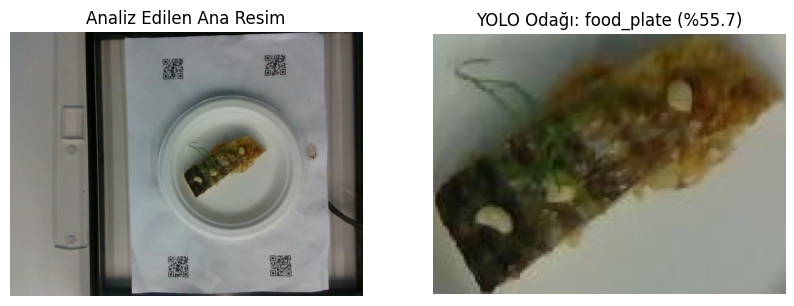


🔬 Qwen2-VL Besin Değerlerini Çıkarıyor...
📊 Analiz Sonucu: Yemek: salmon. Enerji: 29.0 kcal, Protein: 3.1g, Yag: 0.5g, Karbonhidrat: 2.6g.

👩‍⚕️ Diyetisyen Tavsiyesi Hazırlanıyor...

📋 DİYETİSYEN RAPORU
--------------------------------------------------
Kullanıcı: Diyetteyken denge sağlamak zor. Bu yemek dengeyi bozar mı?


Analiz: Salmon hem omega-3 ağırlıklı olduğu için kan emilimini dengelemeye yardımcı olur. Yanında bol miktir salataan ve az miktar bulgur eklettiğin sürece denge sağlanabilir.


In [7]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import PeftModel
from unsloth import FastLanguageModel
from qwen_vl_utils import process_vision_info
import os

YOLO_MODEL_PATH = "/content/drive/MyDrive/derin/YOLO_Final/foodd_large_model/weights/best.pt"
VL_MODEL_PATH = "/content/drive/MyDrive/derin/Qwen_Food_Final_Model"
CHAT_MODEL_PATH = "/content/drive/MyDrive/derin/Diyetisyen_Chatbot_Brain"

print("🚀 Modeller A100 üzerine yükleniyor...")

yolo_model = YOLO(YOLO_MODEL_PATH)

base_vl_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
vl_model = PeftModel.from_pretrained(base_vl_model, VL_MODEL_PATH)
vl_model = vl_model.merge_and_unload()
vl_model.eval()
vl_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

chat_model, chat_tokenizer = FastLanguageModel.from_pretrained(
    model_name = CHAT_MODEL_PATH,
    max_seq_length = 2048,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(chat_model)

print("✅ Tüm sistemler birleştirildi!")

def diyetisyen_analiz_zinciri(image_path):
    print(f"\n{'='*20} ANALİZ SÜRECİ {'='*20}")

    img = Image.open(image_path).convert("RGB")
    results = yolo_model(image_path)

    found_items = []
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        label = yolo_model.names[cls_id]
        conf = float(box.conf[0])
        found_items.append(f"{label} (%{conf*100:.1f})")

    print(f"📍 YOLO'nun buldukları: {', '.join(found_items) if found_items else 'Hiçbir şey bulunamadı'}")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Analiz Edilen Ana Resim")
    plt.axis('off')

    if len(results[0].boxes) > 0:
        box = results[0].boxes[0].xyxy[0].cpu().numpy()
        crop_img = img.crop((box[0], box[1], box[2], box[3]))
        plt.subplot(1, 2, 2)
        plt.imshow(crop_img)
        plt.title(f"YOLO Odağı: {found_items[0]}")
    plt.axis('off')
    plt.show()

    print("\n🔬 Qwen2-VL Besin Değerlerini Çıkarıyor...")
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": "Bu yemegi analiz ederek besin degerlerini belirtiniz."}
            ],
        }
    ]
    text = vl_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = vl_processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_ids = vl_model.generate(**inputs, max_new_tokens=128)
        generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, output_ids)]
        analysis_result = vl_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print(f"📊 Analiz Sonucu: {analysis_result}")

    print("\n👩‍⚕️ Diyetisyen Tavsiyesi Hazırlanıyor...")
    alpaca_prompt = "### Talimat:\nSen profesyonel bir diyetisyensin. Aşağıdaki besin analizini değerlendir ve adım adım düşünerek hastana önerilerde bulun.\n\n### Girdi:\n{}\n\n### Yanıt:\n<thought>\n"
    formatted_prompt = alpaca_prompt.format(analysis_result)
    inputs = chat_tokenizer([formatted_prompt], return_tensors = "pt").to("cuda")

    with torch.no_grad():
        outputs = chat_model.generate(**inputs, max_new_tokens=512)
        final_text = chat_tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    if "</thought>" in final_text:
        response = final_text.split("</thought>")[-1].strip()
    else:
        response = final_text.split("### Yanıt:")[-1].replace("<thought>", "").strip()

    print("\n" + "="*50)
    print("📋 DİYETİSYEN RAPORU")
    print("-" * 50)
    print(response.replace("<|im_end|>", "").strip())
    print("="*50)

test_gorseli = "/content/drive/MyDrive/derin/dataset_images/food_nutrients/food_15.jpg"
diyetisyen_analiz_zinciri(test_gorseli)

### TEST 2


==================== ANALİZ SÜRECİ ====================

image 1/1 /content/indir.png: 480x640 3 food_plates, 12.2ms
Speed: 2.4ms preprocess, 12.2ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
📍 YOLO'nun buldukları: food_plate (%40.0), food_plate (%37.6), food_plate (%29.1)


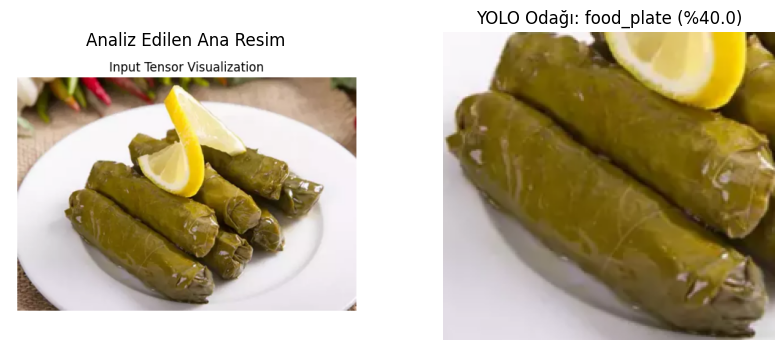


🔬 Qwen2-VL Besin Değerlerini Çıkarıyor...
📊 Analiz Sonucu: Yemek: dolmas. Enerji: 117.2 kcal, Protein: 3.9g, Yag: 4.0g, Karbonhidrat: 16.5g.

👩‍⚕️ Diyetisyen Tavsiyesi Hazırlanıyor...

📋 DİYETİSYEN RAPORU
--------------------------------------------------
### Yanıt Girişi:
Analiz: 1-22 dolma ve 1-2 baklava (ayranla tüketildiğinde).


In [8]:
test_gorseli = "/content/indir.png"
diyetisyen_analiz_zinciri(test_gorseli)

### TEST 3


==================== ANALİZ SÜRECİ ====================

image 1/1 /content/images.webp: 640x576 3 food_plates, 86.1ms
Speed: 3.2ms preprocess, 86.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 576)
📍 YOLO'nun buldukları: food_plate (%65.0), food_plate (%64.0), food_plate (%58.8)


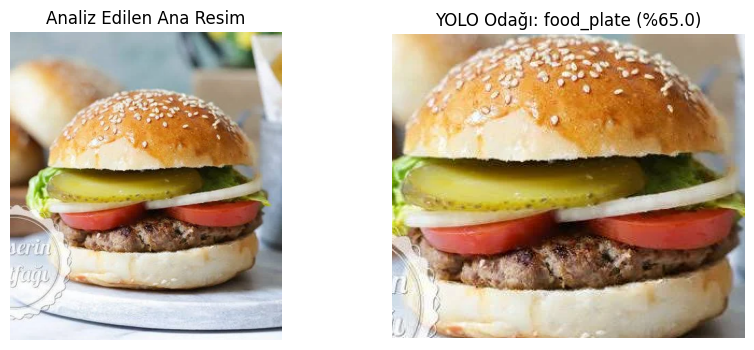


🔬 Qwen2-VL Besin Değerlerini Çıkarıyor...
📊 Analiz Sonucu: Yemek: onions, cheese, lettuce. Enerji: 550.9 kcal, Protein: 39.9g, Yag: 36.2g, Karbonhidrat: 17.0g.

👩‍⚕️ Diyetisyen Tavsiyesi Hazırlanıyor...

📋 DİYETİSYEN RAPORU
--------------------------------------------------
### Yanıt:
Onsürlü ve yağlı bir soslu burger. Mideyi çok hızlı doldurup ve kan şekerini hızlı yükseltebilir. Yanına bir kase yoğurt veya salataan ekleme. Bu şekilde denene dayanabilir.


In [9]:
test_gorseli = "/content/images.webp"
diyetisyen_analiz_zinciri(test_gorseli)

### TEST 4

🚀 Modeller yükleniyor, lütfen bekleyin...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.1.2: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Sistem hazır! (Çıkmak için 'çıkış' yazabilirsin)

--- Yapay Zeka Diyetisyen Sohbeti ---

Siz (Resim yolu veya Soru): Akşam meyve yesem olur mu?
👨‍⚕️ Diyetisyen yanıtlıyor...

Yanıt: Kesinlikle olur. Özellikle sebzeli meyveler (çilek, ayran, elma) porsiyon kontrolüyle tüketildiğinde hemmetme ve tokluk için çok iyi bir tercihtir.

Siz (Resim yolu veya Soru): /content/indir.png
🔍 Görsel inceleniyor...


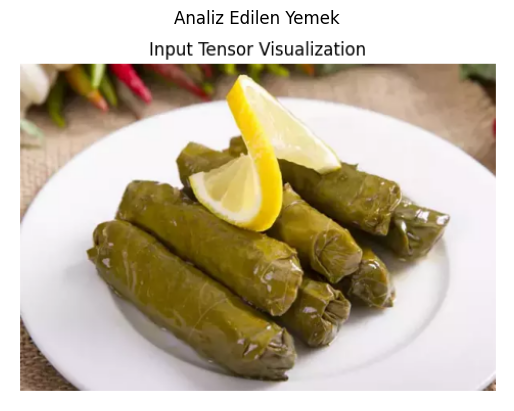


image 1/1 /content/indir.png: 480x640 3 food_plates, 13.2ms
Speed: 2.6ms preprocess, 13.2ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

🍎 Analiz Sonucu: Yemek: dolmas. Enerji: 117.2 kcal, Protein: 3.9g, Yag: 4.0g, Karbonhidrat: 16.5g.

💡 Bu yemek hakkında veya genel bir soru sorabilirsiniz.

Siz (Resim yolu veya Soru): çıkış
Hoşça kal!


In [17]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import PeftModel
from unsloth import FastLanguageModel
from qwen_vl_utils import process_vision_info
import os

YOLO_MODEL_PATH = "/content/drive/MyDrive/derin/YOLO_Final/foodd_large_model/weights/best.pt"
VL_MODEL_PATH = "/content/drive/MyDrive/derin/Qwen_Food_Final_Model"
CHAT_MODEL_PATH = "/content/drive/MyDrive/derin/Diyetisyen_Chatbot_Brain"

print("🚀 Modeller yükleniyor, lütfen bekleyin...")
yolo_model = YOLO(YOLO_MODEL_PATH)

base_vl_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto"
)
vl_model = PeftModel.from_pretrained(base_vl_model, VL_MODEL_PATH)
vl_model = vl_model.merge_and_unload()
vl_model.eval()
vl_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

chat_model, chat_tokenizer = FastLanguageModel.from_pretrained(
    model_name = CHAT_MODEL_PATH, max_seq_length = 2048, load_in_4bit = True
)
FastLanguageModel.for_inference(chat_model)
print("✅ Sistem hazır! (Çıkmak için 'çıkış' yazabilirsin)")


def resim_analiz_et(image_path):
    """Görseli analiz eder, ekranda gösterir ve metin sonucunu döner."""
    img = Image.open(image_path).convert("RGB")
    plt.imshow(img)
    plt.axis('off')
    plt.title("Analiz Edilen Yemek")
    plt.show()

    results = yolo_model(image_path)

    messages = [{"role": "user", "content": [{"type": "image", "image": image_path},
                {"type": "text", "text": "Bu yemegi analiz ederek besin degerlerini belirtiniz."}]}]

    text = vl_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = vl_processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_ids = vl_model.generate(**inputs, max_new_tokens=128)
        generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, output_ids)]
        return vl_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

def diyete_sor(soru, analiz_notu=None):
    """Chatbot'a soru sorar. Analiz varsa bağlam olarak kullanır."""
    baglam = f"Yemek Analizi: {analiz_notu}" if analiz_notu else "Şu an analiz edilen bir yemek yok. Genel soruları yanıtla."

    alpaca_prompt = f"""### Talimat:
Sen profesyonel bir diyetisyensin. Aşağıdaki bağlamı kullanarak kullanıcının sorusuna cevap ver.

### Bağlam:
{baglam}

### Soru:
{soru}

### Yanıt:
"""
    inputs = chat_tokenizer([alpaca_prompt], return_tensors="pt").to("cuda")
    outputs = chat_model.generate(**inputs, max_new_tokens=512)
    response = chat_tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    if "### Yanıt:" in response:
        return response.split("### Yanıt:")[-1].strip()
    return response


if __name__ == "__main__":
    son_analiz = None
    print("\n--- Yapay Zeka Diyetisyen Sohbeti ---")

    while True:
        girdi = input("\nSiz (Resim yolu veya Soru): ")

        if girdi.lower() == 'çıkış':
            print("Hoşça kal!")
            break

        if os.path.exists(girdi) and girdi.lower().endswith(('.png', '.jpg', '.jpeg')):
            print("🔍 Görsel inceleniyor...")
            son_analiz = resim_analiz_et(girdi)
            print(f"\n🍎 Analiz Sonucu: {son_analiz}")
            print("\n💡 Bu yemek hakkında veya genel bir soru sorabilirsiniz.")

        else:
            if not girdi.strip(): continue
            print("👨‍⚕️ Diyetisyen yanıtlıyor...")
            cevap = diyete_sor(girdi, son_analiz)
            print(f"\nYanıt: {cevap}")